# MVP — Pipeline de dados em nuvem: atrasos de entrega no e-commerce brasileiro

**Universidade de Brasília — Departamento de Engenharia de Produção**
Disciplina: Sistemas de Suporte à Decisão · Prof. André Luiz Marques Serrano
Aluno: **João Pedro Lima de Carvalho** · Matrícula 231013402 · Trabalho individual

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jplc08/mvp-pipeline-entregas-olist/blob/main/notebooks/mvp_pipeline_entregas_olist.ipynb)

> **Pipeline:** Kaggle (dados públicos da Olist) → **Google Drive** como Data Lake (camadas *bronze*, *silver* e *gold*) → **Google BigQuery** como Data Warehouse (esquema estrela) → análise com SQL + Python no **Google Colab**.

**Roteiro do notebook**

1. Objetivo — problema, perguntas de negócio e hipóteses
2. Arquitetura e plataforma
3. Configuração do ambiente
4. Busca e coleta dos dados (camada *bronze*)
5. Análise — parte (a): qualidade dos dados brutos
6. Transformação (camada *silver*) e regras de negócio
7. Modelagem (camada *gold*) — esquema estrela e Catálogo de Dados
8. Carga no Data Warehouse (BigQuery) e verificação da persistência
9. Análise — parte (b): solução do problema (P1 a P5)
10. Discussão geral e avaliação das hipóteses
11. Viabilidade financeira — custo de operação
12. Autoavaliação
13. Exportação das evidências e referências

## 1. Objetivo

### 1.1 Contexto

O e-commerce brasileiro opera sobre uma malha logística desigual: um mesmo marketplace despacha pedidos de vendedores concentrados no Sudeste para clientes espalhados por todo o território nacional. No momento da compra, a plataforma **promete uma data de entrega**. Quando essa promessa é quebrada, o custo aparece em avaliações negativas, contatos com o atendimento e perda de recompra.

### 1.2 Problema

A Olist é um marketplace que conecta pequenos vendedores a grandes canais de venda. Ela precisa decidir **onde agir para reduzir as entregas atrasadas**: recalibrar o prazo prometido por região, cobrar o prazo de postagem dos vendedores ou atacar as rotas longas. Hoje não se sabe **quanto cada fator explica o atraso**, nem **quanto o atraso custa em satisfação do cliente**.

Este MVP constrói um pipeline de dados em nuvem que organiza o histórico de pedidos em um Data Warehouse dimensional e responde, com evidência, às perguntas que sustentam essa decisão.

### 1.3 Perguntas de negócio

| # | Pergunta | Decisão que a resposta apoia |
|---|---|---|
| **P1** | Qual é a taxa de entregas atrasadas (entrega depois da data prometida) e como ela evoluiu mês a mês entre jan/2017 e ago/2018? | Dimensionar o problema e identificar picos que pedem reforço de capacidade. |
| **P2** | Quais estados de destino concentram os maiores atrasos, e o prazo prometido está calibrado para a realidade de cada estado? | Recalibrar o prazo prometido por UF. |
| **P3** | Qual é a relação entre a distância vendedor → cliente e a probabilidade de atraso, e esse efeito se mantém quando se controlam região de destino, peso e mês da compra? | Priorizar rotas e transportadoras de longa distância. |
| **P4** | Em que etapa o atraso nasce — na preparação pelo vendedor (postagem depois do prazo-limite) ou no transporte — e quão concentrados os atrasos estão em poucos vendedores? | Criar um SLA de postagem e um programa de acompanhamento de vendedores. |
| **P5** | Quanto o atraso reduz a nota de avaliação do cliente e a proporção de avaliações negativas (1 ou 2 estrelas)? | Quantificar o custo do atraso em satisfação e justificar o investimento. |

### 1.4 Hipóteses do MVP e critérios de confirmação

Um MVP precisa de uma hipótese explícita e de uma métrica que a confirme ou refute. Os critérios abaixo foram **definidos antes da análise** e são avaliados automaticamente na Seção 10. As hipóteses são numeradas conforme a pergunta que as testa; P1 é descritiva e serve de linha de base.

| Hipótese | Enunciado | Critério de confirmação |
|---|---|---|
| **H2** | O prazo prometido não compensa as diferenças regionais. | Entre as UFs com pelo menos 300 entregas, a taxa de atraso da UF mais afetada é **≥ 3 vezes** a da menos afetada. |
| **H3** | A distância aumenta o risco de atraso, mesmo com controles. | Taxa de atraso na faixa **≥ 2.000 km** é **≥ 1,5 vez** a da faixa **até 100 km** **e** a razão de chances ajustada por +500 km é **> 1**, com IC 95% inteiramente acima de 1. |
| **H4** | Parte relevante do atraso nasce no vendedor. | A taxa de atraso das remessas postadas **depois** do prazo-limite é **≥ 2 vezes** a das postadas no prazo (qui-quadrado, p < 0,05). |
| **H5** | O atraso derruba a satisfação do cliente. | Nota média dos pedidos entregues no prazo menos a nota média dos atrasados **≥ 1 ponto** (Mann-Whitney, p < 0,05). |

### 1.5 Escopo

* **Dentro do escopo:** pedidos com compra entre 01/01/2017 e 31/08/2018 (janela com volume representativo — ver Seção 5); métricas de entrega apenas para remessas efetivamente entregues.
* **Fora do escopo:** previsão de atraso com aprendizado de máquina, meios de pagamento, desempenho por categoria de produto e custo das transportadoras (não disponível na base).

### 1.6 As três dimensões do MVP

| Dimensão | Pergunta central | Evidência neste trabalho |
|---|---|---|
| Viabilidade técnica | A solução pode ser construída com a tecnologia disponível? | Pipeline ponta a ponta executado no Colab, com dados persistidos no Drive e no BigQuery (Seções 4 a 8). |
| Viabilidade financeira | A solução é economicamente sustentável? | Custo de armazenamento e de consulta medido e estimado (Seção 11). |
| Desejabilidade | A solução é o que os usuários querem? | P1 a P5 respondidas com dados e discutidas criticamente (Seções 9 e 10). |

## 2. Arquitetura e plataforma

```
 FONTE                      DATA LAKE (Google Drive)                          DATA WAREHOUSE (BigQuery)
 ───────────────────        ───────────────────────────────────────           ─────────────────────────────────
 Kaggle                     bronze/  CSVs originais + metadados da coleta
 olistbr/brazilian-  ─────▶ silver/  Parquet limpo, tipado e padronizado
 ecommerce (9 CSVs) coleta  gold/    Parquet do modelo estrela  ────────────▶ dataset olist_dw
                                                                   carga      fato_entrega + 3 dimensões
                                                                              meta_* (catálogo, linhagem,
                                                                                      qualidade, coleta)
                                         Google Colab (Python + pandas)  ◀────  consultas SQL → gráficos
```

| Camada | Onde fica | Formato | Conteúdo | Por quê |
|---|---|---|---|---|
| Bronze | Drive · `mvp_olist/bronze/olist/data_coleta=AAAA-MM-DD/` | CSV original | Os 9 arquivos exatamente como baixados, com hash SHA-256 e metadados | Reprodutibilidade e auditoria: é sempre possível reprocessar a partir do dado bruto. |
| Silver | Drive · `mvp_olist/silver/` | Parquet | Tabelas limpas, tipadas, deduplicadas e padronizadas | Base confiável e reutilizável, independente das perguntas. |
| Gold | Drive · `mvp_olist/gold/` **e** BigQuery · `olist_dw` | Parquet + tabelas BigQuery | Esquema estrela (`fato_entrega`, `dim_tempo`, `dim_localidade`, `dim_vendedor`) e tabelas `meta_*` | Modelo analítico consultável por SQL, com descrições do catálogo gravadas nas colunas. |

**Decisões de plataforma**

* **Google Colab** executa todo o pipeline em Python, sem instalação local, e se integra nativamente ao Drive e ao BigQuery.
* **Google Drive** faz o papel de *Data Lake*: armazenamento em nuvem, persistente e organizado em camadas (arquitetura *medallion*).
* **BigQuery Sandbox** faz o papel de *Data Warehouse*: é gratuito e não exige cartão de crédito. Tem duas limitações relevantes: **não aceita DML** (INSERT/UPDATE/DELETE) e **as tabelas expiram após 60 dias**. O pipeline foi desenhado para isso. A carga usa *load jobs* com `WRITE_TRUNCATE` (idempotente: reexecutar substitui as tabelas, sem duplicar). A camada *gold* também fica gravada em Parquet no Drive, de onde pode ser recarregada no BigQuery a qualquer momento.

**Como reproduzir**

1. Crie (ou use) um projeto no Google Cloud em <https://console.cloud.google.com/projectcreate> e abra o console do BigQuery uma vez para ativar o *sandbox*. Anote o **ID do projeto**.
2. Abra este notebook no Colab (botão no topo), preencha `PROJECT_ID` na célula de parâmetros e execute **Ambiente de execução → Executar tudo**.
3. Autorize o acesso ao Google Drive e à conta Google quando solicitado. O download do Kaggle não exige login (o conjunto é público).

## 3. Configuração do ambiente

Parâmetros do pipeline. Só `PROJECT_ID` precisa ser alterado; os demais têm valores padrão.

In [26]:
#@title Parâmetros do pipeline
PROJECT_ID = "mvp-olist-entregas"  #@param {type:"string"}
DATASET_BQ = "olist_dw"  #@param {type:"string"}
LOCAL_BQ = "US"  #@param ["US", "southamerica-east1"]
PASTA_DRIVE = "/content/drive/MyDrive/mvp_olist"  #@param {type:"string"}

# Fonte dos dados
KAGGLE_DATASET = "olistbr/brazilian-ecommerce"
URL_FONTE = "https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce"
LICENCA_DADOS = "CC BY-NC-SA 4.0 (Creative Commons Atribuição-NãoComercial-CompartilhaIgual 4.0)"

# Plano B: se o download automático falhar, baixe o ZIP em URL_FONTE, descompacte
# e envie os 9 CSVs para esta pasta do Drive.
PASTA_MANUAL = PASTA_DRIVE + "/upload_manual"

# Janela de análise (justificada na Seção 5, dimensão "atualidade")
INICIO_JANELA = "2017-01-01"
FIM_JANELA = "2018-08-31"

# Preço de referência do BigQuery sob demanda (consultas), usado na Seção 11
PRECO_USD_POR_TIB = 6.25

In [11]:
%pip install -q kagglehub

import os, re, json, glob, time, shutil, hashlib, zipfile, unicodedata, warnings
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import FancyBboxPatch
from scipy import stats
import statsmodels.formula.api as smf
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.3 | numpy 2.1.3


In [12]:
# Autenticação: Google Drive (Data Lake) e Google Cloud (BigQuery)
from google.colab import drive, auth
drive.mount("/content/drive")
auth.authenticate_user()

DIR = {nome: os.path.join(PASTA_DRIVE, sub) for nome, sub in {
    "bronze": "bronze/olist",
    "silver": "silver",
    "gold": "gold",
    "metadados": "metadados",
    "catalogo": "catalogo",
    "graficos": "evidencias/graficos",
    "tabelas": "evidencias/tabelas",
}.items()}
for caminho in DIR.values():
    os.makedirs(caminho, exist_ok=True)

AGORA = dt.datetime.now(dt.timezone(dt.timedelta(hours=-3)))  # horário de Brasília
DATA_COLETA = AGORA.strftime("%Y-%m-%d")
print("Execução em", AGORA.strftime("%d/%m/%Y %H:%M"), "(UTC-3)")
for nome, caminho in DIR.items():
    print(f"  {nome:<10} {caminho}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Execução em 28/09/2026 18:15 (UTC-3)
  bronze     /content/drive/MyDrive/mvp_olist/bronze/olist
  silver     /content/drive/MyDrive/mvp_olist/silver
  gold       /content/drive/MyDrive/mvp_olist/gold
  metadados  /content/drive/MyDrive/mvp_olist/metadados
  catalogo   /content/drive/MyDrive/mvp_olist/catalogo
  graficos   /content/drive/MyDrive/mvp_olist/evidencias/graficos
  tabelas    /content/drive/MyDrive/mvp_olist/evidencias/tabelas


In [13]:
#@title Funções auxiliares (estilo dos gráficos, formatação e intervalos de confiança)
# Paleta categórica validada para daltonismo (slots 1 a 3) + tons neutros.
AZUL, LARANJA, VERDE_AGUA = "#2a78d6", "#eb6834", "#1baf7a"
CINZA, CINZA_CLARO, GRADE = "#898781", "#c3c2b7", "#e1e0d9"
TINTA, TINTA_2 = "#0b0b0b", "#52514e"
AZUIS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # rampa ordinal (claro → escuro)
DIVERGENTE = ["#184f95", "#2a78d6", "#86b6ef", "#a3a29c", "#f1a3a2", "#e34948", "#a32d2c"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": CINZA_CLARO, "axes.linewidth": 0.8,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRADE, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "font.size": 10.5, "legend.frameon": False,
})

def salvar_figura(fig, nome):
    caminho = os.path.join(DIR["graficos"], f"{nome}.png")
    fig.savefig(caminho, bbox_inches="tight", facecolor="white")
    print("Figura salva em", caminho)

def salvar_tabela(df, nome):
    df.to_csv(os.path.join(DIR["tabelas"], f"{nome}.csv"), index=False)

def num(x, casas=0):
    """Formata número no padrão brasileiro (1.234,5)."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "—"
    return f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

def pct(x, casas=1):
    return num(x, casas) + "%"

def fp(p):
    """Formata p-valor: 'p < 0,001' ou 'p = 0,034'."""
    return "p < 0,001" if p < 0.001 else f"p = {num(p, 3)}"

def wilson(k, n, z=1.96):
    """Intervalo de confiança de Wilson (95%) para uma proporção, em %."""
    k, n = np.asarray(k, dtype=float), np.asarray(n, dtype=float)
    p = np.where(n > 0, k / np.maximum(n, 1), np.nan)
    den = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / den
    meia = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return 100 * (centro - meia), 100 * (centro + meia)

def mostrar(texto):
    display(Markdown(texto))

def tabela_markdown(df):
    """Converte um DataFrame em tabela Markdown (para os arquivos de documentação)."""
    celula = lambda v: str(v).replace("|", "\\|").replace("\n", " ")
    linhas = ["| " + " | ".join(map(celula, df.columns)) + " |", "|" + "|".join(["---"] * df.shape[1]) + "|"]
    linhas += ["| " + " | ".join(map(celula, r)) + " |" for r in df.itertuples(index=False)]
    return "\n".join(linhas)

RESUMO = {}   # textos gerados automaticamente a partir dos resultados (exportados na Seção 13)
print("Funções auxiliares carregadas.")

Funções auxiliares carregadas.


## 4. Busca e coleta dos dados (camada *bronze*)

### 4.1 Escolha da base

A base foi escolhida **depois** de definido o problema, a partir dos atributos que as perguntas exigem:

| Necessidade das perguntas | Atributo na base da Olist |
|---|---|
| Data prometida × data real de entrega (P1, P2, P5) | `order_estimated_delivery_date`, `order_delivered_customer_date` |
| Etapas do processo logístico (P4) | `order_approved_at`, `order_delivered_carrier_date`, `shipping_limit_date` |
| Origem e destino geográficos (P2, P3) | CEP-prefixo do vendedor e do cliente + tabela de geolocalização |
| Satisfação do cliente (P5) | `review_score` |
| Controles (peso, frete, vendedor) | `product_weight_g`, `freight_value`, `seller_id` |

**Fonte:** *Brazilian E-Commerce Public Dataset by Olist* — Kaggle (<https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce>). São cerca de 100 mil pedidos reais feitos entre 2016 e 2018 em vários marketplaces brasileiros, distribuídos em 9 arquivos CSV relacionais.

### 4.2 Licença, ética e proteção de dados

* **Licença:** CC BY-NC-SA 4.0. Ela permite uso e redistribuição **com atribuição** à Olist, **sem fins comerciais** e com **compartilhamento pela mesma licença**. Este trabalho é acadêmico e não comercial. Mesmo assim, **os dados brutos não são versionados no GitHub**: o repositório publica o script de coleta, e cada execução baixa os dados da fonte oficial.
* **Dados pessoais (LGPD — Lei nº 13.709/2018):** a Olist já publica a base anonimizada. Não há nomes, e-mails, documentos nem endereços completos; os identificadores são *hashes*, e as referências a empresas nos comentários foram substituídas por nomes fictícios. Como camada extra de proteção, este pipeline aplica **minimização de dados** (regra R14): o identificador único do cliente e o texto livre das avaliações não entram nas camadas *silver* e *gold*, porque não são necessários às perguntas e o texto livre pode conter dados pessoais digitados pelo cliente.
* **Coleta:** o download usa a API pública do Kaggle (`kagglehub`), dentro dos termos de uso da plataforma. Não há *web scraping*.

### 4.3 Coleta e persistência na camada *bronze*

A célula abaixo baixa os 9 arquivos, copia-os **sem alteração** para a pasta `bronze/olist/data_coleta=AAAA-MM-DD/` no Google Drive e registra os metadados de reprodutibilidade: data da coleta, versão do conjunto, volume, número de linhas e hash SHA-256 de cada arquivo.

In [14]:
import kagglehub

ARQUIVOS = {
    "olist_orders_dataset.csv": "pedidos",
    "olist_order_items_dataset.csv": "itens",
    "olist_customers_dataset.csv": "clientes",
    "olist_sellers_dataset.csv": "vendedores",
    "olist_products_dataset.csv": "produtos",
    "olist_order_reviews_dataset.csv": "avaliacoes",
    "olist_order_payments_dataset.csv": "pagamentos",
    "olist_geolocation_dataset.csv": "geolocalizacao",
    "product_category_name_translation.csv": "categorias",
}

inicio = time.time()
try:
    origem = kagglehub.dataset_download(KAGGLE_DATASET)
    metodo = "kagglehub.dataset_download — API pública do Kaggle, sem autenticação"
except Exception as erro:
    print("Download automático falhou:", erro)
    print("Usando o plano B: arquivos enviados manualmente para", PASTA_MANUAL)
    origem, metodo = PASTA_MANUAL, "upload manual para o Google Drive (plano B)"

faltando = [a for a in ARQUIVOS if not os.path.exists(os.path.join(origem, a))]
assert not faltando, f"Arquivos ausentes em {origem}: {faltando}"
achado = re.search(r"versions/(\d+)", origem)
VERSAO_DATASET = achado.group(1) if achado else "não identificada"

PASTA_BRONZE = os.path.join(DIR["bronze"], f"data_coleta={DATA_COLETA}")
os.makedirs(PASTA_BRONZE, exist_ok=True)

def sha256(caminho):
    h = hashlib.sha256()
    with open(caminho, "rb") as f:
        for bloco in iter(lambda: f.read(1 << 20), b""):
            h.update(bloco)
    return h.hexdigest()

for arquivo in ARQUIVOS:
    shutil.copy2(os.path.join(origem, arquivo), os.path.join(PASTA_BRONZE, arquivo))

# Leitura da bronze A PARTIR DO DRIVE, tudo como texto (fidelidade ao dado bruto)
bronze, registros = {}, []
for arquivo, nome in ARQUIVOS.items():
    caminho = os.path.join(PASTA_BRONZE, arquivo)
    bronze[nome] = pd.read_csv(caminho, dtype=str, encoding="utf-8-sig")
    registros.append({
        "tabela": nome, "arquivo": arquivo, "formato": "CSV (UTF-8, separador vírgula)",
        "linhas": len(bronze[nome]), "colunas": bronze[nome].shape[1],
        "tamanho_mb": round(os.path.getsize(caminho) / 2**20, 2), "sha256": sha256(caminho),
    })

meta_coleta = pd.DataFrame(registros)
metadados = {
    "fonte": URL_FONTE, "dataset_kaggle": KAGGLE_DATASET, "versao_dataset": VERSAO_DATASET,
    "licenca": LICENCA_DADOS, "metodo_coleta": metodo,
    "data_hora_coleta": AGORA.isoformat(timespec="seconds"), "pasta_bronze": PASTA_BRONZE,
    "volume_total_mb": round(meta_coleta["tamanho_mb"].sum(), 2),
    "linhas_total": int(meta_coleta["linhas"].sum()), "arquivos": registros,
}
for pasta in (PASTA_BRONZE, DIR["metadados"]):
    with open(os.path.join(pasta, "_metadados_coleta.json"), "w", encoding="utf-8") as f:
        json.dump(metadados, f, ensure_ascii=False, indent=2)

meta_coleta["data_coleta"] = DATA_COLETA
meta_coleta["versao_dataset"] = VERSAO_DATASET
meta_coleta["fonte"] = URL_FONTE

mostrar(f"""**Coleta concluída em {time.time() - inicio:.0f} s** — {metodo}.
Versão do conjunto: **{VERSAO_DATASET}** · Data da coleta: **{AGORA.strftime('%d/%m/%Y %H:%M')}** ·
Volume: **{num(metadados['volume_total_mb'], 1)} MB** em **{len(ARQUIVOS)} arquivos CSV** ·
**{num(metadados['linhas_total'])} linhas** no total · Persistido em `{PASTA_BRONZE}`""")
display(meta_coleta.drop(columns=["data_coleta", "versao_dataset", "fonte"])
        .assign(sha256=lambda d: d["sha256"].str[:16] + "…"))

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


**Coleta concluída em 33 s** — kagglehub.dataset_download — API pública do Kaggle, sem autenticação.
Versão do conjunto: **não identificada** · Data da coleta: **28/09/2026 18:15** ·
Volume: **120,3 MB** em **9 arquivos CSV** ·
**1.550.922 linhas** no total · Persistido em `/content/drive/MyDrive/mvp_olist/bronze/olist/data_coleta=2026-09-28`

,tabela,arquivo,formato,linhas,colunas,tamanho_mb,sha256
0,pedidos,olist_orders_dataset.csv,"CSV (UTF-8, separador vírgula)",99441,8,16.84,8df58ef3d2d7e994…
1,itens,olist_order_items_dataset.csv,"CSV (UTF-8, separador vírgula)",112650,7,14.72,0bc4d068c4fe38cb…
2,clientes,olist_customers_dataset.csv,"CSV (UTF-8, separador vírgula)",99441,5,8.62,983a422239e1712d…
3,vendedores,olist_sellers_dataset.csv,"CSV (UTF-8, separador vírgula)",3095,4,0.17,1f643d2b950373b8…
4,produtos,olist_products_dataset.csv,"CSV (UTF-8, separador vírgula)",32951,9,2.27,3e6569628a17fbc7…
5,avaliacoes,olist_order_reviews_dataset.csv,"CSV (UTF-8, separador vírgula)",99224,7,13.78,012b61c7593e34f5…
6,pagamentos,olist_order_payments_dataset.csv,"CSV (UTF-8, separador vírgula)",103886,5,5.51,4f713964f2815dbb…
7,geolocalizacao,olist_geolocation_dataset.csv,"CSV (UTF-8, separador vírgula)",1000163,5,58.44,b514f6fc991b9566…
8,categorias,product_category_name_translation.csv,"CSV (UTF-8, separador vírgula)",71,2,0.00,a81f0d1f27b27e72…


> **Evidência:** a pasta `bronze/olist/data_coleta=…` no Google Drive contém os 9 CSVs e o arquivo `_metadados_coleta.json` (captura `evidencias/01_drive_bronze.png` no repositório).

## 5. Análise — parte (a): qualidade dos dados brutos

A análise de qualidade foi feita **antes** da transformação, porque é ela que define as regras de tratamento da Seção 6. Ela tem três partes:

1. **Perfil por atributo:** todos os 52 atributos dos 9 arquivos, com tipo esperado, nulos, valores distintos, conformidade ao tipo, mínimo/máximo e valores mais frequentes.
2. **Verificações por dimensão de qualidade:** completude, unicidade, consistência, conformidade, acurácia e integridade referencial, cada uma com o tratamento adotado.
3. **Atualidade:** volume mensal e pedidos em aberto, que definem a janela de análise.

Depois da carga, a Seção 8 repete verificações no Data Warehouse (unicidade da chave, integridade referencial e aderência aos domínios do Catálogo de Dados).

In [15]:
# Esquema esperado de cada atributo da origem (base para tipagem e conformidade)
ESQUEMA_ORIGEM = {
    "pedidos": {"order_id": "id", "customer_id": "id", "order_status": "categoria",
                "order_purchase_timestamp": "timestamp", "order_approved_at": "timestamp",
                "order_delivered_carrier_date": "timestamp", "order_delivered_customer_date": "timestamp",
                "order_estimated_delivery_date": "timestamp"},
    "itens": {"order_id": "id", "order_item_id": "inteiro", "product_id": "id", "seller_id": "id",
              "shipping_limit_date": "timestamp", "price": "decimal", "freight_value": "decimal"},
    "clientes": {"customer_id": "id", "customer_unique_id": "id", "customer_zip_code_prefix": "cep",
                 "customer_city": "texto", "customer_state": "uf"},
    "vendedores": {"seller_id": "id", "seller_zip_code_prefix": "cep", "seller_city": "texto", "seller_state": "uf"},
    "produtos": {"product_id": "id", "product_category_name": "categoria", "product_name_lenght": "inteiro",
                 "product_description_lenght": "inteiro", "product_photos_qty": "inteiro",
                 "product_weight_g": "decimal", "product_length_cm": "decimal",
                 "product_height_cm": "decimal", "product_width_cm": "decimal"},
    "avaliacoes": {"review_id": "id", "order_id": "id", "review_score": "inteiro",
                   "review_comment_title": "texto", "review_comment_message": "texto",
                   "review_creation_date": "timestamp", "review_answer_timestamp": "timestamp"},
    "pagamentos": {"order_id": "id", "payment_sequential": "inteiro", "payment_type": "categoria",
                   "payment_installments": "inteiro", "payment_value": "decimal"},
    "geolocalizacao": {"geolocation_zip_code_prefix": "cep", "geolocation_lat": "decimal",
                       "geolocation_lng": "decimal", "geolocation_city": "texto", "geolocation_state": "uf"},
    "categorias": {"product_category_name": "categoria", "product_category_name_english": "categoria"},
}
UFS = ["AC", "AL", "AM", "AP", "BA", "CE", "DF", "ES", "GO", "MA", "MG", "MS", "MT", "PA",
       "PB", "PE", "PI", "PR", "RJ", "RN", "RO", "RR", "RS", "SC", "SE", "SP", "TO"]
LAT_BR, LON_BR = (-33.75, 5.30), (-73.99, -34.79)   # retângulo envolvente do território brasileiro

def tipar_coluna(s, tipo):
    if tipo == "timestamp":
        return pd.to_datetime(s, errors="coerce", format="ISO8601")
    if tipo == "decimal":
        return pd.to_numeric(s, errors="coerce").astype("float64")
    if tipo == "inteiro":
        x = pd.to_numeric(s, errors="coerce")
        return x.where(x % 1 == 0).astype("Int64")
    return s.astype("string").str.strip()

def tipar(nome, df):
    return pd.DataFrame({c: tipar_coluna(df[c], ESQUEMA_ORIGEM[nome][c]) for c in df.columns})

def mascara_conforme(tipado, tipo):
    if tipo in ("timestamp", "decimal", "inteiro"):
        return tipado.notna()
    if tipo == "id":
        return tipado.str.fullmatch(r"[0-9a-f]{32}").fillna(False).astype(bool)
    if tipo == "cep":
        return tipado.str.fullmatch(r"\d{5}").fillna(False).astype(bool)
    if tipo == "uf":
        return tipado.isin(UFS).fillna(False).astype(bool)
    return tipado.notna()

bt = {nome: tipar(nome, df) for nome, df in bronze.items()}   # "bronze tipada": mesmos dados, tipos explícitos

linhas = []
for nome, df in bronze.items():
    for col in df.columns:
        tipo = ESQUEMA_ORIGEM[nome][col]
        bruto, x = df[col], bt[nome][col]
        presentes = int(bruto.notna().sum())
        conformes = int((mascara_conforme(x, tipo) & bruto.notna()).sum())
        linha = {"tabela": nome, "atributo": col, "tipo_esperado": tipo, "linhas": len(bruto),
                 "nulos": int(bruto.isna().sum()), "pct_nulos": round(100 * bruto.isna().mean(), 2),
                 "distintos": int(bruto.nunique()),
                 "pct_conformes": round(100 * conformes / presentes, 2) if presentes else np.nan,
                 "minimo": "", "maximo": "", "valores_mais_frequentes": ""}
        if tipo in ("timestamp", "decimal", "inteiro") and x.notna().any():
            fmt = (lambda v: str(v)) if tipo == "timestamp" else (lambda v: num(float(v), 2 if tipo == "decimal" else 0))
            linha["minimo"], linha["maximo"] = fmt(x.min()), fmt(x.max())
        elif tipo in ("texto", "id", "cep", "categoria") and presentes:
            comp = bruto.dropna().str.len()
            linha["minimo"], linha["maximo"] = f"{comp.min()} caract.", f"{comp.max()} caract."
        if tipo in ("categoria", "uf") or (tipo == "inteiro" and bruto.nunique() <= 30):
            top = bruto.value_counts().head(4)
            linha["valores_mais_frequentes"] = "; ".join(f"{k} ({num(v)})" for k, v in top.items())
        linhas.append(linha)

perfil = pd.DataFrame(linhas)
perfil.to_csv(os.path.join(DIR["metadados"], "perfil_qualidade_bronze.csv"), index=False)
salvar_tabela(perfil, "q1_perfil_por_atributo")
pd.set_option("display.max_rows", 120)
mostrar(f"**Perfil de {len(perfil)} atributos em {perfil['tabela'].nunique()} tabelas.** "
        f"Atributos com nulos: {int((perfil['nulos'] > 0).sum())} · "
        f"atributos com conformidade abaixo de 100%: {int((perfil['pct_conformes'] < 100).sum())}.")
display(perfil)

**Perfil de 52 atributos em 9 tabelas.** Atributos com nulos: 13 · atributos com conformidade abaixo de 100%: 0.

,tabela,atributo,tipo_esperado,linhas,nulos,pct_nulos,distintos,pct_conformes,minimo,maximo,valores_mais_frequentes
0,pedidos,order_id,id,99441,0,0.00,99441,100.0,32 caract.,32 caract.,
1,pedidos,customer_id,id,99441,0,0.00,99441,100.0,32 caract.,32 caract.,
2,pedidos,order_status,categoria,99441,0,0.00,8,100.0,7 caract.,11 caract.,delivered (96.478); shipped (1.107); canceled (625); unavailable (609)
3,pedidos,order_purchase_timestamp,timestamp,99441,0,0.00,98875,100.0,2016-09-04 21:15:19,2018-10-17 17:30:18,
4,pedidos,order_approved_at,timestamp,99441,160,0.16,90733,100.0,2016-09-15 12:16:38,2018-09-03 17:40:06,
5,pedidos,order_delivered_carrier_date,timestamp,99441,1783,1.79,81018,100.0,2016-10-08 10:34:01,2018-09-11 19:48:28,
6,pedidos,order_delivered_customer_date,timestamp,99441,2965,2.98,95664,100.0,2016-10-11 13:46:32,2018-10-17 13:22:46,
7,pedidos,order_estimated_delivery_date,timestamp,99441,0,0.00,459,100.0,2016-09-30 00:00:00,2018-11-12 00:00:00,
8,itens,order_id,id,112650,0,0.00,98666,100.0,32 caract.,32 caract.,
9,itens,order_item_id,inteiro,112650,0,0.00,21,100.0,1,21,1 (98.666); 2 (9.803); 3 (2.287); 4 (965)


In [36]:
# Verificações específicas por dimensão de qualidade
P, I, C, V = bt["pedidos"], bt["itens"], bt["clientes"], bt["vendedores"]
PR, A, G, T = bt["produtos"], bt["avaliacoes"], bt["geolocalizacao"], bt["categorias"]
checagens = []

def verificar(dimensao, verificacao, tabela, ocorrencias, base, tratamento):
    ocorrencias, base = int(ocorrencias), int(base)
    checagens.append({"dimensao": dimensao, "verificacao": verificacao, "tabela": tabela,
                      "ocorrencias": ocorrencias, "base": base,
                      "pct": round(100 * ocorrencias / base, 3) if base else np.nan,
                      "tratamento": tratamento})

def normalizar_texto(s):
    s = s.astype("string").str.strip().str.lower()
    return s.str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("ascii").astype("string")

entregue = P["order_status"].eq("delivered")
cep_geo = set(G["geolocation_zip_code_prefix"].dropna().str.zfill(5))

# Unicidade
verificar("Unicidade", "order_id duplicado", "pedidos", P["order_id"].duplicated().sum(), len(P), "R07 — remover duplicatas")
verificar("Unicidade", "(order_id, order_item_id) duplicado", "itens", I.duplicated(["order_id", "order_item_id"]).sum(), len(I), "R07 — remover duplicatas")
verificar("Unicidade", "customer_id duplicado", "clientes", C["customer_id"].duplicated().sum(), len(C), "R07 — remover duplicatas")
verificar("Unicidade", "seller_id duplicado", "vendedores", V["seller_id"].duplicated().sum(), len(V), "R07 — remover duplicatas")
verificar("Unicidade", "product_id duplicado", "produtos", PR["product_id"].duplicated().sum(), len(PR), "R07 — remover duplicatas")
verificar("Unicidade", "pedido com mais de uma avaliação", "avaliacoes", A.groupby("order_id").size().gt(1).sum(), A["order_id"].nunique(), "R05 — manter a avaliação respondida mais recentemente")
verificar("Unicidade", "review_id associado a mais de um pedido", "avaliacoes", A.groupby("review_id")["order_id"].nunique().gt(1).sum(), A["review_id"].nunique(), "Mantido — mesma avaliação vale para pedidos comprados juntos")
verificar("Unicidade", "linha de geolocalização totalmente duplicada", "geolocalizacao", G.duplicated().sum(), len(G), "R04 — deduplicar e agregar por CEP-prefixo")

# Completude
verificar("Completude", "status 'delivered' sem data de entrega ao cliente", "pedidos", (entregue & P["order_delivered_customer_date"].isna()).sum(), entregue.sum(), "R09 — não conta como entrega (flag_entregue = falso)")
verificar("Completude", "status 'delivered' sem data de aprovação", "pedidos", (entregue & P["order_approved_at"].isna()).sum(), entregue.sum(), "R09 — dias_aprovacao fica nulo")
verificar("Completude", "status 'delivered' sem data de postagem", "pedidos", (entregue & P["order_delivered_carrier_date"].isna()).sum(), entregue.sum(), "R09 — etapas dependentes ficam nulas")
verificar("Completude", "pedido sem itens", "pedidos", (~P["order_id"].isin(I["order_id"])).sum(), len(P), "R08 — fora da fato (não existe remessa)")
verificar("Completude", "produto sem categoria", "produtos", PR["product_category_name"].isna().sum(), len(PR), "R06 — categoria 'sem_categoria'")
verificar("Completude", "produto sem peso", "produtos", PR["product_weight_g"].isna().sum(), len(PR), "R06 — peso nulo (ignorado na soma da remessa)")
verificar("Completude", "avaliação sem comentário (campo opcional)", "avaliacoes", A["review_comment_message"].isna().sum(), len(A), "Esperado; o texto não é carregado (R14)")

# Consistência (ordem cronológica das etapas)
verificar("Consistência", "aprovação antes da compra", "pedidos", (P["order_approved_at"] < P["order_purchase_timestamp"]).sum(), P["order_approved_at"].notna().sum(), "R09 — duração negativa vira nulo + flag")
verificar("Consistência", "postagem antes da aprovação", "pedidos", (P["order_delivered_carrier_date"] < P["order_approved_at"]).sum(), P["order_delivered_carrier_date"].notna().sum(), "R09 — duração negativa vira nulo + flag")
verificar("Consistência", "entrega ao cliente antes da postagem", "pedidos", (P["order_delivered_customer_date"] < P["order_delivered_carrier_date"]).sum(), P["order_delivered_customer_date"].notna().sum(), "R09 — duração negativa vira nulo + flag")
verificar("Consistência", "data prometida anterior à compra", "pedidos", (P["order_estimated_delivery_date"].dt.normalize() < P["order_purchase_timestamp"].dt.normalize()).sum(), len(P), "Verificado")
verificar("Consistência", "status diferente de 'delivered' com data de entrega", "pedidos", (~entregue & P["order_delivered_customer_date"].notna()).sum(), (~entregue).sum(), "R09 — não conta como entrega")

# Conformidade (aderência ao domínio)
for nome, df, col in [("clientes", C, "customer_state"), ("vendedores", V, "seller_state"), ("geolocalizacao", G, "geolocation_state")]:
    verificar("Conformidade", f"UF fora das 27 unidades federativas ({col})", nome, (~df[col].isin(UFS)).sum(), len(df), "Verificado")
for nome, df, col in [("clientes", C, "customer_zip_code_prefix"), ("vendedores", V, "seller_zip_code_prefix"), ("geolocalizacao", G, "geolocation_zip_code_prefix")]:
    verificar("Conformidade", f"CEP-prefixo com menos de 5 dígitos ({col})", nome, df[col].str.len().lt(5).sum(), len(df), "R03 — completar com zeros à esquerda")
verificar("Conformidade", "nota de avaliação fora de 1 a 5", "avaliacoes", (~A["review_score"].between(1, 5)).sum(), len(A), "Verificado")
verificar("Conformidade", "categoria sem tradução", "produtos", (PR["product_category_name"].notna() & ~PR["product_category_name"].isin(T["product_category_name"])).sum(), PR["product_category_name"].notna().sum(), "R06 — usar o nome original")
for nome, df, col in [("clientes", C, "customer_city"), ("vendedores", V, "seller_city"), ("geolocalizacao", G, "geolocation_city")]:
    verificar("Conformidade", f"grafias redundantes de cidade — acento/caixa ({col})", nome, df[col].nunique() - normalizar_texto(df[col]).nunique(), df[col].nunique(), "R02 — padronizar texto")

# Acurácia (valores implausíveis)
fora_br = ~(G["geolocation_lat"].between(*LAT_BR) & G["geolocation_lng"].between(*LON_BR))
verificar("Acurácia", "coordenada fora do território brasileiro", "geolocalizacao", fora_br.sum(), len(G), "R04 — descartar o ponto")
verificar("Acurácia", "peso do produto igual a zero", "produtos", PR["product_weight_g"].eq(0).sum(), len(PR), "R06 — peso zero vira nulo")
verificar("Acurácia", "preço menor ou igual a zero", "itens", I["price"].le(0).sum(), len(I), "Verificado")
verificar("Acurácia", "frete negativo", "itens", I["freight_value"].lt(0).sum(), len(I), "Verificado")
dias_total = (P["order_delivered_customer_date"] - P["order_purchase_timestamp"]).dt.days
verificar("Acurácia", "entrega mais de 90 dias após a compra (valor extremo)", "pedidos", dias_total.gt(90).sum(), dias_total.notna().sum(), "Mantido — plausível; análises usam também medianas e percentis")

# Integridade referencial
verificar("Integridade", "item com pedido inexistente", "itens", (~I["order_id"].isin(P["order_id"])).sum(), len(I), "Verificado")
verificar("Integridade", "item com produto inexistente", "itens", (~I["product_id"].isin(PR["product_id"])).sum(), len(I), "Verificado")
verificar("Integridade", "item com vendedor inexistente", "itens", (~I["seller_id"].isin(V["seller_id"])).sum(), len(I), "Verificado")
verificar("Integridade", "pedido com cliente inexistente", "pedidos", (~P["customer_id"].isin(C["customer_id"])).sum(), len(P), "Verificado")
verificar("Integridade", "avaliação de pedido inexistente", "avaliacoes", (~A["order_id"].isin(P["order_id"])).sum(), len(A), "Verificado")
verificar("Integridade", "CEP de cliente sem geolocalização", "clientes", (~C["customer_zip_code_prefix"].str.zfill(5).isin(cep_geo)).sum(), len(C), "R12 — distância nula nessas remessas")
verificar("Integridade", "CEP de vendedor sem geolocalização", "vendedores", (~V["seller_zip_code_prefix"].str.zfill(5).isin(cep_geo)).sum(), len(V), "R12 — distância nula nessas remessas")

verificacoes = pd.DataFrame(checagens)
verificacoes.to_csv(os.path.join(DIR["metadados"], "verificacoes_qualidade_bronze.csv"), index=False)
salvar_tabela(verificacoes, "q2_verificacoes_por_dimensao")
problemas = verificacoes[verificacoes["ocorrencias"] > 0]
mostrar(f"**{len(verificacoes)} verificações executadas — {len(problemas)} encontraram ocorrências.** "
        "As que não encontraram também ficam registradas, como evidência de que o problema foi procurado.")
display(verificacoes)
del I, C   # libera os nomes I e C, que as fórmulas estatísticas da Seção 9 usam como funções

**43 verificações executadas — 21 encontraram ocorrências.** As que não encontraram também ficam registradas, como evidência de que o problema foi procurado.

,dimensao,verificacao,tabela,ocorrencias,base,pct,tratamento
0,Unicidade,order_id duplicado,pedidos,0,99441,0.000,R07 — remover duplicatas
1,Unicidade,"(order_id, order_item_id) duplicado",itens,0,112650,0.000,R07 — remover duplicatas
2,Unicidade,customer_id duplicado,clientes,0,99441,0.000,R07 — remover duplicatas
3,Unicidade,seller_id duplicado,vendedores,0,3095,0.000,R07 — remover duplicatas
4,Unicidade,product_id duplicado,produtos,0,32951,0.000,R07 — remover duplicatas
5,Unicidade,pedido com mais de uma avaliação,avaliacoes,547,98673,0.554,R05 — manter a avaliação respondida mais recentemente
6,Unicidade,review_id associado a mais de um pedido,avaliacoes,789,98410,0.802,Mantido — mesma avaliação vale para pedidos comprados juntos
7,Unicidade,linha de geolocalização totalmente duplicada,geolocalizacao,261831,1000163,26.179,R04 — deduplicar e agregar por CEP-prefixo
8,Completude,status 'delivered' sem data de entrega ao cliente,pedidos,8,96478,0.008,R09 — não conta como entrega (flag_entregue = falso)
9,Completude,status 'delivered' sem data de aprovação,pedidos,14,96478,0.015,R09 — dias_aprovacao fica nulo


Figura salva em /content/drive/MyDrive/mvp_olist/evidencias/graficos/q3_volume_mensal.png


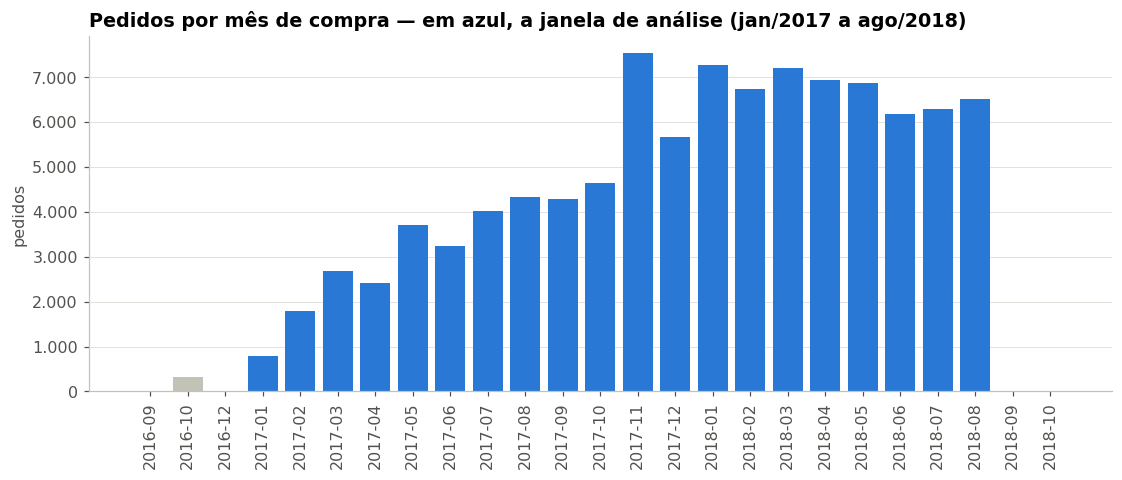

**Leitura:** fora da janela há 5 meses que somam apenas 349 pedidos
(0,4% do total). Os meses de 2016 têm volume irrisório e descontínuo
(início da operação na base), e os meses posteriores a ago/2018 estão truncados — a extração foi feita com pedidos ainda em aberto,
o que enviesaria a taxa de atraso (os atrasados ainda não teriam sido entregues). Por isso a análise usa **jan/2017 a ago/2018**.

,ano_mes,pedidos,entregues,cancelados,pct_em_aberto,na_janela
0,2016-09,4,1,2,25.0,False
1,2016-10,324,265,31,8.6,False
2,2016-12,1,1,0,0.0,False
23,2018-09,16,0,15,6.2,False
24,2018-10,4,0,4,0.0,False


In [17]:
# Atualidade: volume mensal e situação dos pedidos por mês de compra
mensal = (P.assign(ano_mes=P["order_purchase_timestamp"].dt.to_period("M").astype(str),
                   entregue=P["order_status"].eq("delivered"),
                   cancelado=P["order_status"].isin(["canceled", "unavailable"]))
            .groupby("ano_mes")
            .agg(pedidos=("order_id", "size"), entregues=("entregue", "sum"), cancelados=("cancelado", "sum"))
            .reset_index())
mensal["pct_em_aberto"] = (100 * (mensal["pedidos"] - mensal["entregues"] - mensal["cancelados"]) / mensal["pedidos"]).round(1)
mensal["na_janela"] = mensal["ano_mes"].between(INICIO_JANELA[:7], FIM_JANELA[:7])
salvar_tabela(mensal, "q3_volume_mensal")

fig, ax = plt.subplots(figsize=(12, 4.2))
cores = [AZUL if j else CINZA_CLARO for j in mensal["na_janela"]]
ax.bar(mensal["ano_mes"], mensal["pedidos"], color=cores, width=0.8)
ax.set_title("Pedidos por mês de compra — em azul, a janela de análise (jan/2017 a ago/2018)")
ax.set_ylabel("pedidos")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: num(v)))
ax.tick_params(axis="x", rotation=90)
ax.grid(axis="x", visible=False)
salvar_figura(fig, "q3_volume_mensal")
plt.show()

fora = mensal[~mensal["na_janela"]]
mostrar(f"""**Leitura:** fora da janela há {len(fora)} meses que somam apenas {num(fora['pedidos'].sum())} pedidos
({pct(100 * fora['pedidos'].sum() / mensal['pedidos'].sum())} do total). Os meses de 2016 têm volume irrisório e descontínuo
(início da operação na base), e os meses posteriores a ago/2018 estão truncados — a extração foi feita com pedidos ainda em aberto,
o que enviesaria a taxa de atraso (os atrasados ainda não teriam sido entregues). Por isso a análise usa **jan/2017 a ago/2018**.""")
display(mensal[~mensal["na_janela"]])

### 5.1 Síntese da qualidade e tratamentos adotados

| Dimensão | O que foi examinado | Tratamento (regra da Seção 6) |
|---|---|---|
| **Completude** | Nulos em todos os atributos. Nulos nas datas do pedido são esperados para status não entregues; há pedidos "delivered" sem data de entrega, produtos sem categoria ou peso e pedidos sem itens. | R06 (categoria/peso), R08 (pedidos sem itens ficam fora da fato), R09 (métricas nulas quando a data falta) |
| **Unicidade** | Chaves primárias de todas as tabelas; avaliações repetidas por pedido; duplicatas exatas na geolocalização. | R04, R05, R07 |
| **Consistência** | Ordem cronológica compra → aprovação → postagem → entrega; status × datas. | R09: durações negativas viram nulo e a remessa recebe `flag_inconsistencia_temporal` |
| **Conformidade** | Tipos (datas, números, *hashes* de 32 caracteres), UFs válidas, CEP com 5 dígitos, notas de 1 a 5, grafias de cidades, tradução de categorias. | R01, R02, R03, R06 |
| **Acurácia** | Coordenadas fora do Brasil, peso zero, preços e fretes impossíveis, prazos extremos. | R04 (descarta coordenadas), R06 (peso zero → nulo); prazos extremos mantidos e sinalizados |
| **Integridade** | Chaves estrangeiras entre pedidos, itens, produtos, vendedores, clientes e avaliações; CEPs sem geolocalização. | R12: distância nula quando falta o centroide do CEP |
| **Atualidade** | Volume e pedidos em aberto por mês. | R13: janela de análise jan/2017 a ago/2018 |

Os números exatos de cada ocorrência estão nas tabelas acima e são exportados para `evidencias/tabelas/`.

## 6. Transformação (camada *silver*) e regras de negócio

As regras abaixo transformam a *bronze* em tabelas limpas (*silver*) e, na Seção 7, no modelo estrela (*gold*). Toda regra aplicada registra **quantas linhas afetou** em um log de transformações. Esse log é gravado no Drive e carregado no BigQuery (`meta_log_transformacoes`), compondo a **linhagem** dos dados.

| Regra | Camada | O que faz | Por quê |
|---|---|---|---|
| **R01** | silver | Tipagem explícita: datas ISO 8601, números e identificadores como texto. Valores não conversíveis viram nulo e são contados. | A bronze é lida como texto para preservar o dado original. |
| **R02** | silver | Padronização de texto: cidades em minúsculas, sem acentos e sem espaços extras; UF em maiúsculas. | "São Paulo", "sao paulo" e "SAO PAULO" são a mesma cidade. |
| **R03** | silver | CEP-prefixo sempre com 5 dígitos (zeros à esquerda). | Evita que CEPs como 01310 virem 1310 e deixem de casar com a geolocalização. |
| **R04** | silver | Geolocalização: remove duplicatas, descarta coordenadas fora do Brasil e agrega por CEP-prefixo (centroide = mediana de latitude e longitude). | A tabela tem vários pontos por CEP, repetições e coordenadas no exterior. |
| **R05** | silver | Avaliações: remove linhas duplicadas e mantém uma avaliação por pedido (a respondida mais recentemente). | Evita contar a nota do mesmo pedido mais de uma vez. |
| **R06** | silver | Produtos: corrige colunas com erro de digitação (`lenght`), categoria nula → `sem_categoria`, peso zero → nulo e traduz a categoria. | Peso zero é fisicamente implausível e distorceria somas e médias. |
| **R07** | silver | Remove duplicatas de chave primária. | Garante a unicidade das entidades. |
| **R08** | gold | **Grão da fato = remessa (pedido × vendedor).** Os itens são agregados: quantidade, valor, frete, peso e prazo-limite de postagem (o maior entre os itens). | O vendedor é quem prepara e posta; a remessa é a unidade logística. |
| **R09** | gold | Durações das etapas (aprovação, preparação, transporte, total) em dias. Durações negativas viram nulo e a remessa recebe `flag_inconsistencia_temporal`. A remessa só é "entregue" com status `delivered` **e** data de entrega preenchida. | Datas fora de ordem são erro de registro e não devem contaminar médias. |
| **R10** | gold | `dias_atraso` = data da entrega − data prometida (dias corridos). **Atrasada** = `dias_atraso > 0`. | Entregar no próprio dia prometido cumpre a promessa. |
| **R11** | gold | `flag_postagem_fora_prazo` = postagem depois do prazo-limite de postagem da remessa. | Separa o atraso originado no vendedor. |
| **R12** | gold | `distancia_km` = distância em linha reta (fórmula de Haversine) entre os centroides dos CEPs de origem e destino. Nula quando falta um centroide. | Aproximação da distância de transporte (não há rota real na base). |
| **R13** | gold | `periodo_analise` na `dim_tempo`: jan/2017 a ago/2018. | Meses fora da janela têm volume irrisório ou pedidos em aberto (Seção 5). |
| **R14** | silver | **Minimização (LGPD):** descarta `customer_unique_id` e o título e o texto dos comentários; mantém só o indicador `tem_comentario`. | Dados desnecessários às perguntas não devem circular. |
| **R15** | gold | Chaves substitutas inteiras nas dimensões; `sk_data` no formato AAAAMMDD. | Chaves compactas e estáveis, independentes dos *hashes* da origem. |
| **R16** | gold | Porte do vendedor: pequeno (< 10 pedidos), médio (10 a 99) e grande (≥ 100) no período total da base. | Permite comparar vendedores de escalas diferentes. |

In [18]:
LOG = []

def registrar(regra, camada, tabela, descricao, afetadas, total):
    LOG.append({"regra": regra, "camada": camada, "tabela": tabela, "descricao": descricao,
                "linhas_afetadas": int(afetadas), "linhas_total": int(total),
                "executado_em": AGORA.strftime("%Y-%m-%d %H:%M:%S")})

def remover_duplicatas(df, chave, tabela):
    antes = len(df)
    df = df.drop_duplicates(chave).reset_index(drop=True)
    registrar("R07", "silver", tabela, f"Remoção de duplicatas pela chave {chave}", antes - len(df), antes)
    return df

def padronizar_cidade(s, tabela, coluna):
    novo = normalizar_texto(s)
    alterados = (s.astype("string") != novo).fillna(False).astype(bool).sum()
    registrar("R02", "silver", tabela, f"Padronização de texto em {coluna}", alterados, len(s))
    return novo

def padronizar_cep(s, tabela, coluna):
    novo = s.astype("string").str.strip().str.zfill(5)
    alterados = (s.astype("string") != novo).fillna(False).astype(bool).sum()
    registrar("R03", "silver", tabela, f"CEP-prefixo com 5 dígitos em {coluna}", alterados, len(s))
    return novo

# R01 — tipagem (a contagem é de VALORES não conversíveis que viraram nulo)
for nome in bronze:
    perdidos = sum(int((bronze[nome][c].notna() & bt[nome][c].isna()).sum()) for c in bronze[nome].columns)
    registrar("R01", "silver", nome, "Tipagem explícita (contagem = valores não conversíveis)", perdidos, len(bronze[nome]))

silver = {}

# Pedidos
silver["pedidos"] = remover_duplicatas(bt["pedidos"], "order_id", "pedidos").rename(columns={
    "order_id": "id_pedido", "customer_id": "id_cliente", "order_status": "status_pedido",
    "order_purchase_timestamp": "data_hora_compra", "order_approved_at": "data_hora_aprovacao",
    "order_delivered_carrier_date": "data_hora_postagem", "order_delivered_customer_date": "data_hora_entrega",
    "order_estimated_delivery_date": "data_entrega_prevista"})
silver["pedidos"]["status_pedido"] = silver["pedidos"]["status_pedido"].str.lower()

# Itens
silver["itens"] = remover_duplicatas(bt["itens"], ["order_id", "order_item_id"], "itens").rename(columns={
    "order_id": "id_pedido", "order_item_id": "id_item", "product_id": "id_produto", "seller_id": "id_vendedor",
    "shipping_limit_date": "data_limite_postagem", "price": "preco", "freight_value": "valor_frete"})

# Clientes (R14: customer_unique_id não segue adiante)
cli = remover_duplicatas(bt["clientes"], "customer_id", "clientes")
registrar("R14", "silver", "clientes", "Minimização (LGPD): customer_unique_id descartado", len(cli), len(cli))
silver["clientes"] = pd.DataFrame({
    "id_cliente": cli["customer_id"],
    "cep_prefixo": padronizar_cep(cli["customer_zip_code_prefix"], "clientes", "customer_zip_code_prefix"),
    "cidade": padronizar_cidade(cli["customer_city"], "clientes", "customer_city"),
    "uf": cli["customer_state"].str.upper(),
})

# Vendedores
ven = remover_duplicatas(bt["vendedores"], "seller_id", "vendedores")
silver["vendedores"] = pd.DataFrame({
    "id_vendedor": ven["seller_id"],
    "cep_prefixo": padronizar_cep(ven["seller_zip_code_prefix"], "vendedores", "seller_zip_code_prefix"),
    "cidade": padronizar_cidade(ven["seller_city"], "vendedores", "seller_city"),
    "uf": ven["seller_state"].str.upper(),
})

# Produtos (R06)
pr = remover_duplicatas(bt["produtos"], "product_id", "produtos").rename(columns={
    "product_id": "id_produto", "product_category_name": "categoria",
    "product_name_lenght": "comprimento_nome", "product_description_lenght": "comprimento_descricao",
    "product_photos_qty": "qtd_fotos", "product_weight_g": "peso_g", "product_length_cm": "comprimento_cm",
    "product_height_cm": "altura_cm", "product_width_cm": "largura_cm"})
registrar("R06", "silver", "produtos", "Colunas renomeadas (corrige 'lenght' → comprimento)", 0, len(pr))
sem_categoria = pr["categoria"].isna()
pr["categoria"] = pr["categoria"].fillna("sem_categoria")
registrar("R06", "silver", "produtos", "Categoria nula → 'sem_categoria'", sem_categoria.sum(), len(pr))
peso_zero = pr["peso_g"].eq(0)
pr.loc[peso_zero, "peso_g"] = np.nan
registrar("R06", "silver", "produtos", "Peso igual a zero → nulo", peso_zero.sum(), len(pr))
silver["categorias"] = (bt["categorias"].rename(columns={"product_category_name": "categoria",
                                                          "product_category_name_english": "categoria_en"})
                        .drop_duplicates("categoria").reset_index(drop=True))
pr = pr.merge(silver["categorias"], on="categoria", how="left")
sem_traducao = pr["categoria_en"].isna()
pr["categoria_en"] = pr["categoria_en"].fillna(pr["categoria"])
registrar("R06", "silver", "produtos", "Categoria sem tradução (inclui 'sem_categoria') → nome original", sem_traducao.sum(), len(pr))
silver["produtos"] = pr

# Avaliações (R05 + R14)
av = bt["avaliacoes"]
antes = len(av)
av = av.drop_duplicates()
registrar("R05", "silver", "avaliacoes", "Remoção de linhas totalmente duplicadas", antes - len(av), antes)
av = av.assign(tem_comentario=(av["review_comment_message"].notna() | av["review_comment_title"].notna()).astype(bool))
antes = len(av)
av = (av.sort_values(["order_id", "review_answer_timestamp", "review_creation_date"], ascending=[True, False, False])
        .drop_duplicates("order_id"))
registrar("R05", "silver", "avaliacoes", "Uma avaliação por pedido (a respondida mais recentemente)", antes - len(av), antes)
registrar("R14", "silver", "avaliacoes", "Minimização (LGPD): título e texto dos comentários descartados", len(av), len(av))
silver["avaliacoes"] = av.rename(columns={
    "review_id": "id_avaliacao", "order_id": "id_pedido", "review_score": "nota",
    "review_creation_date": "data_criacao", "review_answer_timestamp": "data_resposta"})[
    ["id_avaliacao", "id_pedido", "nota", "tem_comentario", "data_criacao", "data_resposta"]].reset_index(drop=True)

# Geolocalização (R03 + R04)
geo = bt["geolocalizacao"].copy()
geo["geolocation_zip_code_prefix"] = padronizar_cep(geo["geolocation_zip_code_prefix"], "geolocalizacao", "geolocation_zip_code_prefix")
antes = len(geo)
geo = geo.drop_duplicates()
registrar("R04", "silver", "geolocalizacao", "Remoção de linhas duplicadas", antes - len(geo), antes)
dentro = geo["geolocation_lat"].between(*LAT_BR) & geo["geolocation_lng"].between(*LON_BR)
registrar("R04", "silver", "geolocalizacao", "Descarte de coordenadas fora do território brasileiro", (~dentro).sum(), len(geo))
geo = geo[dentro]
silver["geolocalizacao"] = (geo.groupby("geolocation_zip_code_prefix")
                              .agg(latitude=("geolocation_lat", "median"), longitude=("geolocation_lng", "median"),
                                   qtd_pontos=("geolocation_lat", "size"))
                              .reset_index().rename(columns={"geolocation_zip_code_prefix": "cep_prefixo"}))
registrar("R04", "silver", "geolocalizacao", "Agregação por CEP-prefixo (centroide = mediana)", len(geo) - len(silver["geolocalizacao"]), len(geo))

# Persistência da silver no Drive
resumo_silver = []
for nome, df in silver.items():
    caminho = os.path.join(DIR["silver"], f"{nome}.parquet")
    df.to_parquet(caminho, index=False)
    resumo_silver.append({"tabela": nome, "linhas": len(df), "colunas": df.shape[1], "arquivo": caminho})
mostrar("**Camada silver gravada no Drive** (a tabela de pagamentos não segue adiante: está fora do escopo das perguntas).")
display(pd.DataFrame(resumo_silver))

**Camada silver gravada no Drive** (a tabela de pagamentos não segue adiante: está fora do escopo das perguntas).

,tabela,linhas,colunas,arquivo
0,pedidos,99441,8,/content/drive/MyDrive/mvp_olist/silver/pedidos.parquet
1,itens,112650,7,/content/drive/MyDrive/mvp_olist/silver/itens.parquet
2,clientes,99441,4,/content/drive/MyDrive/mvp_olist/silver/clientes.parquet
3,vendedores,3095,4,/content/drive/MyDrive/mvp_olist/silver/vendedores.parquet
4,categorias,71,2,/content/drive/MyDrive/mvp_olist/silver/categorias.parquet
5,produtos,32951,10,/content/drive/MyDrive/mvp_olist/silver/produtos.parquet
6,avaliacoes,98673,6,/content/drive/MyDrive/mvp_olist/silver/avaliacoes.parquet
7,geolocalizacao,19010,4,/content/drive/MyDrive/mvp_olist/silver/geolocalizacao.parquet


## 7. Modelagem (camada *gold*) — esquema estrela e Catálogo de Dados

### 7.1 Modelo escolhido

O Data Warehouse segue um **esquema estrela** (Kimball) com uma tabela fato e três dimensões. As dimensões são pequenas e foram mantidas desnormalizadas: o *snowflake* só acrescentaria junções sem ganho analítico.

**Grão da fato — uma linha por remessa (pedido × vendedor).** É a escolha central do modelo:

* o **vendedor** é quem prepara e posta o pacote. O prazo-limite de postagem e a origem geográfica são atributos do vendedor, e não do pedido. Com esse grão, a etapa do vendedor (P4) e a distância (P3) ficam corretas mesmo em pedidos com itens de vendedores diferentes;
* um grão por **item** repetiria as datas e a nota do pedido em cada item e inflaria as contagens de entregas;
* um grão por **pedido** perderia o vendedor nos pedidos com mais de um vendedor.

Nos poucos pedidos com mais de um vendedor, a nota de avaliação e as datas do pedido se repetem nas remessas. Por isso, a análise de satisfação (P5) agrega por pedido antes de calcular, e a fato traz `flag_multivendedor` para que isso seja auditável.

| Tabela | Tipo | Grão / conteúdo |
|---|---|---|
| `fato_entrega` | Fato | Uma linha por remessa. **Medidas aditivas:** `qtd_itens`, `valor_produtos`, `valor_frete`, `peso_total_kg`. **Não aditivas** (usar média, mediana ou percentil): `distancia_km`, `dias_*`, `nota_avaliacao`. **Indicadores:** `flag_*`. **Dimensão degenerada:** `id_pedido`. |
| `dim_tempo` | Dimensão (com papéis) | Um dia por linha. Usada três vezes: data da compra, data prometida e data da entrega. |
| `dim_localidade` | Dimensão (com papéis) | Um CEP-prefixo por linha, com cidade, UF, região e centroide geográfico. Usada duas vezes: **origem** (vendedor) e **destino** (cliente). |
| `dim_vendedor` | Dimensão | Um vendedor por linha, com volume histórico e porte. |

Além do modelo estrela, o dataset do BigQuery recebe quatro tabelas de metadados: `meta_catalogo_dados`, `meta_log_transformacoes`, `meta_coleta` e `meta_perfil_qualidade`.

In [19]:
REGIAO = {"AC": "Norte", "AM": "Norte", "AP": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
          "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
          "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
          "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MS": "Centro-Oeste", "MT": "Centro-Oeste",
          "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
          "PR": "Sul", "RS": "Sul", "SC": "Sul"}

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = (np.radians(np.asarray(v, dtype=float)) for v in (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))

def sk_data(serie):
    return pd.to_numeric(serie.dt.strftime("%Y%m%d"), errors="coerce").astype("Int64")

# ---------- dim_localidade (R15) ----------
base_loc = pd.concat([silver["clientes"][["cep_prefixo", "cidade", "uf"]],
                      silver["vendedores"][["cep_prefixo", "cidade", "uf"]]])
dim_localidade = (base_loc.groupby(["cep_prefixo", "cidade", "uf"]).size().reset_index(name="n")
                  .sort_values(["cep_prefixo", "n", "cidade"], ascending=[True, False, True])
                  .drop_duplicates("cep_prefixo").drop(columns="n")
                  .merge(silver["geolocalizacao"][["cep_prefixo", "latitude", "longitude"]], on="cep_prefixo", how="left")
                  .reset_index(drop=True))
dim_localidade["regiao"] = dim_localidade["uf"].map(REGIAO)
dim_localidade.insert(0, "sk_localidade", np.arange(1, len(dim_localidade) + 1))
registrar("R15", "gold", "dim_localidade", "Chave substituta por CEP-prefixo (cidade/UF = moda)", len(dim_localidade), len(dim_localidade))

# ---------- dim_vendedor (R15, R16) ----------
pedidos_por_vendedor = silver["itens"].groupby("id_vendedor")["id_pedido"].nunique()
dim_vendedor = silver["vendedores"][["id_vendedor"]].sort_values("id_vendedor").reset_index(drop=True)
dim_vendedor["qtd_pedidos"] = dim_vendedor["id_vendedor"].map(pedidos_por_vendedor).fillna(0).astype("int64")
dim_vendedor["porte_vendedor"] = pd.cut(dim_vendedor["qtd_pedidos"], bins=[-1, 9, 99, np.inf],
                                        labels=["pequeno", "médio", "grande"]).astype("string")
dim_vendedor.insert(0, "sk_vendedor", np.arange(1, len(dim_vendedor) + 1))
registrar("R16", "gold", "dim_vendedor", "Porte do vendedor por volume de pedidos", len(dim_vendedor), len(dim_vendedor))

# ---------- dim_tempo (R13, R15) ----------
ped = silver["pedidos"]
datas = pd.concat([ped["data_hora_compra"], ped["data_entrega_prevista"], ped["data_hora_entrega"]]).dropna()
dim_tempo = pd.DataFrame({"data": pd.date_range(datas.min().normalize(), datas.max().normalize(), freq="D")})
dim_tempo["sk_data"] = sk_data(dim_tempo["data"])
dim_tempo["ano"] = dim_tempo["data"].dt.year
dim_tempo["trimestre"] = dim_tempo["data"].dt.quarter
dim_tempo["mes"] = dim_tempo["data"].dt.month
dim_tempo["nome_mes"] = dim_tempo["mes"].map(lambda m: ["janeiro", "fevereiro", "março", "abril", "maio", "junho", "julho",
                                                        "agosto", "setembro", "outubro", "novembro", "dezembro"][m - 1])
dim_tempo["ano_mes"] = dim_tempo["data"].dt.strftime("%Y-%m")
dim_tempo["dia"] = dim_tempo["data"].dt.day
dim_tempo["dia_semana"] = dim_tempo["data"].dt.dayofweek + 1
dim_tempo["nome_dia_semana"] = dim_tempo["dia_semana"].map(lambda d: ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira",
                                                                      "sexta-feira", "sábado", "domingo"][d - 1])
dim_tempo["fim_de_semana"] = dim_tempo["dia_semana"] >= 6
dim_tempo["periodo_analise"] = dim_tempo["data"].between(pd.Timestamp(INICIO_JANELA), pd.Timestamp(FIM_JANELA))
registrar("R13", "gold", "dim_tempo", "Janela de análise marcada em periodo_analise", int(dim_tempo["periodo_analise"].sum()), len(dim_tempo))

# ---------- fato_entrega (R08 a R12) ----------
itens = silver["itens"].merge(silver["produtos"][["id_produto", "peso_g"]], on="id_produto", how="left")
chave = ["id_pedido", "id_vendedor"]
remessas = (itens.groupby(chave)
                 .agg(qtd_itens=("id_item", "size"), valor_produtos=("preco", "sum"),
                      valor_frete=("valor_frete", "sum"), data_limite_postagem=("data_limite_postagem", "max"))
                 .reset_index()
                 .merge((itens.groupby(chave)["peso_g"].sum(min_count=1) / 1000).rename("peso_total_kg").reset_index(),
                        on=chave, how="left"))
sem_itens = (~ped["id_pedido"].isin(remessas["id_pedido"])).sum()
registrar("R08", "gold", "fato_entrega", f"Itens agregados em remessas (pedido × vendedor); {sem_itens} pedidos sem itens ficam fora", len(itens) - len(remessas), len(itens))

f = (remessas.merge(ped, on="id_pedido", how="inner")
             .merge(silver["clientes"][["id_cliente", "cep_prefixo"]].rename(columns={"cep_prefixo": "cep_destino"}), on="id_cliente", how="left")
             .merge(silver["vendedores"][["id_vendedor", "cep_prefixo"]].rename(columns={"cep_prefixo": "cep_origem"}), on="id_vendedor", how="left")
             .merge(silver["avaliacoes"][["id_pedido", "nota"]].rename(columns={"nota": "nota_avaliacao"}), on="id_pedido", how="left"))

sk_loc = dim_localidade.set_index("cep_prefixo")["sk_localidade"]
f["sk_localidade_origem"] = f["cep_origem"].map(sk_loc)
f["sk_localidade_destino"] = f["cep_destino"].map(sk_loc)
f["sk_vendedor"] = f["id_vendedor"].map(dim_vendedor.set_index("id_vendedor")["sk_vendedor"])
f["sk_data_compra"] = sk_data(f["data_hora_compra"])
f["sk_data_entrega_prevista"] = sk_data(f["data_entrega_prevista"])
f["sk_data_entrega"] = sk_data(f["data_hora_entrega"])

# R09 — durações das etapas, em dias
def dias_entre(inicio, fim):
    return ((fim - inicio).dt.total_seconds() / 86400).round(2)

f["dias_aprovacao"] = dias_entre(f["data_hora_compra"], f["data_hora_aprovacao"])
f["dias_preparacao"] = dias_entre(f["data_hora_aprovacao"], f["data_hora_postagem"])
f["dias_transporte"] = dias_entre(f["data_hora_postagem"], f["data_hora_entrega"])
f["dias_entrega"] = dias_entre(f["data_hora_compra"], f["data_hora_entrega"])
etapas = ["dias_aprovacao", "dias_preparacao", "dias_transporte", "dias_entrega"]
negativas = f[etapas].lt(0)
f["flag_inconsistencia_temporal"] = negativas.any(axis=1)
for col in etapas:
    f.loc[negativas[col], col] = np.nan
registrar("R09", "gold", "fato_entrega", "Durações negativas (etapas fora de ordem) → nulo + flag", f["flag_inconsistencia_temporal"].sum(), len(f))

f["flag_entregue"] = f["status_pedido"].eq("delivered") & f["data_hora_entrega"].notna()
registrar("R09", "gold", "fato_entrega", "Remessas sem status 'delivered' ou sem data de entrega não contam como entregues", (~f["flag_entregue"]).sum(), len(f))

# R10 — atraso em dias corridos
f["dias_prazo_prometido"] = (f["data_entrega_prevista"].dt.normalize() - f["data_hora_compra"].dt.normalize()).dt.days
atraso = (f["data_hora_entrega"].dt.normalize() - f["data_entrega_prevista"].dt.normalize()).dt.days
f["dias_atraso"] = atraso.where(f["flag_entregue"]).astype("Int64")
f["flag_atraso"] = f["dias_atraso"].gt(0)            # nulo quando não entregue
registrar("R10", "gold", "fato_entrega", "Remessas entregues depois da data prometida", int(f["flag_atraso"].sum()), int(f["flag_entregue"].sum()))

# R11 — postagem depois do prazo-limite
f["flag_postagem_fora_prazo"] = (f["data_hora_postagem"] > f["data_limite_postagem"]).astype("boolean").mask(f["data_hora_postagem"].isna())
registrar("R11", "gold", "fato_entrega", "Remessas postadas depois do prazo-limite", int(f["flag_postagem_fora_prazo"].sum()), int(f["data_hora_postagem"].notna().sum()))

# R12 — distância origem → destino
centro = dim_localidade.set_index("sk_localidade")[["latitude", "longitude"]]
o = centro.reindex(f["sk_localidade_origem"]).to_numpy()
d = centro.reindex(f["sk_localidade_destino"]).to_numpy()
f["distancia_km"] = np.round(haversine_km(o[:, 0], o[:, 1], d[:, 0], d[:, 1]), 1)
registrar("R12", "gold", "fato_entrega", "Distância nula por falta de centroide do CEP", f["distancia_km"].isna().sum(), len(f))

f["flag_multivendedor"] = f.groupby("id_pedido")["id_vendedor"].transform("size") > 1
f["valor_produtos"] = f["valor_produtos"].round(2)
f["valor_frete"] = f["valor_frete"].round(2)
f["peso_total_kg"] = f["peso_total_kg"].round(3)
fato_entrega = f

mostrar(f"""**Modelo estrela montado:** `fato_entrega` com {num(len(fato_entrega))} remessas de {num(fato_entrega['id_pedido'].nunique())} pedidos
({num(fato_entrega['flag_multivendedor'].sum())} remessas pertencem a pedidos com mais de um vendedor) ·
`dim_tempo` com {num(len(dim_tempo))} dias · `dim_localidade` com {num(len(dim_localidade))} CEPs-prefixo ·
`dim_vendedor` com {num(len(dim_vendedor))} vendedores.""")

**Modelo estrela montado:** `fato_entrega` com 100.010 remessas de 98.666 pedidos
(2.622 remessas pertencem a pedidos com mais de um vendedor) ·
`dim_tempo` com 800 dias · `dim_localidade` com 15.078 CEPs-prefixo ·
`dim_vendedor` com 3.095 vendedores.

### 7.2 Catálogo de Dados

O catálogo é definido **uma única vez**, na célula abaixo, e dele saem três produtos:

1. a **documentação** (`catalogo/catalogo_dados.md` e `.csv` no repositório e no Drive);
2. o **esquema do BigQuery**: tipos, obrigatoriedade (`REQUIRED`/`NULLABLE`) e a descrição de cada coluna, visível no console;
3. a **validação automática** dos dados contra os domínios declarados (seção 7.3).

Para cada atributo, o catálogo registra: nome, tipo, descrição, domínio (faixa mínima e máxima esperada, lista de valores válidos ou padrão), obrigatoriedade, significado do nulo e linhagem (origem na base da Olist e regras aplicadas).

In [20]:
#@title Catálogo de Dados (definição única: gera documentação, esquema do BigQuery e validação)
MESES = ["janeiro", "fevereiro", "março", "abril", "maio", "junho", "julho", "agosto",
         "setembro", "outubro", "novembro", "dezembro"]
DIAS_SEMANA = ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira", "sexta-feira", "sábado", "domingo"]
UFS = ["AC", "AL", "AM", "AP", "BA", "CE", "DF", "ES", "GO", "MA", "MG", "MS", "MT", "PA",
       "PB", "PE", "PI", "PR", "RJ", "RN", "RO", "RR", "RS", "SC", "SE", "SP", "TO"]
REGIOES = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
STATUS = ["delivered", "shipped", "canceled", "unavailable", "invoiced", "processing", "created", "approved"]
HEX32 = r"^[0-9a-f]{32}$"
_catalogo = []

def atributo(tabela, nome, tipo, logico, descricao, dominio=None, obrigatorio=True, nulo="Não admite nulo.", linhagem=""):
    """dominio: ("faixa", min, max) | ("valores", [...]) | ("padrao", regex) | None"""
    _catalogo.append(dict(tabela=tabela, atributo=nome, tipo_bigquery=tipo, tipo_logico=logico,
                          descricao=descricao, dominio=dominio, obrigatorio=obrigatorio,
                          significado_nulo=nulo, linhagem=linhagem))

# ---------------- dim_tempo ----------------
T = "dim_tempo"
atributo(T, "sk_data", "INT64", "numérico", "Chave substituta da data, no formato AAAAMMDD (PK).", ("faixa", 20160901, 20181231), linhagem="Gerada a partir de `data` (R15).")
atributo(T, "data", "DATE", "data", "Data do calendário.", ("faixa", "2016-09-01", "2018-12-31"), linhagem="Calendário contínuo entre a menor e a maior data de compra, prometida ou de entrega em olist_orders_dataset.")
atributo(T, "ano", "INT64", "numérico", "Ano civil.", ("faixa", 2016, 2018), linhagem="Derivado de `data`.")
atributo(T, "trimestre", "INT64", "numérico", "Trimestre do ano.", ("faixa", 1, 4), linhagem="Derivado de `data`.")
atributo(T, "mes", "INT64", "numérico", "Mês do ano.", ("faixa", 1, 12), linhagem="Derivado de `data`.")
atributo(T, "nome_mes", "STRING", "categórico", "Nome do mês em português.", ("valores", MESES), linhagem="Derivado de `data`.")
atributo(T, "ano_mes", "STRING", "categórico", "Ano e mês no formato AAAA-MM (agrupamento mensal).", ("padrao", r"^\d{4}-(0[1-9]|1[0-2])$"), linhagem="Derivado de `data`.")
atributo(T, "dia", "INT64", "numérico", "Dia do mês.", ("faixa", 1, 31), linhagem="Derivado de `data`.")
atributo(T, "dia_semana", "INT64", "numérico", "Dia da semana ISO 8601 (1 = segunda-feira … 7 = domingo).", ("faixa", 1, 7), linhagem="Derivado de `data`.")
atributo(T, "nome_dia_semana", "STRING", "categórico", "Nome do dia da semana em português.", ("valores", DIAS_SEMANA), linhagem="Derivado de `data`.")
atributo(T, "fim_de_semana", "BOOL", "booleano", "Verdadeiro para sábado e domingo.", ("valores", [True, False]), linhagem="Derivado de `dia_semana`.")
atributo(T, "periodo_analise", "BOOL", "booleano", "Verdadeiro se a data está na janela de análise (jan/2017 a ago/2018).", ("valores", [True, False]), linhagem="Regra R13 (justificada pela análise de atualidade).")

# ---------------- dim_localidade ----------------
T = "dim_localidade"
atributo(T, "sk_localidade", "INT64", "numérico", "Chave substituta da localidade (PK).", ("faixa", 1, 99999), linhagem="Sequencial (R15).")
atributo(T, "cep_prefixo", "STRING", "categórico", "Cinco primeiros dígitos do CEP (chave natural).", ("padrao", r"^\d{5}$"), linhagem="customer_zip_code_prefix ∪ seller_zip_code_prefix, com zeros à esquerda (R03).")
atributo(T, "cidade", "STRING", "texto", "Município, em minúsculas e sem acentos; quando o CEP-prefixo abrange mais de uma cidade, a mais frequente.", None, linhagem="customer_city / seller_city padronizados (R02); moda por CEP-prefixo.")
atributo(T, "uf", "STRING", "categórico", "Unidade federativa (sigla).", ("valores", UFS), linhagem="customer_state / seller_state; moda por CEP-prefixo.")
atributo(T, "regiao", "STRING", "categórico", "Grande região do IBGE.", ("valores", REGIOES), linhagem="Derivada da UF (divisão regional do IBGE).")
atributo(T, "latitude", "FLOAT64", "numérico", "Latitude do centroide do CEP-prefixo (graus decimais).", ("faixa", -33.75, 5.30), obrigatorio=False, nulo="CEP-prefixo sem geolocalização válida na origem.", linhagem="Mediana de geolocation_lat após deduplicação e descarte de pontos fora do Brasil (R04).")
atributo(T, "longitude", "FLOAT64", "numérico", "Longitude do centroide do CEP-prefixo (graus decimais).", ("faixa", -73.99, -34.79), obrigatorio=False, nulo="CEP-prefixo sem geolocalização válida na origem.", linhagem="Mediana de geolocation_lng após deduplicação e descarte de pontos fora do Brasil (R04).")

# ---------------- dim_vendedor ----------------
T = "dim_vendedor"
atributo(T, "sk_vendedor", "INT64", "numérico", "Chave substituta do vendedor (PK).", ("faixa", 1, 99999), linhagem="Sequencial (R15).")
atributo(T, "id_vendedor", "STRING", "texto", "Identificador anonimizado do vendedor (hash de 32 caracteres).", ("padrao", HEX32), linhagem="olist_sellers_dataset.seller_id.")
atributo(T, "qtd_pedidos", "INT64", "numérico", "Quantidade de pedidos distintos do vendedor em toda a base.", ("faixa", 0, 5000), linhagem="Contagem distinta de order_id por seller_id em olist_order_items_dataset.")
atributo(T, "porte_vendedor", "STRING", "categórico", "Porte pelo volume de pedidos: pequeno (< 10), médio (10 a 99), grande (≥ 100).", ("valores", ["pequeno", "médio", "grande"]), linhagem="Derivado de `qtd_pedidos` (R16).")

# ---------------- fato_entrega ----------------
T = "fato_entrega"
atributo(T, "id_pedido", "STRING", "texto", "Identificador anonimizado do pedido (dimensão degenerada). Com sk_vendedor forma a chave da remessa.", ("padrao", HEX32), linhagem="olist_orders_dataset.order_id.")
atributo(T, "sk_vendedor", "INT64", "numérico", "Vendedor responsável pela remessa (FK → dim_vendedor).", ("faixa", 1, 99999), linhagem="seller_id de olist_order_items_dataset → dim_vendedor (R08).")
atributo(T, "sk_localidade_origem", "INT64", "numérico", "Localidade do vendedor (FK → dim_localidade, papel 'origem').", ("faixa", 1, 99999), linhagem="seller_zip_code_prefix → dim_localidade.")
atributo(T, "sk_localidade_destino", "INT64", "numérico", "Localidade do cliente (FK → dim_localidade, papel 'destino').", ("faixa", 1, 99999), linhagem="customer_zip_code_prefix → dim_localidade.")
atributo(T, "sk_data_compra", "INT64", "numérico", "Data da compra (FK → dim_tempo).", ("faixa", 20160901, 20181231), linhagem="order_purchase_timestamp (R01, R15).")
atributo(T, "sk_data_entrega_prevista", "INT64", "numérico", "Data de entrega prometida ao cliente (FK → dim_tempo).", ("faixa", 20160901, 20181231), linhagem="order_estimated_delivery_date (R01, R15).")
atributo(T, "sk_data_entrega", "INT64", "numérico", "Data da entrega ao cliente (FK → dim_tempo).", ("faixa", 20160901, 20181231), obrigatorio=False, nulo="Remessa ainda não entregue ou sem data de entrega registrada.", linhagem="order_delivered_customer_date (R01, R15).")
atributo(T, "status_pedido", "STRING", "categórico", "Status do pedido na data da extração.", ("valores", STATUS), linhagem="olist_orders_dataset.order_status.")
atributo(T, "data_hora_compra", "DATETIME", "data", "Data e hora da compra.", ("faixa", "2016-09-01", "2018-12-31"), linhagem="order_purchase_timestamp (R01).")
atributo(T, "data_hora_aprovacao", "DATETIME", "data", "Data e hora da aprovação do pagamento.", ("faixa", "2016-09-01", "2018-12-31"), obrigatorio=False, nulo="Pagamento não aprovado (pedido cancelado ou em aberto).", linhagem="order_approved_at (R01).")
atributo(T, "data_hora_postagem", "DATETIME", "data", "Data e hora em que o vendedor entregou o pacote à transportadora.", ("faixa", "2016-09-01", "2018-12-31"), obrigatorio=False, nulo="Pacote ainda não postado.", linhagem="order_delivered_carrier_date (R01).")
atributo(T, "data_hora_entrega", "DATETIME", "data", "Data e hora da entrega ao cliente.", ("faixa", "2016-09-01", "2018-12-31"), obrigatorio=False, nulo="Remessa ainda não entregue.", linhagem="order_delivered_customer_date (R01).")
atributo(T, "data_limite_postagem", "DATETIME", "data", "Prazo-limite para o vendedor postar a remessa (o maior entre os itens).", ("faixa", "2016-09-01", "2018-12-31"), linhagem="MAX(shipping_limit_date) dos itens da remessa (R08).")
atributo(T, "data_entrega_prevista", "DATE", "data", "Data de entrega prometida ao cliente no momento da compra.", ("faixa", "2016-09-01", "2018-12-31"), linhagem="order_estimated_delivery_date (R01).")
atributo(T, "qtd_itens", "INT64", "numérico", "Quantidade de itens na remessa.", ("faixa", 1, 30), linhagem="COUNT(order_item_id) por pedido × vendedor (R08).")
atributo(T, "valor_produtos", "FLOAT64", "numérico", "Soma do preço dos itens da remessa (R$).", ("faixa", 0.01, 15000), linhagem="SUM(price) por pedido × vendedor (R08).")
atributo(T, "valor_frete", "FLOAT64", "numérico", "Soma do frete dos itens da remessa (R$).", ("faixa", 0, 2000), linhagem="SUM(freight_value) por pedido × vendedor (R08).")
atributo(T, "peso_total_kg", "FLOAT64", "numérico", "Peso total dos itens da remessa (kg).", ("faixa", 0.001, 500), obrigatorio=False, nulo="Nenhum item da remessa tem peso válido.", linhagem="SUM(product_weight_g) / 1000, com peso zero tratado como nulo (R06, R08).")
atributo(T, "distancia_km", "FLOAT64", "numérico", "Distância em linha reta entre os centroides dos CEPs de origem e destino (km).", ("faixa", 0, 4500), obrigatorio=False, nulo="Falta o centroide do CEP de origem ou de destino.", linhagem="Haversine entre latitude/longitude da dim_localidade (R12).")
atributo(T, "dias_aprovacao", "FLOAT64", "numérico", "Dias entre a compra e a aprovação do pagamento.", ("faixa", 0, 60), obrigatorio=False, nulo="Data ausente ou etapa fora de ordem (R09).", linhagem="data_hora_aprovacao − data_hora_compra (R09).")
atributo(T, "dias_preparacao", "FLOAT64", "numérico", "Dias entre a aprovação e a postagem (etapa do vendedor).", ("faixa", 0, 180), obrigatorio=False, nulo="Data ausente ou etapa fora de ordem (R09).", linhagem="data_hora_postagem − data_hora_aprovacao (R09).")
atributo(T, "dias_transporte", "FLOAT64", "numérico", "Dias entre a postagem e a entrega (etapa da transportadora).", ("faixa", 0, 210), obrigatorio=False, nulo="Data ausente ou etapa fora de ordem (R09).", linhagem="data_hora_entrega − data_hora_postagem (R09).")
atributo(T, "dias_entrega", "FLOAT64", "numérico", "Dias entre a compra e a entrega (prazo total realizado).", ("faixa", 0, 210), obrigatorio=False, nulo="Remessa não entregue.", linhagem="data_hora_entrega − data_hora_compra (R09).")
atributo(T, "dias_prazo_prometido", "INT64", "numérico", "Dias corridos entre a data da compra e a data prometida.", ("faixa", 0, 160), linhagem="data_entrega_prevista − data da compra.")
atributo(T, "dias_atraso", "INT64", "numérico", "Dias corridos entre a data prometida e a data da entrega (positivo = atraso; negativo = antecipação).", ("faixa", -150, 190), obrigatorio=False, nulo="Remessa não entregue.", linhagem="data da entrega − data_entrega_prevista (R10).")
atributo(T, "nota_avaliacao", "INT64", "numérico", "Nota dada pelo cliente ao pedido (1 a 5 estrelas).", ("faixa", 1, 5), obrigatorio=False, nulo="Pedido sem avaliação.", linhagem="review_score da avaliação mais recente do pedido (R05).")
atributo(T, "flag_entregue", "BOOL", "booleano", "Verdadeiro se o status é 'delivered' e há data de entrega.", ("valores", [True, False]), linhagem="Regra R09.")
atributo(T, "flag_atraso", "BOOL", "booleano", "Verdadeiro se a remessa foi entregue depois da data prometida.", ("valores", [True, False]), obrigatorio=False, nulo="Remessa não entregue.", linhagem="dias_atraso > 0 (R10).")
atributo(T, "flag_postagem_fora_prazo", "BOOL", "booleano", "Verdadeiro se o vendedor postou depois do prazo-limite de postagem.", ("valores", [True, False]), obrigatorio=False, nulo="Remessa não postada.", linhagem="data_hora_postagem > data_limite_postagem (R11).")
atributo(T, "flag_inconsistencia_temporal", "BOOL", "booleano", "Verdadeiro se alguma etapa tinha datas fora de ordem (duração negativa).", ("valores", [True, False]), linhagem="Regra R09.")
atributo(T, "flag_multivendedor", "BOOL", "booleano", "Verdadeiro se o pedido tem itens de mais de um vendedor (mais de uma remessa).", ("valores", [True, False]), linhagem="Contagem de vendedores por order_id (R08).")

CATALOGO = pd.DataFrame(_catalogo)

def dominio_texto(d):
    if d is None:
        return "Texto livre"
    tipo = d[0]
    if tipo == "faixa":
        return f"{d[1]} a {d[2]}"
    if tipo == "valores":
        vals = [("verdadeiro" if v is True else "falso" if v is False else str(v)) for v in d[1]]
        return ", ".join(vals)
    return f"Padrão {d[1]}"

CATALOGO["dominio_texto"] = CATALOGO["dominio"].map(dominio_texto)

def catalogo_legivel():
    return (CATALOGO.assign(obrigatorio=CATALOGO["obrigatorio"].map({True: "Sim", False: "Não"}))
            [["tabela", "atributo", "tipo_bigquery", "tipo_logico", "descricao", "dominio_texto",
              "obrigatorio", "significado_nulo", "linhagem"]]
            .rename(columns={"tabela": "Tabela", "atributo": "Atributo", "tipo_bigquery": "Tipo (BigQuery)",
                             "tipo_logico": "Tipo lógico", "descricao": "Descrição", "dominio_texto": "Domínio",
                             "obrigatorio": "Obrigatório", "significado_nulo": "Significado do nulo",
                             "linhagem": "Linhagem"}))

print(f"Catálogo com {len(CATALOGO)} atributos em {CATALOGO['tabela'].nunique()} tabelas.")

Catálogo com 54 atributos em 4 tabelas.


In [21]:
display(catalogo_legivel())

,Tabela,Atributo,Tipo (BigQuery),Tipo lógico,Descrição,Domínio,Obrigatório,Significado do nulo,Linhagem
0,dim_tempo,sk_data,INT64,numérico,"Chave substituta da data, no formato AAAAMMDD (PK).",20160901 a 20181231,Sim,Não admite nulo.,Gerada a partir de `data` (R15).
1,dim_tempo,data,DATE,data,Data do calendário.,2016-09-01 a 2018-12-31,Sim,Não admite nulo.,"Calendário contínuo entre a menor e a maior data de compra, prometida ou de entrega em olist_orders_dataset."
2,dim_tempo,ano,INT64,numérico,Ano civil.,2016 a 2018,Sim,Não admite nulo.,Derivado de `data`.
3,dim_tempo,trimestre,INT64,numérico,Trimestre do ano.,1 a 4,Sim,Não admite nulo.,Derivado de `data`.
4,dim_tempo,mes,INT64,numérico,Mês do ano.,1 a 12,Sim,Não admite nulo.,Derivado de `data`.
5,dim_tempo,nome_mes,STRING,categórico,Nome do mês em português.,"janeiro, fevereiro, março, abril, maio, junho, julho, agosto, setembro, outubro, novembro, dezembro",Sim,Não admite nulo.,Derivado de `data`.
6,dim_tempo,ano_mes,STRING,categórico,Ano e mês no formato AAAA-MM (agrupamento mensal).,Padrão ^\d{4}-(0[1-9]|1[0-2])$,Sim,Não admite nulo.,Derivado de `data`.
7,dim_tempo,dia,INT64,numérico,Dia do mês.,1 a 31,Sim,Não admite nulo.,Derivado de `data`.
8,dim_tempo,dia_semana,INT64,numérico,Dia da semana ISO 8601 (1 = segunda-feira … 7 = domingo).,1 a 7,Sim,Não admite nulo.,Derivado de `data`.
9,dim_tempo,nome_dia_semana,STRING,categórico,Nome do dia da semana em português.,"segunda-feira, terça-feira, quarta-feira, quinta-feira, sexta-feira, sábado, domingo",Sim,Não admite nulo.,Derivado de `data`.


Figura salva em /content/drive/MyDrive/mvp_olist/evidencias/graficos/m1_modelo_estrela.png


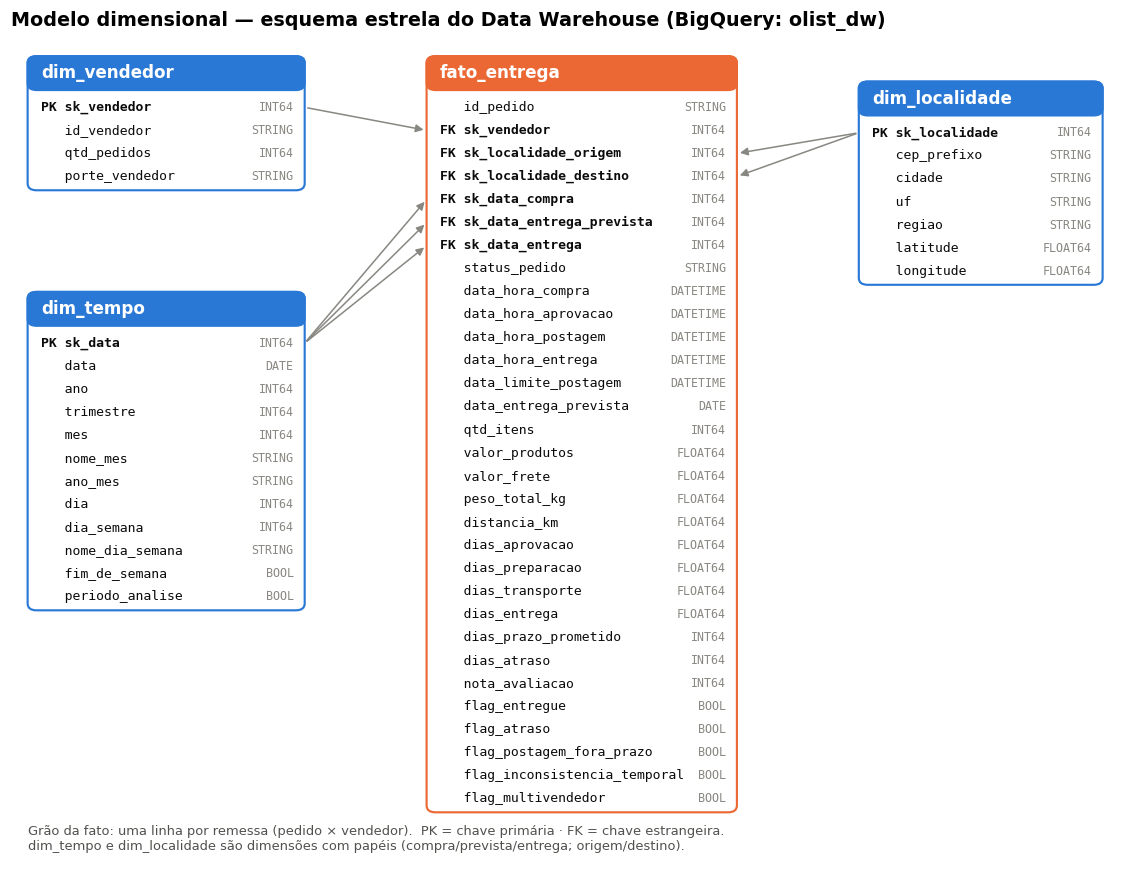

In [22]:
#@title Diagrama do modelo estrela (gerado a partir do Catálogo de Dados)
def desenhar_modelo_estrela(catalogo, caminho=None):
    cabecalho, passo = 0.04, 0.0272
    n_attrs = catalogo.groupby("tabela").size()
    altura = lambda t: cabecalho + passo * (n_attrs[t] + 0.35)
    topo = 0.975
    caixas = {   # (x, y_base, largura, altura)
        "dim_vendedor":   (0.015, topo - altura("dim_vendedor"), 0.25, altura("dim_vendedor")),
        "dim_tempo":      (0.015, topo - altura("dim_vendedor") - 0.12 - altura("dim_tempo"), 0.25, altura("dim_tempo")),
        "fato_entrega":   (0.375, topo - altura("fato_entrega"), 0.28, altura("fato_entrega")),
        "dim_localidade": (0.765, topo - 0.03 - altura("dim_localidade"), 0.22, altura("dim_localidade")),
    }
    ligacoes = [("dim_tempo", "sk_data", "sk_data_compra"),
                ("dim_tempo", "sk_data", "sk_data_entrega_prevista"),
                ("dim_tempo", "sk_data", "sk_data_entrega"),
                ("dim_vendedor", "sk_vendedor", "sk_vendedor"),
                ("dim_localidade", "sk_localidade", "sk_localidade_origem"),
                ("dim_localidade", "sk_localidade", "sk_localidade_destino")]
    fig, ax = plt.subplots(figsize=(13, 10))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    pos = {}
    for tabela, (x, y, w, h) in caixas.items():
        fato = tabela.startswith("fato")
        cor = LARANJA if fato else AZUL
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0,rounding_size=0.008",
                                    facecolor="white", edgecolor=cor, linewidth=1.4))
        ax.add_patch(FancyBboxPatch((x, y + h - cabecalho), w, cabecalho, boxstyle="round,pad=0,rounding_size=0.008",
                                    facecolor=cor, edgecolor=cor, linewidth=1.4))
        ax.text(x + 0.012, y + h - cabecalho / 2, tabela, va="center", ha="left",
                color="white", fontsize=11, fontweight="bold")
        attrs = catalogo[catalogo["tabela"] == tabela]
        for k, (_, a) in enumerate(attrs.iterrows()):
            yy = y + h - cabecalho - passo * (k + 0.75)
            pk = (k == 0 and not fato)
            fk = fato and a["atributo"].startswith("sk_")
            marca = "PK " if pk else ("FK " if fk else "   ")
            peso = "bold" if (pk or fk) else "normal"
            ax.text(x + 0.012, yy, f"{marca}{a['atributo']}", fontsize=8.6, family="monospace",
                    va="center", color=TINTA, fontweight=peso)
            ax.text(x + w - 0.01, yy, a["tipo_bigquery"], fontsize=7.6, family="monospace",
                    va="center", ha="right", color=CINZA)
            pos[(tabela, a["atributo"])] = yy
    for dim, pk, fk in ligacoes:
        xd, yd, wd, hd = caixas[dim]
        xf, yf, wf, hf = caixas["fato_entrega"]
        y1, y2 = pos[(dim, pk)], pos[("fato_entrega", fk)]
        if xd < xf:
            x1, x2 = xd + wd, xf
        else:
            x1, x2 = xd, xf + wf
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="-|>", color=CINZA, lw=1.0, shrinkA=2, shrinkB=2,
                                    connectionstyle="arc3,rad=0.0"))
    ax.text(0.015, 0.035, "Grão da fato: uma linha por remessa (pedido × vendedor).  PK = chave primária · FK = chave estrangeira. "
            "\ndim_tempo e dim_localidade são dimensões com papéis (compra/prevista/entrega; origem/destino).",
            fontsize=8.5, color=TINTA_2, va="bottom")
    ax.set_title("Modelo dimensional — esquema estrela do Data Warehouse (BigQuery: olist_dw)", loc="left")
    if caminho:
        fig.savefig(caminho, bbox_inches="tight", facecolor="white")
    return fig

fig = desenhar_modelo_estrela(CATALOGO, os.path.join(DIR["catalogo"], "modelo_estrela.png"))
salvar_figura(fig, "m1_modelo_estrela")
plt.show()

### 7.3 Conformação de tipos e validação contra o catálogo

Antes da carga, cada tabela *gold* recebe exatamente as colunas e os tipos do catálogo, e cada atributo é conferido contra o domínio declarado. Um status **ATENÇÃO** indica valores fora do domínio esperado (acurácia) ou nulos em campos obrigatórios (completude). Esses casos são discutidos, não escondidos.

In [23]:
def conformar_tipos(df, tabela):
    saida = {}
    for a in CATALOGO[CATALOGO["tabela"] == tabela].itertuples():
        s = df[a.atributo]
        if a.tipo_bigquery == "INT64":
            s = pd.to_numeric(s).astype("Int64")
        elif a.tipo_bigquery == "FLOAT64":
            s = pd.to_numeric(s).astype("float64")
        elif a.tipo_bigquery == "BOOL":
            s = s.astype("boolean")
        elif a.tipo_bigquery == "STRING":
            s = s.astype("string")
        elif a.tipo_bigquery == "DATETIME":
            s = pd.to_datetime(s)
        elif a.tipo_bigquery == "DATE":
            s = pd.to_datetime(s).dt.date
        saida[a.atributo] = s.reset_index(drop=True)
    return pd.DataFrame(saida)

gold = {
    "dim_tempo": conformar_tipos(dim_tempo, "dim_tempo"),
    "dim_localidade": conformar_tipos(dim_localidade, "dim_localidade"),
    "dim_vendedor": conformar_tipos(dim_vendedor, "dim_vendedor"),
    "fato_entrega": conformar_tipos(fato_entrega, "fato_entrega"),
}

def validar_catalogo(tabelas):
    linhas = []
    for a in CATALOGO.itertuples():
        s = tabelas[a.tabela][a.atributo]
        nn, dom = s.dropna(), a.dominio
        fora, minimo, maximo = 0, "", ""
        if len(nn) and dom is not None:
            if dom[0] == "faixa" and a.tipo_bigquery in ("DATE", "DATETIME"):
                v = pd.to_datetime(pd.Series(list(nn)))
                fora = int((~v.dt.normalize().between(pd.Timestamp(dom[1]), pd.Timestamp(dom[2]))).sum())
                minimo, maximo = str(v.min()), str(v.max())
            elif dom[0] == "faixa":
                v = pd.to_numeric(nn).astype(float)
                fora = int((~v.between(dom[1], dom[2])).sum())
                minimo, maximo = num(v.min(), 2), num(v.max(), 2)
            elif dom[0] == "valores":
                fora = int((~nn.isin(dom[1])).sum())
                minimo = f"{nn.nunique()} valores distintos"
            elif dom[0] == "padrao":
                fora = int((~nn.astype(str).str.match(dom[1])).sum())
                minimo = f"{nn.nunique()} valores distintos"
        nulos = int(s.isna().sum())
        ok = fora == 0 and (nulos == 0 or not a.obrigatorio)
        linhas.append({"tabela": a.tabela, "atributo": a.atributo, "dominio": a.dominio_texto,
                       "nulos": nulos, "pct_nulos": round(100 * nulos / max(len(s), 1), 2),
                       "minimo_observado": minimo, "maximo_observado": maximo,
                       "fora_do_dominio": fora, "status": "OK" if ok else "ATENÇÃO"})
    return pd.DataFrame(linhas)

validacao = validar_catalogo(gold)
salvar_tabela(validacao, "m2_validacao_catalogo")
alertas = validacao[validacao["status"] != "OK"]
mostrar(f"**Validação contra o catálogo:** {len(validacao) - len(alertas)} de {len(validacao)} atributos OK · "
        f"{len(alertas)} com ATENÇÃO (listados abaixo, se houver).")
display(alertas if len(alertas) else validacao.head(10))
if len(alertas):
    mostrar("**Tratamento dos alertas:** os valores fora do domínio foram **mantidos** e ficam registrados como achados de acurácia. "
            "Nenhum deles entra na definição de atraso (R10), que depende só da data prometida e da data de entrega. "
            "Onde afetam uma métrica (por exemplo, um prazo-limite de postagem implausível em R11), o efeito é restrito às "
            f"{int(alertas['fora_do_dominio'].sum())} ocorrências listadas.")

# Persistência da gold no Drive + documentação do catálogo
for nome, df in gold.items():
    df.to_parquet(os.path.join(DIR["gold"], f"{nome}.parquet"), index=False)
cat_doc = catalogo_legivel()
cat_doc.to_csv(os.path.join(DIR["catalogo"], "catalogo_dados.csv"), index=False)
with open(os.path.join(DIR["catalogo"], "catalogo_dados.md"), "w", encoding="utf-8") as arq:
    arq.write("# Catálogo de Dados — Data Warehouse `olist_dw`\n\n"
              "Gerado automaticamente pelo notebook a partir da definição única do catálogo (Seção 7.2). "
              "As mesmas descrições estão gravadas nas colunas das tabelas do BigQuery.\n\n"
              "Colunas: **Tipo (BigQuery)**, **Tipo lógico** (numérico, categórico, texto, data, booleano), **Domínio** "
              "(faixa mínima e máxima esperada, lista de valores válidos ou padrão), **Obrigatório**, **Significado do nulo** e "
              "**Linhagem** (origem na base da Olist e regras de transformação — ver [regras_transformacao.md](regras_transformacao.md)).\n\n"
              "Modelo: [modelo_dados.md](modelo_dados.md) · Diagrama: [modelo_estrela.png](modelo_estrela.png)\n\n")
    for tabela in cat_doc["Tabela"].unique():
        arq.write(f"## {tabela}\n\n" + tabela_markdown(cat_doc[cat_doc["Tabela"] == tabela].drop(columns="Tabela")) + "\n\n")
log_transformacoes = pd.DataFrame(LOG)
log_transformacoes.to_csv(os.path.join(DIR["metadados"], "log_transformacoes.csv"), index=False)
salvar_tabela(log_transformacoes, "m3_log_transformacoes")
mostrar("**Camada gold gravada no Drive** (Parquet) e catálogo exportado. Log de transformações (linhagem):")
display(log_transformacoes)

**Validação contra o catálogo:** 52 de 54 atributos OK · 2 com ATENÇÃO (listados abaixo, se houver).

,tabela,atributo,dominio,nulos,pct_nulos,minimo_observado,maximo_observado,fora_do_dominio,status
35,fato_entrega,data_limite_postagem,2016-09-01 a 2018-12-31,0,0.00,2016-09-19 00:15:34,2020-04-09 22:35:08,3,ATENÇÃO
42,fato_entrega,dias_aprovacao,0 a 60,14,0.01,"0,00","60,45",1,ATENÇÃO


**Tratamento dos alertas:** os valores fora do domínio foram **mantidos** e ficam registrados como achados de acurácia. Nenhum deles entra na definição de atraso (R10), que depende só da data prometida e da data de entrega. Onde afetam uma métrica (por exemplo, um prazo-limite de postagem implausível em R11), o efeito é restrito às 4 ocorrências listadas.

**Camada gold gravada no Drive** (Parquet) e catálogo exportado. Log de transformações (linhagem):

,regra,camada,tabela,descricao,linhas_afetadas,linhas_total,executado_em
0,R01,silver,pedidos,Tipagem explícita (contagem = valores não conversíveis),0,99441,2026-09-28 18:15:02
1,R01,silver,itens,Tipagem explícita (contagem = valores não conversíveis),0,112650,2026-09-28 18:15:02
2,R01,silver,clientes,Tipagem explícita (contagem = valores não conversíveis),0,99441,2026-09-28 18:15:02
3,R01,silver,vendedores,Tipagem explícita (contagem = valores não conversíveis),0,3095,2026-09-28 18:15:02
4,R01,silver,produtos,Tipagem explícita (contagem = valores não conversíveis),0,32951,2026-09-28 18:15:02
5,R01,silver,avaliacoes,Tipagem explícita (contagem = valores não conversíveis),0,99224,2026-09-28 18:15:02
6,R01,silver,pagamentos,Tipagem explícita (contagem = valores não conversíveis),0,103886,2026-09-28 18:15:02
7,R01,silver,geolocalizacao,Tipagem explícita (contagem = valores não conversíveis),0,1000163,2026-09-28 18:15:02
8,R01,silver,categorias,Tipagem explícita (contagem = valores não conversíveis),0,71,2026-09-28 18:15:02
9,R07,silver,pedidos,Remoção de duplicatas pela chave order_id,0,99441,2026-09-28 18:15:02


## 8. Carga no Data Warehouse (BigQuery) e verificação da persistência

### 8.1 Processo de carga (ETL)

A carga fecha o ETL: **extração** (Seção 4) → **transformação** (Seções 6 e 7) → **carga**. Cada tabela *gold* é enviada ao BigQuery por um *load job* com:

* **esquema explícito, gerado do catálogo:** tipos, `REQUIRED`/`NULLABLE` e descrição de cada coluna. Uma coluna obrigatória com nulo **faz a carga falhar**, e isso funciona como uma trava de integridade;
* **`WRITE_TRUNCATE`:** a carga é idempotente. Reexecutar o notebook substitui as tabelas em vez de duplicar linhas. Isso também contorna a ausência de DML no *sandbox*;
* **descrição da tabela** gravada nos metadados do BigQuery.

Em seguida, o notebook **relê do BigQuery** as contagens e somas e as compara com a *gold* do Drive (reconciliação), além de verificar unicidade de chaves e integridade referencial com SQL.

In [27]:
from google.cloud import bigquery

client = bigquery.Client(project=PROJECT_ID)
DW = f"`{PROJECT_ID}.{DATASET_BQ}`"
DIR["sql"] = os.path.join(PASTA_DRIVE, "sql")
os.makedirs(DIR["sql"], exist_ok=True)

ds = bigquery.Dataset(f"{PROJECT_ID}.{DATASET_BQ}")
ds.location = LOCAL_BQ
ds.description = ("MVP UnB/SSD — Data Warehouse (esquema estrela) de entregas do e-commerce brasileiro. "
                  "Fonte: Kaggle olistbr/brazilian-ecommerce (licença CC BY-NC-SA 4.0).")
client.create_dataset(ds, exists_ok=True)

DESCRICOES = {
    "dim_tempo": "Dimensão calendário (papéis: data da compra, data prometida e data da entrega).",
    "dim_localidade": "Dimensão geográfica por CEP-prefixo (papéis: origem = vendedor; destino = cliente).",
    "dim_vendedor": "Dimensão de vendedores, com volume histórico de pedidos e porte.",
    "fato_entrega": "Fato de entregas. Grão: remessa (pedido × vendedor). Prazos, atraso, distância, valores e avaliação.",
    "meta_catalogo_dados": "Catálogo de Dados do modelo estrela (descrição, domínio, obrigatoriedade e linhagem).",
    "meta_log_transformacoes": "Log de linhagem: regras de transformação aplicadas e linhas afetadas.",
    "meta_coleta": "Metadados da coleta: arquivos, linhas, tamanho, hash SHA-256, versão e data.",
    "meta_perfil_qualidade": "Perfil de qualidade de cada atributo da camada bronze.",
    "meta_verificacoes_qualidade": "Verificações de qualidade por dimensão (completude, unicidade etc.) na camada bronze.",
}

def esquema_catalogo(tabela):
    return [bigquery.SchemaField(a.atributo, a.tipo_bigquery,
                                 mode="REQUIRED" if a.obrigatorio else "NULLABLE",
                                 description=f"{a.descricao} Domínio: {a.dominio_texto}."[:1024])
            for a in CATALOGO[CATALOGO["tabela"] == tabela].itertuples()]

def preparar_metadados(df):
    df, esquema = df.copy(), []
    for c in df.columns:
        if pd.api.types.is_bool_dtype(df[c]):
            df[c], tipo = df[c].astype("boolean"), "BOOL"
        elif pd.api.types.is_integer_dtype(df[c]):
            df[c], tipo = df[c].astype("Int64"), "INT64"
        elif pd.api.types.is_float_dtype(df[c]):
            df[c], tipo = df[c].astype("float64"), "FLOAT64"
        else:
            df[c], tipo = df[c].astype("string"), "STRING"
        esquema.append(bigquery.SchemaField(c, tipo))
    return df, esquema

def carregar(df, tabela, esquema):
    destino = f"{PROJECT_ID}.{DATASET_BQ}.{tabela}"
    inicio = time.time()
    config = bigquery.LoadJobConfig(schema=esquema, write_disposition="WRITE_TRUNCATE")
    client.load_table_from_dataframe(df, destino, job_config=config).result()
    tab = client.get_table(destino)
    tab.description = DESCRICOES[tabela]
    campos = ["description"]
    if any(f.description for f in esquema) and not all(c.description for c in tab.schema):
        tab.schema, campos = esquema, ["description", "schema"]   # garante as descrições das colunas
    tab = client.update_table(tab, campos)
    return {"tabela": tabela, "linhas_drive": len(df), "linhas_bigquery": tab.num_rows,
            "tamanho_mb": round(tab.num_bytes / 2**20, 3), "segundos": round(time.time() - inicio, 1),
            "status": "OK" if tab.num_rows == len(df) else "DIVERGENTE"}

cargas = [carregar(df, nome, esquema_catalogo(nome)) for nome, df in gold.items()]
metas = {
    "meta_catalogo_dados": CATALOGO.drop(columns=["dominio"]),
    "meta_log_transformacoes": log_transformacoes,
    "meta_coleta": meta_coleta,
    "meta_perfil_qualidade": perfil,
    "meta_verificacoes_qualidade": verificacoes,
}
for nome, df in metas.items():
    df_meta, esquema_meta = preparar_metadados(df)
    cargas.append(carregar(df_meta, nome, esquema_meta))

log_carga = pd.DataFrame(cargas)
salvar_tabela(log_carga, "c1_log_carga")
mostrar(f"**Carga concluída:** {len(log_carga)} tabelas no dataset `{PROJECT_ID}.{DATASET_BQ}` "
        f"({num(log_carga['linhas_bigquery'].sum())} linhas, {num(log_carga['tamanho_mb'].sum(), 2)} MB). "
        f"Tabelas com contagem divergente: {int((log_carga['status'] != 'OK').sum())}.")
display(log_carga)

**Carga concluída:** 9 tabelas no dataset `mvp-olist-entregas.olist_dw` (119.180 linhas, 24,03 MB). Tabelas com contagem divergente: 0.

,tabela,linhas_drive,linhas_bigquery,tamanho_mb,segundos,status
0,dim_tempo,800,800,0.067,3.9,OK
1,dim_localidade,15078,15078,0.806,4.1,OK
2,dim_vendedor,3095,3095,0.173,4.7,OK
3,fato_entrega,100010,100010,22.956,4.3,OK
4,meta_catalogo_dados,54,54,0.010,4.3,OK
5,meta_log_transformacoes,39,39,0.004,3.5,OK
6,meta_coleta,9,9,0.002,3.3,OK
7,meta_perfil_qualidade,52,52,0.006,3.7,OK
8,meta_verificacoes_qualidade,43,43,0.005,4.1,OK


In [28]:
LOG_CONSULTAS = []

def consultar(sql, rotulo):
    """Executa SQL no BigQuery, registra bytes processados e salva o SQL executado no Drive."""
    sql = sql.replace("{DW}", DW).strip()
    job = client.query(sql)
    df = job.to_dataframe(create_bqstorage_client=False)
    for c in df.columns:   # tipos anuláveis do BigQuery (Int64/boolean) → tipos NumPy, quando não há nulos
        s = df[c]
        if pd.api.types.is_bool_dtype(s) and not s.isna().any():
            df[c] = s.astype(bool)
        elif pd.api.types.is_integer_dtype(s):
            df[c] = s.astype("int64") if not s.isna().any() else s.astype("float64")
        elif pd.api.types.is_float_dtype(s):
            df[c] = s.astype("float64")
    LOG_CONSULTAS.append({"consulta": rotulo, "bytes_processados": int(job.total_bytes_processed or 0),
                          "linhas_retornadas": len(df)})
    with open(os.path.join(DIR["sql"], f"{rotulo}.sql"), "w", encoding="utf-8") as arq:
        arq.write(sql + "\n")
    return df

# 1) Persistência: as tabelas existem no BigQuery e respondem a consultas
tabelas_bq = [client.get_table(t.reference) for t in client.list_tables(f"{PROJECT_ID}.{DATASET_BQ}")]
persistidas = pd.DataFrame([{"tabela": t.table_id, "linhas": t.num_rows, "tamanho_mb": round(t.num_bytes / 2**20, 3),
                             "colunas": len(t.schema), "expira_em": t.expires, "descricao": t.description}
                            for t in tabelas_bq])
mostrar(f"**Tabelas persistidas no BigQuery** — console: "
        f"https://console.cloud.google.com/bigquery?project={PROJECT_ID}&p={PROJECT_ID}&d={DATASET_BQ}&page=dataset")
display(persistidas)

# 2) Integridade: unicidade das chaves e chaves estrangeiras sem correspondência
SQL_INTEGRIDADE = """
SELECT 'Chave duplicada na fato (id_pedido, sk_vendedor)' AS verificacao, COUNT(*) AS ocorrencias
FROM (SELECT id_pedido, sk_vendedor FROM {DW}.fato_entrega GROUP BY id_pedido, sk_vendedor HAVING COUNT(*) > 1) AS d
UNION ALL
SELECT 'Chave duplicada em dim_tempo', COUNT(*) - COUNT(DISTINCT sk_data) FROM {DW}.dim_tempo
UNION ALL
SELECT 'Chave duplicada em dim_localidade', COUNT(*) - COUNT(DISTINCT sk_localidade) FROM {DW}.dim_localidade
UNION ALL
SELECT 'Chave duplicada em dim_vendedor', COUNT(*) - COUNT(DISTINCT sk_vendedor) FROM {DW}.dim_vendedor
UNION ALL
SELECT 'FK sem correspondência: sk_vendedor', COUNT(*)
FROM {DW}.fato_entrega AS f LEFT JOIN {DW}.dim_vendedor AS v ON f.sk_vendedor = v.sk_vendedor WHERE v.sk_vendedor IS NULL
UNION ALL
SELECT 'FK sem correspondência: sk_localidade_origem', COUNT(*)
FROM {DW}.fato_entrega AS f LEFT JOIN {DW}.dim_localidade AS l ON f.sk_localidade_origem = l.sk_localidade WHERE l.sk_localidade IS NULL
UNION ALL
SELECT 'FK sem correspondência: sk_localidade_destino', COUNT(*)
FROM {DW}.fato_entrega AS f LEFT JOIN {DW}.dim_localidade AS l ON f.sk_localidade_destino = l.sk_localidade WHERE l.sk_localidade IS NULL
UNION ALL
SELECT 'FK sem correspondência: sk_data_compra', COUNT(*)
FROM {DW}.fato_entrega AS f LEFT JOIN {DW}.dim_tempo AS t ON f.sk_data_compra = t.sk_data WHERE t.sk_data IS NULL
UNION ALL
SELECT 'FK sem correspondência: sk_data_entrega_prevista', COUNT(*)
FROM {DW}.fato_entrega AS f LEFT JOIN {DW}.dim_tempo AS t ON f.sk_data_entrega_prevista = t.sk_data WHERE t.sk_data IS NULL
UNION ALL
SELECT 'FK sem correspondência: sk_data_entrega (quando preenchida)', COUNT(*)
FROM {DW}.fato_entrega AS f LEFT JOIN {DW}.dim_tempo AS t ON f.sk_data_entrega = t.sk_data
WHERE f.sk_data_entrega IS NOT NULL AND t.sk_data IS NULL
"""
integridade = consultar(SQL_INTEGRIDADE, "c2_integridade_referencial")
integridade["status"] = np.where(integridade["ocorrencias"] == 0, "OK", "FALHA")
salvar_tabela(integridade, "c2_integridade_referencial")
display(integridade)

# 3) Reconciliação: o que está no BigQuery bate com a gold do Drive?
SQL_RECONCILIACAO = """
SELECT
  COUNT(*) AS remessas,
  COUNT(DISTINCT id_pedido) AS pedidos,
  ROUND(SUM(valor_produtos), 2) AS soma_valor_produtos,
  ROUND(SUM(valor_frete), 2) AS soma_valor_frete,
  COUNTIF(flag_entregue) AS remessas_entregues,
  COUNTIF(flag_atraso) AS remessas_atrasadas
FROM {DW}.fato_entrega
"""
bq = consultar(SQL_RECONCILIACAO, "c3_reconciliacao").iloc[0]
fg = gold["fato_entrega"]
local = {"remessas": len(fg), "pedidos": fg["id_pedido"].nunique(),
         "soma_valor_produtos": round(fg["valor_produtos"].sum(), 2), "soma_valor_frete": round(fg["valor_frete"].sum(), 2),
         "remessas_entregues": int(fg["flag_entregue"].sum()), "remessas_atrasadas": int(fg["flag_atraso"].sum())}
reconciliacao = pd.DataFrame({"metrica": list(local), "gold_no_drive": list(local.values()),
                              "bigquery": [bq[k] for k in local]})
reconciliacao["status"] = np.where(np.isclose(reconciliacao["gold_no_drive"].astype(float),
                                              reconciliacao["bigquery"].astype(float), atol=0.01), "OK", "DIVERGENTE")
salvar_tabela(reconciliacao, "c3_reconciliacao")
display(reconciliacao)
mostrar(f"**Persistência e integridade:** {int((integridade['status'] == 'OK').sum())}/{len(integridade)} verificações de integridade OK · "
        f"{int((reconciliacao['status'] == 'OK').sum())}/{len(reconciliacao)} métricas reconciliadas entre Drive e BigQuery.")

**Tabelas persistidas no BigQuery** — console: https://console.cloud.google.com/bigquery?project=mvp-olist-entregas&p=mvp-olist-entregas&d=olist_dw&page=dataset

,tabela,linhas,tamanho_mb,colunas,expira_em,descricao
0,dim_localidade,15078,0.806,7,2026-11-27 21:20:25.888000+00:00,Dimensão geográfica por CEP-prefixo (papéis: origem = vendedor; destino = cliente).
1,dim_tempo,800,0.067,12,2026-11-27 21:20:21.539000+00:00,"Dimensão calendário (papéis: data da compra, data prometida e data da entrega)."
2,dim_vendedor,3095,0.173,4,2026-11-27 21:20:29.474000+00:00,"Dimensão de vendedores, com volume histórico de pedidos e porte."
3,fato_entrega,100010,22.956,31,2026-11-27 21:20:35.170000+00:00,"Fato de entregas. Grão: remessa (pedido × vendedor). Prazos, atraso, distância, valores e avaliação."
4,meta_catalogo_dados,54,0.010,9,2026-11-27 21:20:38.279000+00:00,"Catálogo de Dados do modelo estrela (descrição, domínio, obrigatoriedade e linhagem)."
5,meta_coleta,9,0.002,10,2026-11-27 21:20:46.435000+00:00,"Metadados da coleta: arquivos, linhas, tamanho, hash SHA-256, versão e data."
6,meta_log_transformacoes,39,0.004,7,2026-11-27 21:20:42.812000+00:00,Log de linhagem: regras de transformação aplicadas e linhas afetadas.
7,meta_perfil_qualidade,52,0.006,11,2026-11-27 21:20:49.339000+00:00,Perfil de qualidade de cada atributo da camada bronze.
8,meta_verificacoes_qualidade,43,0.005,7,2026-11-27 21:20:52.826000+00:00,"Verificações de qualidade por dimensão (completude, unicidade etc.) na camada bronze."


,verificacao,ocorrencias,status
0,"Chave duplicada na fato (id_pedido, sk_vendedor)",0,OK
1,Chave duplicada em dim_tempo,0,OK
2,Chave duplicada em dim_localidade,0,OK
3,Chave duplicada em dim_vendedor,0,OK
4,FK sem correspondência: sk_vendedor,0,OK
5,FK sem correspondência: sk_localidade_origem,0,OK
6,FK sem correspondência: sk_localidade_destino,0,OK
7,FK sem correspondência: sk_data_compra,0,OK
8,FK sem correspondência: sk_data_entrega_prevista,0,OK
9,FK sem correspondência: sk_data_entrega (quando preenchida),0,OK


,metrica,gold_no_drive,bigquery,status
0,remessas,100010.00,100010.00,OK
1,pedidos,98666.00,98666.00,OK
2,soma_valor_produtos,13591643.70,13591643.70,OK
3,soma_valor_frete,2251909.54,2251909.54,OK
4,remessas_entregues,97811.00,97811.00,OK
5,remessas_atrasadas,6547.00,6547.00,OK


**Persistência e integridade:** 10/10 verificações de integridade OK · 6/6 métricas reconciliadas entre Drive e BigQuery.

> **Evidências a capturar no console do BigQuery** (pasta `evidencias/` do repositório): o dataset `olist_dw` com as 9 tabelas (`03_bigquery_dataset.png`), o esquema da `fato_entrega` com as descrições vindas do catálogo (`04_bigquery_esquema_fato.png`) e a aba *Visualização* com dados carregados (`05_bigquery_preview.png`).

## 9. Análise — parte (b): solução do problema

Todas as respostas partem de **consultas SQL executadas no BigQuery** sobre o modelo estrela. O Python entra depois, para os testes estatísticos e os gráficos. Os critérios comuns a todas as perguntas:

* **Universo:** remessas entregues (`flag_entregue`) com compra dentro da janela de análise (`dim_tempo.periodo_analise`).
* **Atraso:** entrega em data posterior à data prometida (regra R10).
* **Incerteza:** as taxas vêm com intervalo de confiança de 95% (Wilson), e as comparações com teste de hipótese. Diferença "significativa" quer dizer p < 0,05.

Depois de cada gráfico, uma **leitura automática** gerada a partir dos números resume o resultado; em seguida vem a discussão.

### P1 — Qual é a taxa de entregas atrasadas e como ela evoluiu mês a mês?

**Método:** taxa mensal de atraso pelo mês da compra; prazo realizado × prazo prometido médios; comparação dos mesmos meses (jan a ago) de 2017 e 2018 para neutralizar a sazonalidade (qui-quadrado); correlação de Spearman entre volume mensal e taxa de atraso para testar se os picos acompanham a demanda.

In [29]:
SQL_P1 = """
SELECT
  t.ano_mes,
  COUNT(*) AS entregas,
  COUNTIF(f.flag_atraso) AS atrasadas,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(f.flag_atraso), COUNT(*)), 2) AS taxa_atraso_pct,
  ROUND(AVG(f.dias_entrega), 2) AS media_dias_entrega,
  ROUND(AVG(f.dias_prazo_prometido), 2) AS media_prazo_prometido
FROM {DW}.fato_entrega AS f
JOIN {DW}.dim_tempo AS t ON f.sk_data_compra = t.sk_data
WHERE f.flag_entregue AND t.periodo_analise
GROUP BY t.ano_mes
ORDER BY t.ano_mes
"""
p1 = consultar(SQL_P1, "p1_taxa_atraso_mensal")
salvar_tabela(p1, "p1_taxa_atraso_mensal")
display(p1)

,ano_mes,entregas,atrasadas,taxa_atraso_pct,media_dias_entrega,media_prazo_prometido
0,2017-01,754,22,2.92,12.64,40.24
1,2017-02,1666,49,2.94,13.15,32.51
2,2017-03,2551,116,4.55,12.95,25.37
3,2017-04,2321,152,6.55,14.91,27.99
4,2017-05,3577,106,2.96,11.29,24.94
5,2017-06,3160,95,3.01,11.99,24.67
6,2017-07,3940,108,2.74,11.53,23.97
7,2017-08,4253,123,2.89,11.07,24.13
8,2017-09,4196,182,4.34,11.82,23.08
9,2017-10,4547,187,4.11,11.80,23.65


Figura salva em /content/drive/MyDrive/mvp_olist/evidencias/graficos/p1_taxa_atraso_mensal.png


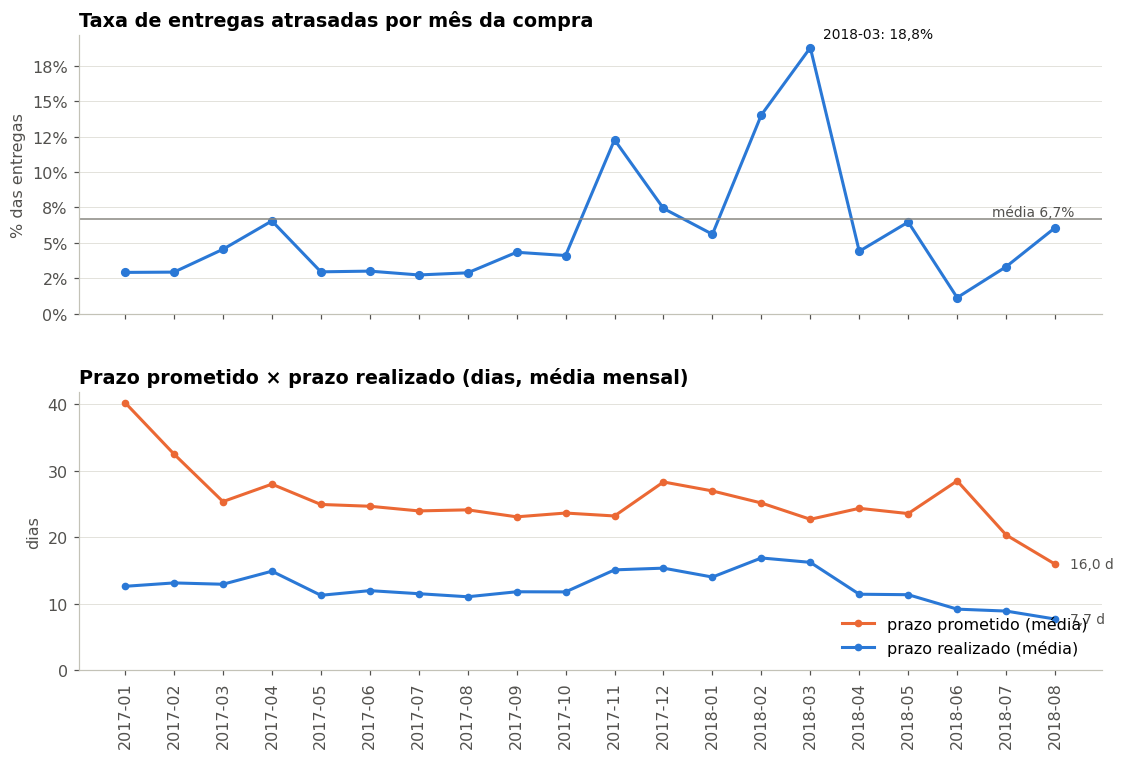

In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True, gridspec_kw={"hspace": 0.28})
taxa_geral = 100 * p1["atrasadas"].sum() / p1["entregas"].sum()
x = np.arange(len(p1))

ax1.plot(x, p1["taxa_atraso_pct"], color=AZUL, lw=2, marker="o", ms=5)
ax1.axhline(taxa_geral, color=CINZA, lw=1)
ax1.text(x[-1] + 0.4, taxa_geral, f"média {pct(taxa_geral)}", color=TINTA_2, va="bottom", ha="right", fontsize=9)
pico = int(p1["taxa_atraso_pct"].values.argmax())
ax1.annotate(f"{p1['ano_mes'].iloc[pico]}: {pct(p1['taxa_atraso_pct'].iloc[pico])}", (pico, p1["taxa_atraso_pct"].iloc[pico]),
             xytext=(8, 6), textcoords="offset points", fontsize=9, color=TINTA)
ax1.set_title("Taxa de entregas atrasadas por mês da compra")
ax1.set_ylabel("% das entregas")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: pct(v, 0)))
ax1.set_ylim(0, None)

ax2.plot(x, p1["media_prazo_prometido"], color=LARANJA, lw=2, marker="o", ms=4, label="prazo prometido (média)")
ax2.plot(x, p1["media_dias_entrega"], color=AZUL, lw=2, marker="o", ms=4, label="prazo realizado (média)")
for serie in ("media_prazo_prometido", "media_dias_entrega"):
    ax2.text(x[-1] + 0.3, p1[serie].iloc[-1], f"{num(p1[serie].iloc[-1], 1)} d", color=TINTA_2, va="center", fontsize=9)
ax2.set_title("Prazo prometido × prazo realizado (dias, média mensal)")
ax2.set_ylabel("dias")
ax2.set_ylim(0, None)
ax2.legend(loc="lower right")
ax2.set_xticks(x, p1["ano_mes"], rotation=90)
for ax in (ax1, ax2):
    ax.grid(axis="x", visible=False)
salvar_figura(fig, "p1_taxa_atraso_mensal")
plt.show()

In [31]:
tot_ent, tot_atr = int(p1["entregas"].sum()), int(p1["atrasadas"].sum())
ic1_inf, ic1_sup = wilson(tot_atr, tot_ent)
p1["ano"], p1["mes"] = p1["ano_mes"].str[:4], p1["ano_mes"].str[5:7]
mesmos_meses = p1[p1["mes"] <= "08"].groupby("ano")[["entregas", "atrasadas"]].sum()
e17, a17 = mesmos_meses.loc["2017"]
e18, a18 = mesmos_meses.loc["2018"]
t17, t18 = 100 * a17 / e17, 100 * a18 / e18
_, p_anos, _, _ = stats.chi2_contingency([[a17, e17 - a17], [a18, e18 - a18]])
rho_vol, p_vol = stats.spearmanr(p1["entregas"].astype(float), p1["taxa_atraso_pct"].astype(float))
pior, melhor = p1.loc[p1["taxa_atraso_pct"].idxmax()], p1.loc[p1["taxa_atraso_pct"].idxmin()]
picos = p1[p1["taxa_atraso_pct"] > 1.5 * taxa_geral]
folga_media = np.average(p1["media_prazo_prometido"] - p1["media_dias_entrega"], weights=p1["entregas"])

texto = (f"Na janela analisada, **{num(tot_atr)} de {num(tot_ent)} remessas entregues chegaram depois da data prometida**: "
         f"taxa de **{pct(taxa_geral)}** (IC 95%: {pct(float(ic1_inf))} a {pct(float(ic1_sup))}). "
         f"A taxa mensal variou de {pct(melhor['taxa_atraso_pct'])} ({melhor['ano_mes']}) a **{pct(pior['taxa_atraso_pct'])} ({pior['ano_mes']})**. ")
texto += (f"Meses acima de 1,5× a média: **{', '.join(picos['ano_mes'])}**. " if len(picos)
          else "Nenhum mês ultrapassou 1,5× a média. ")
texto += (f"Nos mesmos meses (jan a ago), a taxa foi {pct(t17)} em 2017 e {pct(t18)} em 2018 "
          f"({'diferença significativa' if p_anos < 0.05 else 'diferença não significativa'}, qui-quadrado {fp(p_anos)}). "
          f"A correlação entre volume mensal e taxa de atraso é ρ = {num(rho_vol, 2)} ({fp(p_vol)})"
          f"{', ou seja, os meses de maior demanda tendem a atrasar mais' if (rho_vol > 0 and p_vol < 0.05) else ', sem evidência de que o volume sozinho explique os picos'}. "
          + (f"Em média, o prazo prometido supera o realizado em **{num(folga_media, 1)} dias**: a promessa é folgada **na média**, "
             f"e mesmo assim {pct(taxa_geral)} das remessas atrasam. O problema está na **variabilidade** do prazo, não no seu valor médio."
             if folga_media > 0 else
             f"Em média, o prazo realizado supera o prometido em **{num(-folga_media, 1)} dias**: a promessa é curta já na média."))
RESUMO["P1"] = texto
RES = {"P1": {"taxa_geral": taxa_geral, "pico": pior["ano_mes"], "taxa_pico": pior["taxa_atraso_pct"]}}
mostrar("**Leitura automática — P1.** " + texto)

**Leitura automática — P1.** Na janela analisada, **6.544 de 97.541 remessas entregues chegaram depois da data prometida**: taxa de **6,7%** (IC 95%: 6,6% a 6,9%). A taxa mensal variou de 1,1% (2018-06) a **18,8% (2018-03)**. Meses acima de 1,5× a média: **2017-11, 2018-02, 2018-03**. Nos mesmos meses (jan a ago), a taxa foi 3,5% em 2017 e 7,6% em 2018 (diferença significativa, qui-quadrado p < 0,001). A correlação entre volume mensal e taxa de atraso é ρ = 0,55 (p = 0,012), ou seja, os meses de maior demanda tendem a atrasar mais. Em média, o prazo prometido supera o realizado em **11,8 dias**: a promessa é folgada **na média**, e mesmo assim 6,7% das remessas atrasam. O problema está na **variabilidade** do prazo, não no seu valor médio.

**Discussão (P1).** A taxa média dimensiona o problema, e a série mensal mostra se ele é estável. Picos concentrados em poucos meses apontam para **choques de capacidade**: datas promocionais como a Black Friday, que sobrecarregam vendedores e transportadoras, ou eventos externos que travam a malha logística, como a greve dos caminhoneiros de maio de 2018. Choques assim não se resolvem com um prazo fixo. Se a promessa é folgada **na média** e mesmo assim o atraso é relevante (ver a leitura automática), o prazo está sendo definido sem considerar a **dispersão** do tempo de entrega. É a ponte para P2 e P3: se a dispersão depende do destino e da distância, a promessa deveria depender deles também. **Decisão apoiada:** reforçar capacidade e ampliar temporariamente o prazo prometido nos meses de pico previsíveis.

### P2 — Quais estados concentram os atrasos, e o prazo prometido está calibrado por estado?

**Método:** taxa de atraso por UF de destino, com IC 95%. Uma UF está **significativamente acima da média nacional** quando o limite inferior do seu intervalo supera a taxa nacional. Para a calibração, cada UF compara o prazo **mediano prometido** com o **percentil 90 do prazo realizado**. Uma promessa igual ao P90 deixaria cerca de 10% de atrasos em qualquer estado, o que torna o risco uniforme entre regiões.

In [32]:
SQL_P2 = """
SELECT
  d.uf,
  d.regiao,
  COUNT(*) AS entregas,
  COUNTIF(f.flag_atraso) AS atrasadas,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(f.flag_atraso), COUNT(*)), 2) AS taxa_atraso_pct,
  ROUND(AVG(f.dias_entrega), 2) AS media_dias_entrega,
  ROUND(AVG(f.dias_prazo_prometido), 2) AS media_prazo_prometido,
  ROUND(AVG(f.dias_prazo_prometido - f.dias_entrega), 2) AS folga_media_dias,
  APPROX_QUANTILES(f.dias_entrega, 100)[OFFSET(50)] AS p50_dias_entrega,
  APPROX_QUANTILES(f.dias_entrega, 100)[OFFSET(90)] AS p90_dias_entrega,
  APPROX_QUANTILES(f.dias_prazo_prometido, 100)[OFFSET(50)] AS p50_prazo_prometido
FROM {DW}.fato_entrega AS f
JOIN {DW}.dim_tempo AS t ON f.sk_data_compra = t.sk_data
JOIN {DW}.dim_localidade AS d ON f.sk_localidade_destino = d.sk_localidade
WHERE f.flag_entregue AND t.periodo_analise
GROUP BY d.uf, d.regiao
ORDER BY taxa_atraso_pct DESC
"""
p2 = consultar(SQL_P2, "p2_atraso_por_uf")
p2["ic_inf"], p2["ic_sup"] = wilson(p2["atrasadas"], p2["entregas"])
taxa_nacional = 100 * p2["atrasadas"].sum() / p2["entregas"].sum()
p2["acima_da_media"] = p2["ic_inf"] > taxa_nacional
p2["prazo_sugerido_p90"] = np.ceil(p2["p90_dias_entrega"].astype(float)).astype(int)
p2["ajuste_sugerido_dias"] = p2["prazo_sugerido_p90"] - p2["p50_prazo_prometido"].astype(float)
salvar_tabela(p2, "p2_atraso_por_uf")
display(p2.round(2))

,uf,regiao,entregas,atrasadas,taxa_atraso_pct,media_dias_entrega,media_prazo_prometido,folga_media_dias,p50_dias_entrega,p90_dias_entrega,p50_prazo_prometido,ic_inf,ic_sup,acima_da_media,prazo_sugerido_p90,ajuste_sugerido_dias
0,AL,Nordeste,398,85,21.36,24.49,33.13,8.64,22.29,40.42,32,17.61,25.65,True,41,9.0
1,MA,Nordeste,725,126,17.38,21.46,30.91,9.45,19.14,34.04,31,14.79,20.31,True,35,4.0
2,SE,Nordeste,335,51,15.22,21.39,31.21,9.82,17.90,35.45,30,11.77,19.46,True,36,6.0
3,PI,Nordeste,477,66,13.84,19.42,30.65,11.23,16.28,30.21,30,11.03,17.23,True,31,1.0
4,CE,Nordeste,1284,176,13.71,21.17,31.82,10.65,18.14,34.41,32,11.93,15.70,True,35,3.0
5,RR,Norte,40,5,12.50,29.91,46.12,16.22,25.01,53.19,45,5.46,26.11,False,54,9.0
6,BA,Nordeste,3291,396,12.03,19.28,30.07,10.80,16.85,31.73,30,10.97,13.19,True,32,2.0
7,RJ,Sudeste,12475,1500,12.02,15.23,26.93,11.70,12.00,28.97,25,11.46,12.61,True,29,4.0
8,PA,Norte,951,107,11.25,23.76,37.71,13.95,21.07,39.45,37,9.40,13.42,True,40,3.0
9,ES,Sudeste,2019,214,10.60,15.73,26.17,10.44,13.55,25.31,26,9.33,12.02,True,26,0.0


Figura salva em /content/drive/MyDrive/mvp_olist/evidencias/graficos/p2_atraso_e_calibracao_por_uf.png


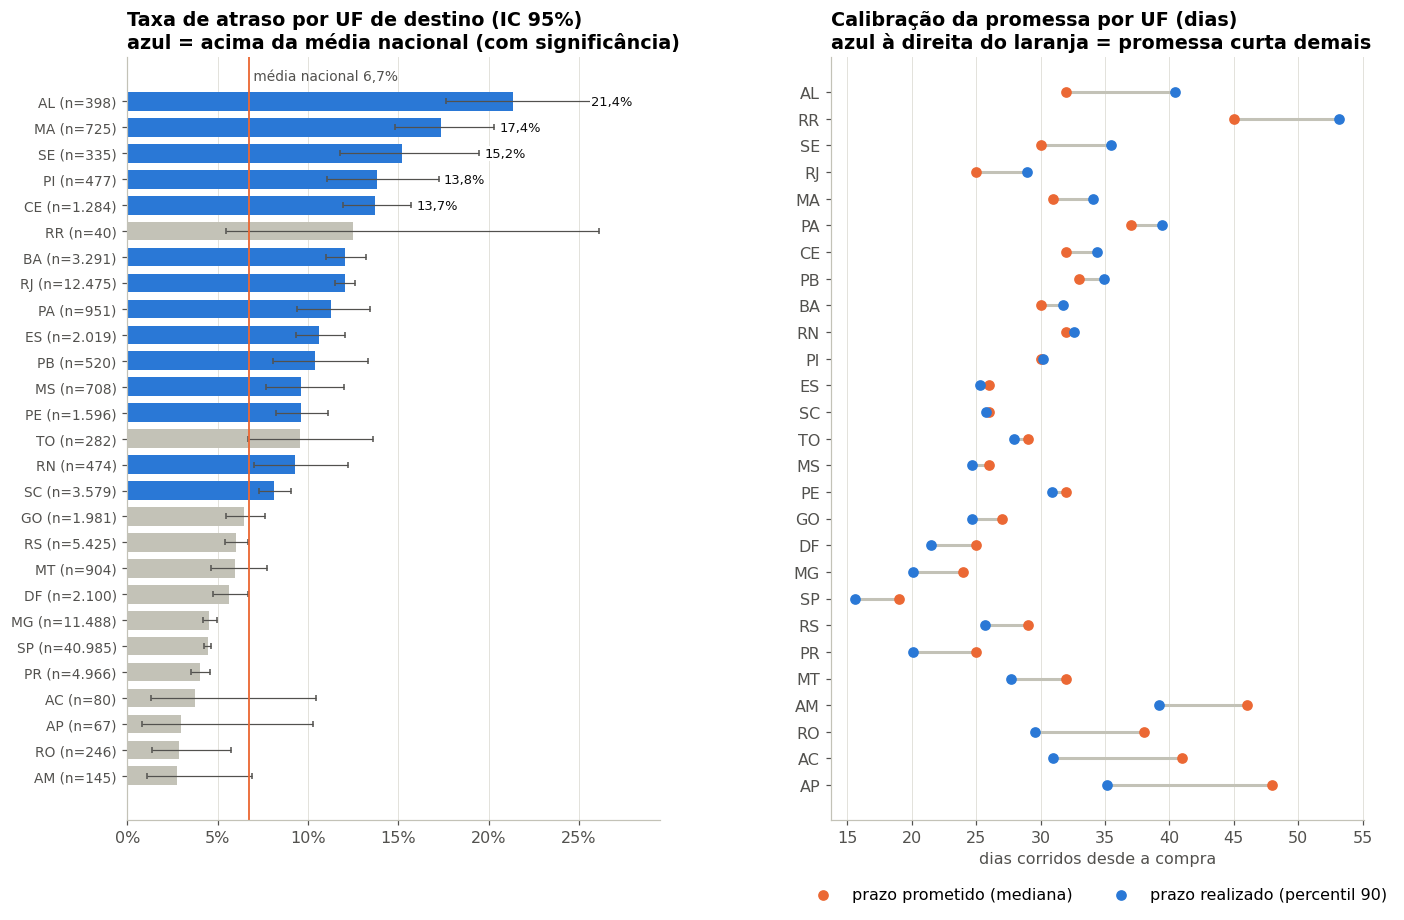

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 9), gridspec_kw={"wspace": 0.32})
ordem = p2.sort_values("taxa_atraso_pct").reset_index(drop=True)
y = np.arange(len(ordem))
cores = [AZUL if a else CINZA_CLARO for a in ordem["acima_da_media"]]
ax1.barh(y, ordem["taxa_atraso_pct"], color=cores, height=0.72)
ax1.errorbar(ordem["taxa_atraso_pct"], y,
             xerr=[ordem["taxa_atraso_pct"] - ordem["ic_inf"], ordem["ic_sup"] - ordem["taxa_atraso_pct"]],
             fmt="none", ecolor=TINTA_2, elinewidth=0.8, capsize=2)
ax1.axvline(taxa_nacional, color=LARANJA, lw=1.2)
ax1.text(taxa_nacional, len(ordem) - 0.3, f" média nacional {pct(taxa_nacional)}", color=TINTA_2, fontsize=9, va="bottom")
x_max = 1.15 * max(ordem.loc[ordem["entregas"] >= 100, "ic_sup"].max(), ordem["taxa_atraso_pct"].max())
ax1.set_xlim(0, x_max)
for i in range(max(0, len(ordem) - 5), len(ordem)):
    x_rot = min(ordem["ic_sup"].iloc[i], 0.86 * x_max) + 0.3
    ax1.text(x_rot, i, pct(ordem["taxa_atraso_pct"].iloc[i]), va="center", fontsize=8.5, color=TINTA,
             bbox=dict(facecolor="white", edgecolor="none", pad=0.5))
ax1.set_yticks(y, [f"{u} (n={num(n)})" for u, n in zip(ordem["uf"], ordem["entregas"])], fontsize=9)
ax1.set_title("Taxa de atraso por UF de destino (IC 95%)\nazul = acima da média nacional (com significância)")
ax1.xaxis.set_major_locator(mtick.MaxNLocator(nbins=7, integer=True))
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: pct(v, 0)))
ax1.grid(axis="y", visible=False)

cal = p2.sort_values("ajuste_sugerido_dias").reset_index(drop=True)
yc = np.arange(len(cal))
ax2.hlines(yc, cal["p50_prazo_prometido"].astype(float), cal["p90_dias_entrega"].astype(float), color=CINZA_CLARO, lw=2)
ax2.scatter(cal["p50_prazo_prometido"].astype(float), yc, color=LARANJA, s=36, zorder=3, label="prazo prometido (mediana)")
ax2.scatter(cal["p90_dias_entrega"].astype(float), yc, color=AZUL, s=36, zorder=3, label="prazo realizado (percentil 90)")
ax2.set_yticks(yc, cal["uf"])
ax2.set_title("Calibração da promessa por UF (dias)\nazul à direita do laranja = promessa curta demais")
ax2.set_xlabel("dias corridos desde a compra")
ax2.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=2)
ax2.grid(axis="y", visible=False)
salvar_figura(fig, "p2_atraso_e_calibracao_por_uf")
plt.show()

In [34]:
relevantes = p2[p2["entregas"] >= 300]
uf_max = relevantes.loc[relevantes["taxa_atraso_pct"].idxmax()]
uf_min = relevantes.loc[relevantes["taxa_atraso_pct"].idxmin()]
razao_uf = uf_max["taxa_atraso_pct"] / max(uf_min["taxa_atraso_pct"], 1e-9)
acima = p2[p2["acima_da_media"]].sort_values("taxa_atraso_pct", ascending=False)
rho_folga, p_folga = stats.spearmanr(p2["folga_media_dias"], p2["taxa_atraso_pct"])
curtas = p2[p2["ajuste_sugerido_dias"] > 0].sort_values("ajuste_sugerido_dias", ascending=False)
longas = p2[p2["ajuste_sugerido_dias"] < 0].sort_values("ajuste_sugerido_dias")
por_regiao = p2.groupby("regiao")[["entregas", "atrasadas"]].sum()
por_regiao["taxa"] = 100 * por_regiao["atrasadas"] / por_regiao["entregas"]

texto = (f"A taxa nacional é {pct(taxa_nacional)}. "
         + (f"**{len(acima)} UF(s) estão significativamente acima da média**: "
            f"{', '.join(f'{r.uf} ({pct(r.taxa_atraso_pct)})' for r in acima.itertuples())}. " if len(acima)
            else "Nenhuma UF está significativamente acima da média nacional. ")
         + f"Entre as UFs com pelo menos 300 entregas, a mais afetada ({uf_max['uf']}, {pct(uf_max['taxa_atraso_pct'])}) "
         f"tem **{num(razao_uf, 1)} vezes** a taxa da menos afetada ({uf_min['uf']}, {pct(uf_min['taxa_atraso_pct'])}). "
         f"Por região: " + ", ".join(f"{reg} {pct(r.taxa)}" for reg, r in por_regiao.sort_values("taxa", ascending=False).iterrows()) + ". "
         f"A correlação entre a folga média da promessa e a taxa de atraso é ρ = {num(rho_folga, 2)} ({fp(p_folga)}). "
         f"**Calibração:** em {len(curtas)} UFs o prazo mediano prometido é **menor** que o P90 do prazo realizado"
         + (f" (maiores déficits: {', '.join(f'{r.uf} +{num(r.ajuste_sugerido_dias, 0)} d' for r in curtas.head(5).itertuples())})" if len(curtas) else "")
         + f"; em {len(longas)} UFs a promessa já é **maior** que o P90"
         + (f" (maiores folgas: {', '.join(f'{r.uf} {num(r.ajuste_sugerido_dias, 0)} d' for r in longas.head(5).itertuples())})" if len(longas) else "")
         + ", o que abre espaço para prometer prazos menores sem aumentar o risco.")
RESUMO["P2"] = texto
RES["P2"] = {"razao_uf": razao_uf, "uf_max": uf_max["uf"], "uf_min": uf_min["uf"],
             "taxa_max": uf_max["taxa_atraso_pct"], "taxa_min": uf_min["taxa_atraso_pct"],
             "n_acima": len(acima), "n_curtas": len(curtas), "n_longas": len(longas)}
mostrar("**Leitura automática — P2.** " + texto)

**Leitura automática — P2.** A taxa nacional é 6,7%. **14 UF(s) estão significativamente acima da média**: AL (21,4%), MA (17,4%), SE (15,2%), PI (13,8%), CE (13,7%), BA (12,0%), RJ (12,0%), PA (11,2%), ES (10,6%), PB (10,4%), MS (9,6%), PE (9,6%), RN (9,3%), SC (8,1%). Entre as UFs com pelo menos 300 entregas, a mais afetada (AL, 21,4%) tem **5,3 vezes** a taxa da menos afetada (PR, 4,0%). Por região: Nordeste 12,6%, Norte 8,6%, Centro-Oeste 6,5%, Sudeste 6,1%, Sul 5,8%. A correlação entre a folga média da promessa e a taxa de atraso é ρ = -0,70 (p < 0,001). **Calibração:** em 11 UFs o prazo mediano prometido é **menor** que o P90 do prazo realizado (maiores déficits: AL +9 d, RR +9 d, SE +6 d, MA +4 d, RJ +4 d); em 14 UFs a promessa já é **maior** que o P90 (maiores folgas: AP -12 d, AC -10 d, RO -8 d, AM -6 d, MT -4 d), o que abre espaço para prometer prazos menores sem aumentar o risco.

**Discussão (P2).** Se a promessa estivesse bem calibrada, o risco de atraso seria parecido em todos os estados, porque um prazo maior compensaria um destino mais difícil. A dispersão entre UFs e o gráfico de calibração mostram se isso acontece. Os estados à esquerda do gráfico de calibração (P90 realizado acima da promessa) recebem uma **promessa curta demais para a realidade logística**, e a solução mais barata para eles é **alongar a promessa**, não acelerar a entrega. Nos estados em que a promessa já supera o P90, a plataforma **perde competitividade à toa**: poderia prometer menos sem aumentar o atraso. **Decisão apoiada:** substituir a promessa atual por uma regra explícita (por exemplo, o P90 do tempo realizado por UF, recalculado mensalmente), o que uniformiza o risco entre regiões.

### P3 — A distância aumenta o risco de atraso, mesmo controlando outros fatores?

**Método:** taxa de atraso por faixa de distância vendedor → cliente (linha reta entre centroides dos CEPs). Como a distância está correlacionada com a região de destino, uma **regressão logística** estima o efeito da distância **controlando** região de destino, peso da remessa, postagem fora do prazo e mês da compra. O resultado é expresso como **razão de chances** (*odds ratio*, OR): OR > 1 significa maior chance de atraso.

In [37]:
SQL_P3 = """
WITH base AS (
  SELECT
    f.flag_atraso,
    f.dias_entrega,
    f.valor_frete,
    o.uf AS uf_origem,
    d.uf AS uf_destino,
    CASE
      WHEN f.distancia_km < 100 THEN '1. até 100 km'
      WHEN f.distancia_km < 500 THEN '2. 100 a 500 km'
      WHEN f.distancia_km < 1000 THEN '3. 500 a 1.000 km'
      WHEN f.distancia_km < 2000 THEN '4. 1.000 a 2.000 km'
      ELSE '5. 2.000 km ou mais'
    END AS faixa_distancia
  FROM {DW}.fato_entrega AS f
  JOIN {DW}.dim_tempo AS t ON f.sk_data_compra = t.sk_data
  JOIN {DW}.dim_localidade AS o ON f.sk_localidade_origem = o.sk_localidade
  JOIN {DW}.dim_localidade AS d ON f.sk_localidade_destino = d.sk_localidade
  WHERE f.flag_entregue AND t.periodo_analise AND f.distancia_km IS NOT NULL
)
SELECT
  faixa_distancia,
  COUNT(*) AS entregas,
  COUNTIF(flag_atraso) AS atrasadas,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(flag_atraso), COUNT(*)), 2) AS taxa_atraso_pct,
  ROUND(AVG(dias_entrega), 2) AS media_dias_entrega,
  ROUND(AVG(valor_frete), 2) AS frete_medio,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(uf_origem = uf_destino), COUNT(*)), 1) AS pct_mesma_uf
FROM base
GROUP BY faixa_distancia
ORDER BY faixa_distancia
"""
p3 = consultar(SQL_P3, "p3_atraso_por_distancia")
p3["ic_inf"], p3["ic_sup"] = wilson(p3["atrasadas"], p3["entregas"])
salvar_tabela(p3, "p3_atraso_por_distancia")
display(p3.round(2))

SQL_P3_MODELO = """
SELECT
  CAST(f.flag_atraso AS INT64) AS atraso,
  f.distancia_km,
  f.peso_total_kg,
  CAST(f.flag_postagem_fora_prazo AS INT64) AS postagem_fora_prazo,
  d.regiao AS regiao_destino,
  t.ano_mes
FROM {DW}.fato_entrega AS f
JOIN {DW}.dim_tempo AS t ON f.sk_data_compra = t.sk_data
JOIN {DW}.dim_localidade AS d ON f.sk_localidade_destino = d.sk_localidade
WHERE f.flag_entregue AND t.periodo_analise
  AND f.distancia_km IS NOT NULL AND f.peso_total_kg IS NOT NULL AND f.flag_postagem_fora_prazo IS NOT NULL
"""
base_modelo = consultar(SQL_P3_MODELO, "p3_base_regressao")
for c in ("atraso", "postagem_fora_prazo"):
    base_modelo[c] = base_modelo[c].astype(int)
for c in ("distancia_km", "peso_total_kg"):
    base_modelo[c] = base_modelo[c].astype(float)
base_modelo["regiao_destino"] = base_modelo["regiao_destino"].astype(str)
base_modelo["ano_mes"] = base_modelo["ano_mes"].astype(str)

modelo_bruto = smf.logit("atraso ~ I(distancia_km / 500)", data=base_modelo).fit(disp=0)
modelo = smf.logit("atraso ~ I(distancia_km / 500) + np.log1p(peso_total_kg) + postagem_fora_prazo"
                   " + C(regiao_destino, Treatment('Sudeste')) + C(ano_mes)", data=base_modelo).fit(disp=0)

def tabela_or(m):
    ic = np.exp(m.conf_int())
    return pd.DataFrame({"termo": m.params.index, "odds_ratio": np.exp(m.params.values),
                         "ic95_inf": ic.iloc[:, 0].values, "ic95_sup": ic.iloc[:, 1].values, "p_valor": m.pvalues.values})

ors = tabela_or(modelo)
ors = ors[~ors["termo"].str.startswith("C(ano_mes") & (ors["termo"] != "Intercept")].reset_index(drop=True)
ors["termo"] = (ors["termo"].str.replace(r"C\(regiao_destino, Treatment\('Sudeste'\)\)\[T\.(.+)\]", r"destino \1 (vs. Sudeste)", regex=True)
                            .str.replace("I(distancia_km / 500)", "distância (+500 km)", regex=False)
                            .str.replace("np.log1p(peso_total_kg)", "peso (log de 1 + kg)", regex=False)
                            .str.replace("postagem_fora_prazo", "postagem fora do prazo", regex=False))
or_bruto = tabela_or(modelo_bruto).iloc[1]
salvar_tabela(ors, "p3_razoes_de_chance")
mostrar(f"Regressão logística com {num(modelo.nobs)} remessas · pseudo-R² (McFadden) = {modelo.prsquared:.3f} · "
        "controles incluem efeitos fixos de mês (não exibidos).")
display(ors.round(3))

,faixa_distancia,entregas,atrasadas,taxa_atraso_pct,media_dias_entrega,frete_medio,pct_mesma_uf,ic_inf,ic_sup
0,1. até 100 km,18040,796,4.41,6.46,13.29,99.5,4.12,4.72
1,2. 100 a 500 km,37452,2266,6.05,11.44,20.72,43.1,5.81,6.30
2,3. 500 a 1.000 km,26081,1836,7.04,14.24,23.80,3.1,6.74,7.36
3,4. 1.000 a 2.000 km,9843,924,9.39,17.88,32.63,0.0,8.83,9.98
4,5. 2.000 km ou mais,5638,677,12.01,21.11,39.55,0.0,11.19,12.88


Regressão logística com 97.031 remessas · pseudo-R² (McFadden) = 0.124 · controles incluem efeitos fixos de mês (não exibidos).

,termo,odds_ratio,ic95_inf,ic95_sup,p_valor
0,destino Centro-Oeste (vs. Sudeste),0.939,0.832,1.060,0.311
1,destino Nordeste (vs. Sudeste),1.556,1.376,1.760,0.000
2,destino Norte (vs. Sudeste),0.898,0.723,1.116,0.332
3,destino Sul (vs. Sudeste),0.881,0.810,0.958,0.003
4,distância (+500 km),1.179,1.140,1.220,0.000
5,peso (log de 1 + kg),1.082,1.046,1.119,0.000
6,postagem fora do prazo,4.837,4.541,5.153,0.000


Figura salva em /content/drive/MyDrive/mvp_olist/evidencias/graficos/p3_distancia_e_regressao.png


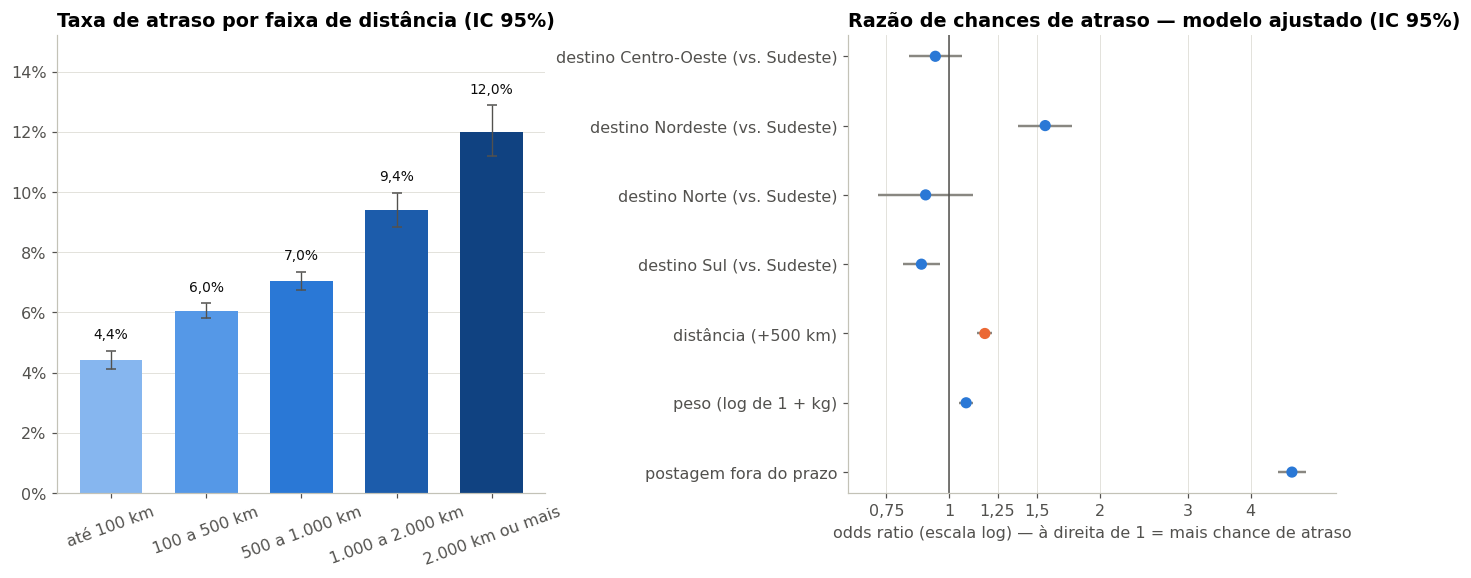

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.4), gridspec_kw={"wspace": 0.62, "width_ratios": [1, 1]})
x = np.arange(len(p3))
ax1.bar(x, p3["taxa_atraso_pct"], color=AZUIS[:len(p3)], width=0.66)
ax1.errorbar(x, p3["taxa_atraso_pct"],
             yerr=[p3["taxa_atraso_pct"] - p3["ic_inf"], p3["ic_sup"] - p3["taxa_atraso_pct"]],
             fmt="none", ecolor=TINTA_2, elinewidth=0.9, capsize=3)
for i, r in enumerate(p3.itertuples()):
    ax1.text(i, r.ic_sup + 0.3, pct(r.taxa_atraso_pct), ha="center", va="bottom", fontsize=9, color=TINTA)
ax1.set_xticks(x, p3["faixa_distancia"].str[3:], rotation=20)
ax1.set_ylim(0, 1.18 * p3["ic_sup"].max())
ax1.set_title("Taxa de atraso por faixa de distância (IC 95%)")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: pct(v, 0)))
ax1.grid(axis="x", visible=False)

fo = ors.iloc[::-1].reset_index(drop=True)
yf = np.arange(len(fo))
ax2.hlines(yf, fo["ic95_inf"], fo["ic95_sup"], color=CINZA, lw=1.6)
ax2.scatter(fo["odds_ratio"], yf, color=[LARANJA if "distância" in t else AZUL for t in fo["termo"]], s=40, zorder=3)
ax2.axvline(1, color=TINTA_2, lw=1)
ax2.set_xscale("log")
lim_inf, lim_sup = min(fo["ic95_inf"].min(), 1) / 1.15, max(fo["ic95_sup"].max(), 1) * 1.15
ax2.set_xlim(lim_inf, lim_sup)
marcas = [m for m in (0.1, 0.2, 0.3, 0.5, 0.75, 1, 1.25, 1.5, 2, 3, 4, 6, 8, 12, 20) if lim_inf <= m <= lim_sup]
ax2.xaxis.set_major_locator(mtick.FixedLocator(marcas))
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: num(v, 2).rstrip("0").rstrip(",")))
ax2.xaxis.set_minor_locator(mtick.NullLocator())
ax2.set_yticks(yf, fo["termo"])
ax2.set_title("Razão de chances de atraso — modelo ajustado (IC 95%)")
ax2.set_xlabel("odds ratio (escala log) — à direita de 1 = mais chance de atraso")
ax2.grid(axis="y", visible=False)
salvar_figura(fig, "p3_distancia_e_regressao")
plt.show()

In [39]:
_, p_faixas, _, _ = stats.chi2_contingency(np.c_[p3["atrasadas"].astype(int), (p3["entregas"] - p3["atrasadas"]).astype(int)])
t_perto, t_longe = p3["taxa_atraso_pct"].iloc[0], p3["taxa_atraso_pct"].iloc[-1]
razao_dist = t_longe / max(t_perto, 1e-9)
dist = ors[ors["termo"] == "distância (+500 km)"].iloc[0]
post = ors[ors["termo"] == "postagem fora do prazo"].iloc[0]
regs = ors[ors["termo"].str.startswith("destino")]
reg_sig = regs[(regs["ic95_inf"] > 1) | (regs["ic95_sup"] < 1)]
efeito_ajustado = dist["ic95_inf"] > 1

texto = (f"A taxa de atraso vai de **{pct(t_perto)}** (até 100 km) a **{pct(t_longe)}** (2.000 km ou mais): "
         f"**{num(razao_dist, 2)} vezes** (qui-quadrado entre faixas {fp(p_faixas)}). "
         f"Na regressão só com a distância, cada +500 km multiplica a chance de atraso por {num(or_bruto['odds_ratio'], 2)} "
         f"(IC 95%: {num(or_bruto['ic95_inf'], 2)} a {num(or_bruto['ic95_sup'], 2)}). "
         f"**Controlando região de destino, peso, postagem e mês, o OR da distância passa a {num(dist['odds_ratio'], 2)} "
         f"(IC 95%: {num(dist['ic95_inf'], 2)} a {num(dist['ic95_sup'], 2)}).** ")
if efeito_ajustado:
    texto += "A distância continua sendo fator de risco mesmo depois dos controles. "
elif dist["ic95_sup"] < 1:
    texto += ("Depois dos controles, a distância deixa de aumentar o risco: o efeito bruto era, em boa parte, efeito do **destino** "
              "(quem está longe está, sobretudo, em regiões de malha logística pior). ")
else:
    texto += ("Depois dos controles, o efeito da distância deixa de ser estatisticamente distinguível de zero: "
              "o efeito bruto era, em boa parte, efeito do **destino**. ")
if len(reg_sig):
    texto += ("Regiões de destino com risco diferente do Sudeste, mantida a distância: "
              + ", ".join(f"{t.replace('destino ', '').replace(' (vs. Sudeste)', '')} (OR {num(o, 2)})"
                          for t, o in zip(reg_sig["termo"], reg_sig["odds_ratio"])) + ". ")
texto += (f"Entre os controles, a postagem fora do prazo tem OR = {num(post['odds_ratio'], 2)} (IC 95%: {num(post['ic95_inf'], 2)} a "
          f"{num(post['ic95_sup'], 2)}), um efeito detalhado em P4.")
RESUMO["P3"] = texto
RES["P3"] = {"razao_dist": razao_dist, "or_dist": dist["odds_ratio"], "or_dist_inf": dist["ic95_inf"],
             "or_dist_sup": dist["ic95_sup"], "or_bruto": or_bruto["odds_ratio"], "or_post": post["odds_ratio"]}
mostrar("**Leitura automática — P3.** " + texto)

**Leitura automática — P3.** A taxa de atraso vai de **4,4%** (até 100 km) a **12,0%** (2.000 km ou mais): **2,72 vezes** (qui-quadrado entre faixas p < 0,001). Na regressão só com a distância, cada +500 km multiplica a chance de atraso por 1,24 (IC 95%: 1,22 a 1,26). **Controlando região de destino, peso, postagem e mês, o OR da distância passa a 1,18 (IC 95%: 1,14 a 1,22).** A distância continua sendo fator de risco mesmo depois dos controles. Regiões de destino com risco diferente do Sudeste, mantida a distância: Nordeste (OR 1,56), Sul (OR 0,88). Entre os controles, a postagem fora do prazo tem OR = 4,84 (IC 95%: 4,54 a 5,15), um efeito detalhado em P4.

**Discussão (P3).** A comparação entre a razão de chances **bruta** e a **ajustada** é o ponto central. Se o efeito da distância encolhe ao incluir a região de destino, parte do que parecia "distância" é, na verdade, **qualidade da malha no destino**: a mesma distância percorrida até o interior do Nordeste e até o interior de São Paulo não tem o mesmo risco. Se o efeito se mantém, cada quilômetro adicional pesa por si, e rotas longas pedem transportadoras ou modais diferentes. Há duas limitações. A distância é em **linha reta** entre centroides de CEP, o que subestima a distância rodoviária real. E o pseudo-R² baixo, esperado em eventos raros como o atraso, indica que muito da variação não está na base (transportadora, clima, rota). **Decisão apoiada:** priorizar a negociação com transportadoras nas rotas de longa distância para as regiões com OR significativo, e usar a distância como variável da promessa de prazo.

### P4 — Em que etapa o atraso nasce, e quão concentrado ele está em poucos vendedores?

**Método:** decomposição do prazo total em três etapas: **aprovação** (compra → pagamento aprovado), **preparação** (aprovação → postagem, responsabilidade do vendedor) e **transporte** (postagem → entrega, responsabilidade da transportadora). As etapas são comparadas entre remessas atrasadas e no prazo. Depois vêm a taxa de atraso segundo o vendedor ter ou não cumprido o prazo-limite de postagem (qui-quadrado) e a **curva de concentração** (Pareto) dos atrasos por vendedor.

In [40]:
SQL_P4_ETAPAS = """
SELECT
  CASE WHEN f.flag_atraso THEN 'Atrasadas' ELSE 'No prazo' END AS grupo,
  COUNT(*) AS entregas,
  ROUND(AVG(f.dias_aprovacao), 2) AS media_aprovacao,
  ROUND(AVG(f.dias_preparacao), 2) AS media_preparacao,
  ROUND(AVG(f.dias_transporte), 2) AS media_transporte,
  ROUND(APPROX_QUANTILES(f.dias_preparacao, 100)[OFFSET(50)], 2) AS mediana_preparacao,
  ROUND(APPROX_QUANTILES(f.dias_transporte, 100)[OFFSET(50)], 2) AS mediana_transporte,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(f.flag_postagem_fora_prazo), COUNTIF(f.flag_postagem_fora_prazo IS NOT NULL)), 2) AS pct_postagem_fora_prazo
FROM {DW}.fato_entrega AS f
JOIN {DW}.dim_tempo AS t ON f.sk_data_compra = t.sk_data
WHERE f.flag_entregue AND t.periodo_analise
GROUP BY grupo
ORDER BY grupo DESC
"""
SQL_P4_POSTAGEM = """
SELECT
  f.flag_postagem_fora_prazo AS postagem_fora_prazo,
  COUNT(*) AS entregas,
  COUNTIF(f.flag_atraso) AS atrasadas,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(f.flag_atraso), COUNT(*)), 2) AS taxa_atraso_pct
FROM {DW}.fato_entrega AS f
JOIN {DW}.dim_tempo AS t ON f.sk_data_compra = t.sk_data
WHERE f.flag_entregue AND t.periodo_analise AND f.flag_postagem_fora_prazo IS NOT NULL
GROUP BY postagem_fora_prazo
ORDER BY postagem_fora_prazo
"""
SQL_P4_VENDEDORES = """
SELECT
  v.id_vendedor,
  v.porte_vendedor,
  COUNT(*) AS entregas,
  COUNTIF(f.flag_atraso) AS atrasadas,
  COUNTIF(f.flag_postagem_fora_prazo) AS postagens_fora_prazo
FROM {DW}.fato_entrega AS f
JOIN {DW}.dim_tempo AS t ON f.sk_data_compra = t.sk_data
JOIN {DW}.dim_vendedor AS v ON f.sk_vendedor = v.sk_vendedor
WHERE f.flag_entregue AND t.periodo_analise
GROUP BY v.id_vendedor, v.porte_vendedor
"""
p4_etapas = consultar(SQL_P4_ETAPAS, "p4_etapas_por_grupo")
p4_post = consultar(SQL_P4_POSTAGEM, "p4_atraso_por_postagem")
p4_post["postagem_fora_prazo"] = p4_post["postagem_fora_prazo"].astype(bool)
p4_post["ic_inf"], p4_post["ic_sup"] = wilson(p4_post["atrasadas"], p4_post["entregas"])
p4_vend = consultar(SQL_P4_VENDEDORES, "p4_atraso_por_vendedor")
for nome, df in (("p4_etapas_por_grupo", p4_etapas), ("p4_atraso_por_postagem", p4_post)):
    salvar_tabela(df, nome)
display(p4_etapas)
display(p4_post.round(2))

# Curva de concentração: vendedores ordenados pelo número de entregas atrasadas
cv = p4_vend.sort_values(["atrasadas", "entregas"], ascending=False).reset_index(drop=True)
cv["pct_vendedores"] = 100 * (np.arange(len(cv)) + 1) / len(cv)
cv["pct_atrasos_acum"] = 100 * cv["atrasadas"].cumsum() / cv["atrasadas"].sum()
cv["pct_volume_acum"] = 100 * cv["entregas"].cumsum() / cv["entregas"].sum()
porte = p4_vend.groupby("porte_vendedor")[["entregas", "atrasadas", "postagens_fora_prazo"]].sum()
porte["taxa_atraso_pct"] = 100 * porte["atrasadas"] / porte["entregas"]
porte["pct_postagem_fora_prazo"] = 100 * porte["postagens_fora_prazo"] / porte["entregas"]
porte = porte.reindex([p for p in ["pequeno", "médio", "grande"] if p in porte.index])
salvar_tabela(porte.reset_index(), "p4_atraso_por_porte")
display(porte.round(2))

,grupo,entregas,media_aprovacao,media_preparacao,media_transporte,mediana_preparacao,mediana_transporte,pct_postagem_fora_prazo
0,No prazo,90997,0.42,2.61,7.97,1.78,6.94,7.51
1,Atrasadas,6544,0.51,5.55,27.89,3.06,26.20,27.71


,postagem_fora_prazo,entregas,atrasadas,taxa_atraso_pct,ic_inf,ic_sup
0,False,88897,4730,5.32,5.18,5.47
1,True,8643,1813,20.98,20.13,21.85


,entregas,atrasadas,postagens_fora_prazo,taxa_atraso_pct,pct_postagem_fora_prazo
porte_vendedor,,,,,
pequeno,5627,375,604,6.66,10.73
médio,33070,2184,3164,6.60,9.57
grande,58844,3985,4875,6.77,8.28


Figura salva em /content/drive/MyDrive/mvp_olist/evidencias/graficos/p4_etapas_e_concentracao.png


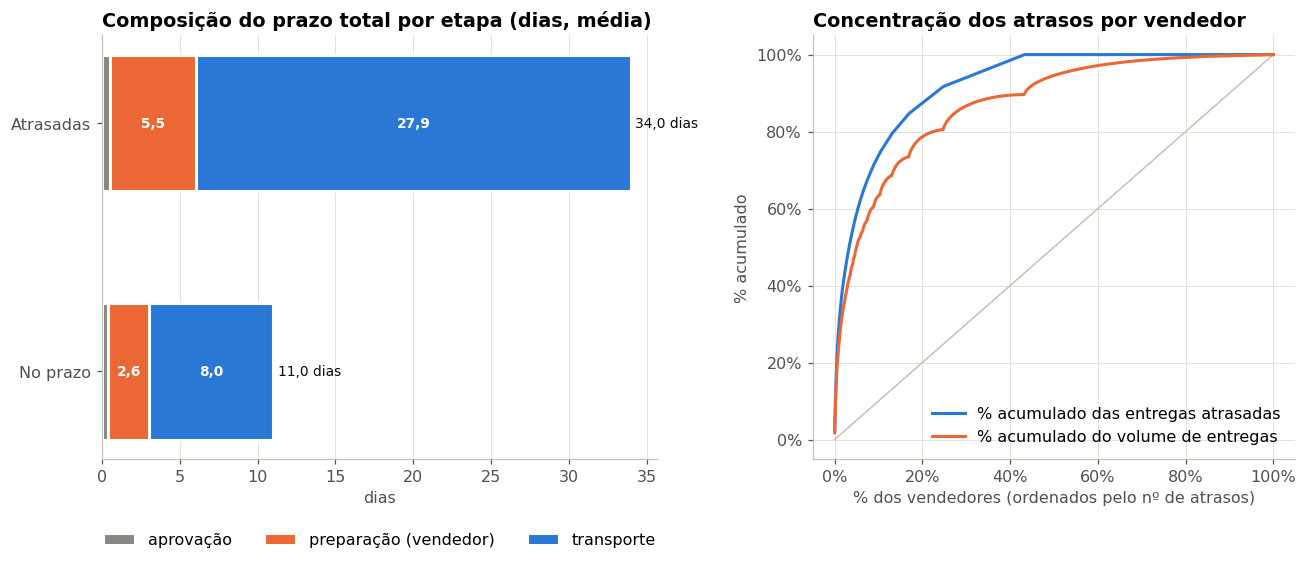

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"wspace": 0.3, "width_ratios": [1.15, 1]})
etapas_cols = [("media_aprovacao", "aprovação", CINZA), ("media_preparacao", "preparação (vendedor)", LARANJA),
               ("media_transporte", "transporte", AZUL)]
yg = np.arange(len(p4_etapas))
esquerda = np.zeros(len(p4_etapas))
for col, rotulo, cor in etapas_cols:
    valores = p4_etapas[col].astype(float).fillna(0).to_numpy()
    ax1.barh(yg, valores, left=esquerda, color=cor, height=0.55, label=rotulo, edgecolor="white", linewidth=2)
    for i, (v, e) in enumerate(zip(valores, esquerda)):
        if v >= 1.2:
            ax1.text(e + v / 2, i, num(v, 1), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    esquerda += valores
for i, total in enumerate(esquerda):
    ax1.text(total + 0.3, i, f"{num(total, 1)} dias", va="center", fontsize=9, color=TINTA)
ax1.set_yticks(yg, p4_etapas["grupo"])
ax1.set_title("Composição do prazo total por etapa (dias, média)")
ax1.set_xlabel("dias")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3)
ax1.grid(axis="y", visible=False)

ax2.plot([0, 100], [0, 100], color=CINZA_CLARO, lw=1)
ax2.plot(cv["pct_vendedores"], cv["pct_atrasos_acum"], color=AZUL, lw=2, label="% acumulado das entregas atrasadas")
ax2.plot(cv["pct_vendedores"], cv["pct_volume_acum"], color=LARANJA, lw=2, label="% acumulado do volume de entregas")
ax2.set_title("Concentração dos atrasos por vendedor")
ax2.set_xlabel("% dos vendedores (ordenados pelo nº de atrasos)")
ax2.set_ylabel("% acumulado")
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: pct(v, 0)))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: pct(v, 0)))
ax2.legend(loc="lower right")
salvar_figura(fig, "p4_etapas_e_concentracao")
plt.show()

In [42]:
fora = p4_post[p4_post["postagem_fora_prazo"]].iloc[0]
dentro_prazo = p4_post[~p4_post["postagem_fora_prazo"]].iloc[0]
_, p_post, _, _ = stats.chi2_contingency([[fora["atrasadas"], fora["entregas"] - fora["atrasadas"]],
                                          [dentro_prazo["atrasadas"], dentro_prazo["entregas"] - dentro_prazo["atrasadas"]]])
razao_post = fora["taxa_atraso_pct"] / max(dentro_prazo["taxa_atraso_pct"], 1e-9)
share_atrasos_vendedor = 100 * fora["atrasadas"] / (fora["atrasadas"] + dentro_prazo["atrasadas"])
share_postagens_fora = 100 * fora["entregas"] / (fora["entregas"] + dentro_prazo["entregas"])
at = p4_etapas.set_index("grupo")
dif_prep = float(at.loc["Atrasadas", "media_preparacao"] - at.loc["No prazo", "media_preparacao"])
dif_transp = float(at.loc["Atrasadas", "media_transporte"] - at.loc["No prazo", "media_transporte"])
dif_total = dif_prep + dif_transp + float(at.loc["Atrasadas", "media_aprovacao"] - at.loc["No prazo", "media_aprovacao"])
vend_50 = cv.loc[cv["pct_atrasos_acum"] >= 50].iloc[0]
vend_80 = cv.loc[cv["pct_atrasos_acum"] >= 80].iloc[0]
sem_atraso = 100 * (cv["atrasadas"] == 0).mean()

texto = (f"Remessas postadas **depois** do prazo-limite atrasam **{pct(fora['taxa_atraso_pct'])}** das vezes, contra "
         f"{pct(dentro_prazo['taxa_atraso_pct'])} das postadas no prazo: **{num(razao_post, 1)} vezes** mais (qui-quadrado {fp(p_post)}). "
         f"Elas são {pct(share_postagens_fora)} das remessas e respondem por **{pct(share_atrasos_vendedor)} dos atrasos**. "
         + ("Ou seja, a maior parte dos atrasos acontece **mesmo com o vendedor cumprindo o prazo de postagem**. "
            if share_atrasos_vendedor < 50 else "Ou seja, a maior parte dos atrasos **começa com a postagem fora do prazo**. ") +
         f"Na decomposição, as remessas atrasadas levam em média {num(dif_total, 1)} dias a mais que as no prazo: "
         f"{num(dif_prep, 1)} dias a mais na **preparação** e {num(dif_transp, 1)} dias a mais no **transporte** "
         f"({pct(100 * dif_transp / dif_total if dif_total else float('nan'), 0)} da diferença está no transporte). "
         f"**Concentração:** {pct(vend_50['pct_vendedores'])} dos vendedores concentram 50% das entregas atrasadas "
         f"(e {pct(vend_50['pct_volume_acum'])} do volume); {pct(vend_80['pct_vendedores'])} concentram 80% "
         f"(e {pct(vend_80['pct_volume_acum'])} do volume). {pct(sem_atraso)} dos vendedores não tiveram nenhum atraso. "
         f"Taxa de atraso por porte: " + ", ".join(f"{i} {pct(r.taxa_atraso_pct)}" for i, r in porte.iterrows()) + ".")
RESUMO["P4"] = texto
RES["P4"] = {"razao_post": razao_post, "p_post": p_post, "taxa_fora": fora["taxa_atraso_pct"],
             "taxa_dentro": dentro_prazo["taxa_atraso_pct"], "share_vendedor": share_atrasos_vendedor,
             "pct_transporte": 100 * dif_transp / dif_total if dif_total else np.nan}
mostrar("**Leitura automática — P4.** " + texto)

**Leitura automática — P4.** Remessas postadas **depois** do prazo-limite atrasam **21,0%** das vezes, contra 5,3% das postadas no prazo: **3,9 vezes** mais (qui-quadrado p < 0,001). Elas são 8,9% das remessas e respondem por **27,7% dos atrasos**. Ou seja, a maior parte dos atrasos acontece **mesmo com o vendedor cumprindo o prazo de postagem**. Na decomposição, as remessas atrasadas levam em média 23,0 dias a mais que as no prazo: 2,9 dias a mais na **preparação** e 19,9 dias a mais no **transporte** (87% da diferença está no transporte). **Concentração:** 3,3% dos vendedores concentram 50% das entregas atrasadas (e 41,9% do volume); 13,5% concentram 80% (e 70,0% do volume). 56,8% dos vendedores não tiveram nenhum atraso. Taxa de atraso por porte: pequeno 6,7%, médio 6,6%, grande 6,8%.

**Discussão (P4).** A pergunta tem duas leituras, e elas podem divergir. A **taxa** mostra quanto postar fora do prazo multiplica o risco de atraso. A **contribuição** mostra quanto do atraso total nasce em cada etapa. Uma falha pode multiplicar o risco e ainda assim responder por uma parcela pequena dos atrasos, se for rara. Por isso a decisão olha para as duas. A curva de concentração diz se o problema está em **poucos vendedores**: a curva de atrasos acima da curva de volume indica vendedores que atrasam **desproporcionalmente**, e não só vendedores grandes. **Decisões apoiadas:** (1) um SLA de postagem com alerta automático para os vendedores do topo da curva, uma ação barata e focada; (2) se o transporte concentra a maior parte dos dias extras, o ganho maior está na negociação com transportadoras e na promessa calibrada (P2), e não apenas na cobrança dos vendedores.

### P5 — Quanto o atraso custa em satisfação do cliente?

**Método:** análise **por pedido**, agregando as remessas: o pedido está atrasado se qualquer remessa atrasou, e vale o maior atraso. A nota média e a proporção de avaliações negativas (1 ou 2 estrelas) são calculadas por faixa de antecipação/atraso. A diferença entre pedidos atrasados e no prazo é testada com Mann-Whitney (notas são ordinais), e o intervalo de confiança da diferença de médias é estimado pelo teste de Welch.

In [43]:
SQL_P5_PEDIDOS = """
SELECT
  f.id_pedido,
  CAST(LOGICAL_OR(f.flag_atraso) AS INT64) AS atrasado,
  MAX(f.dias_atraso) AS dias_atraso,
  MAX(f.nota_avaliacao) AS nota
FROM {DW}.fato_entrega AS f
JOIN {DW}.dim_tempo AS t ON f.sk_data_compra = t.sk_data
WHERE f.flag_entregue AND t.periodo_analise AND f.nota_avaliacao IS NOT NULL
GROUP BY f.id_pedido
"""
SQL_P5_FAIXAS = """
WITH pedidos AS (
""" + SQL_P5_PEDIDOS.strip() + """
)
SELECT
  CASE
    WHEN dias_atraso <= -15 THEN '1. 15+ dias antes'
    WHEN dias_atraso <= -8 THEN '2. 8 a 14 dias antes'
    WHEN dias_atraso <= -1 THEN '3. 1 a 7 dias antes'
    WHEN dias_atraso = 0 THEN '4. no dia prometido'
    WHEN dias_atraso <= 7 THEN '5. 1 a 7 dias de atraso'
    WHEN dias_atraso <= 14 THEN '6. 8 a 14 dias de atraso'
    ELSE '7. 15+ dias de atraso'
  END AS faixa,
  COUNT(*) AS pedidos,
  ROUND(AVG(nota), 2) AS nota_media,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(nota <= 2), COUNT(*)), 2) AS pct_negativas,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(nota = 5), COUNT(*)), 2) AS pct_nota_5
FROM pedidos
GROUP BY faixa
ORDER BY faixa
"""
p5 = consultar(SQL_P5_FAIXAS, "p5_nota_por_faixa_de_atraso")
p5_ped = consultar(SQL_P5_PEDIDOS, "p5_base_pedidos")
p5_ped["atrasado"] = p5_ped["atrasado"].astype(int)
p5_ped["nota"] = p5_ped["nota"].astype(float)
salvar_tabela(p5, "p5_nota_por_faixa_de_atraso")
display(p5)

,faixa,pedidos,nota_media,pct_negativas,pct_nota_5
0,1. 15+ dias antes,34526,4.32,9.00,64.32
1,2. 8 a 14 dias antes,36147,4.31,8.90,63.03
2,3. 1 a 7 dias antes,17229,4.20,10.23,57.50
3,4. no dia prometido,1280,4.03,12.42,50.63
4,5. 1 a 7 dias de atraso,3599,2.71,49.40,23.90
5,6. 8 a 14 dias de atraso,1446,1.67,80.15,6.85
6,7. 15+ dias de atraso,1333,1.72,78.32,7.20


Figura salva em /content/drive/MyDrive/mvp_olist/evidencias/graficos/p5_nota_por_atraso.png


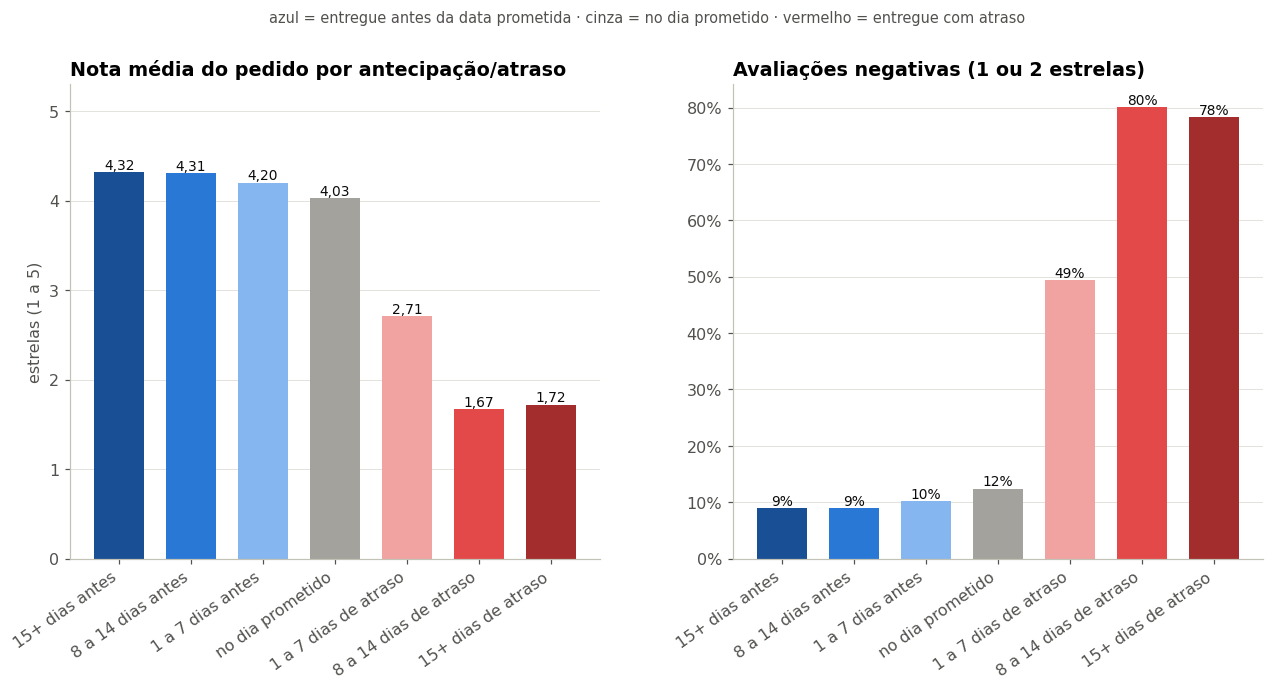

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"wspace": 0.25})
x = np.arange(len(p5))
mapa_cores = dict(zip(["1", "2", "3", "4", "5", "6", "7"], DIVERGENTE))
cores = [mapa_cores[f[0]] for f in p5["faixa"]]
for ax, col, titulo, fmt in ((ax1, "nota_media", "Nota média do pedido por antecipação/atraso", lambda v: num(v, 2)),
                             (ax2, "pct_negativas", "Avaliações negativas (1 ou 2 estrelas)", lambda v: pct(v, 0))):
    ax.bar(x, p5[col], color=cores, width=0.7)
    for i, v in enumerate(p5[col]):
        ax.text(i, v, fmt(v), ha="center", va="bottom", fontsize=9, color=TINTA)
    ax.set_xticks(x, p5["faixa"].str[3:], rotation=35, ha="right")
    ax.set_title(titulo)
    ax.grid(axis="x", visible=False)
ax1.set_ylim(0, 5.3)
ax1.set_ylabel("estrelas (1 a 5)")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: pct(v, 0)))
fig.suptitle("azul = entregue antes da data prometida · cinza = no dia prometido · vermelho = entregue com atraso",
             y=1.0, fontsize=9.5, color=TINTA_2)
salvar_figura(fig, "p5_nota_por_atraso")
plt.show()

In [45]:
nota_ok = p5_ped.loc[p5_ped["atrasado"] == 0, "nota"]
nota_atr = p5_ped.loc[p5_ped["atrasado"] == 1, "nota"]
dif_nota = nota_ok.mean() - nota_atr.mean()
welch = stats.ttest_ind(nota_ok, nota_atr, equal_var=False)
se = np.sqrt(nota_ok.var(ddof=1) / len(nota_ok) + nota_atr.var(ddof=1) / len(nota_atr))
gl = se**4 / ((nota_ok.var(ddof=1) / len(nota_ok))**2 / (len(nota_ok) - 1) + (nota_atr.var(ddof=1) / len(nota_atr))**2 / (len(nota_atr) - 1))
tcrit = stats.t.ppf(0.975, gl)
mw = stats.mannwhitneyu(nota_ok, nota_atr, alternative="two-sided")
neg_ok, neg_atr = 100 * (nota_ok <= 2).mean(), 100 * (nota_atr <= 2).mean()
pior_faixa = p5.iloc[-1]
antes_15 = p5.iloc[0]
negativas_total = int((p5_ped["nota"] <= 2).sum())
negativas_atraso = int(((p5_ped["nota"] <= 2) & (p5_ped["atrasado"] == 1)).sum())

texto = (f"Pedidos entregues no prazo têm nota média **{num(nota_ok.mean(), 2)}**; pedidos atrasados, **{num(nota_atr.mean(), 2)}**: "
         f"diferença de **{num(dif_nota, 2)} ponto(s)** (IC 95%: {num(dif_nota - tcrit * se, 2)} a {num(dif_nota + tcrit * se, 2)}; "
         f"Mann-Whitney {fp(mw.pvalue)}). A proporção de avaliações negativas sobe de {pct(neg_ok)} para **{pct(neg_atr)}** "
         f"({num(neg_atr / max(neg_ok, 1e-9), 1)} vezes). O efeito cresce com o tamanho do atraso: na faixa '{pior_faixa['faixa'][3:]}', "
         f"a nota média cai para {num(pior_faixa['nota_media'], 2)} e {pct(pior_faixa['pct_negativas'])} das avaliações são negativas, "
         f"enquanto na faixa '{antes_15['faixa'][3:]}' a nota é {num(antes_15['nota_media'], 2)}. "
         f"Os pedidos atrasados, {pct(100 * len(nota_atr) / len(p5_ped))} do total avaliado, geram "
         f"**{pct(100 * negativas_atraso / max(negativas_total, 1))} de todas as avaliações negativas**.")
RESUMO["P5"] = texto
RES["P5"] = {"dif_nota": dif_nota, "p_mw": mw.pvalue, "nota_ok": nota_ok.mean(), "nota_atr": nota_atr.mean(),
             "neg_ok": neg_ok, "neg_atr": neg_atr, "share_neg": 100 * negativas_atraso / max(negativas_total, 1)}
mostrar("**Leitura automática — P5.** " + texto)

**Leitura automática — P5.** Pedidos entregues no prazo têm nota média **4,29**; pedidos atrasados, **2,27**: diferença de **2,02 ponto(s)** (IC 95%: 1,98 a 2,06; Mann-Whitney p < 0,001). A proporção de avaliações negativas sobe de 9,2% para **62,4%** (6,7 vezes). O efeito cresce com o tamanho do atraso: na faixa '15+ dias de atraso', a nota média cai para 1,72 e 78,3% das avaliações são negativas, enquanto na faixa '15+ dias antes' a nota é 4,32. Os pedidos atrasados, 6,7% do total avaliado, geram **32,6% de todas as avaliações negativas**.

**Discussão (P5).** P5 transforma o atraso em custo mensurável para o negócio. A **forma** da relação importa para a decisão. Se antecipar a entrega melhora pouco a nota, enquanto cada faixa de atraso a derruba (relação assimétrica), prometer um pouco mais e cumprir custa menos satisfação do que prometer pouco e atrasar, o que reforça a promessa calibrada de P2. E se os pedidos atrasados, que são minoria, geram uma parcela desproporcional das avaliações negativas (ver a leitura automática), **reduzir atrasos é a alavanca mais eficiente para a reputação da plataforma**. Uma cautela: a análise é observacional. Pedidos atrasados podem ter outros problemas associados (produto errado, avaria), e isso infla parte da diferença. **Decisão apoiada:** usar a queda de nota e o aumento de avaliações negativas como métrica de benefício ao priorizar as ações de P2 a P4.

## 10. Discussão geral e avaliação das hipóteses

Os critérios definidos na Seção 1.4, antes da análise, são avaliados agora contra os resultados obtidos.

In [46]:
r2, r3, r4, r5 = RES["P2"], RES["P3"], RES["P4"], RES["P5"]
h3_bruto, h3_ajustado = r3["razao_dist"] >= 1.5, r3["or_dist_inf"] > 1
hipoteses = pd.DataFrame([
    {"hipotese": "H2 — a promessa não compensa as diferenças regionais",
     "criterio": "maior/menor taxa de atraso por UF (≥ 300 entregas) ≥ 3×",
     "resultado": f"{num(r2['razao_uf'], 1)}× ({r2['uf_max']} {pct(r2['taxa_max'])} × {r2['uf_min']} {pct(r2['taxa_min'])})",
     "veredito": "Confirmada" if r2["razao_uf"] >= 3 else "Não confirmada"},
    {"hipotese": "H3 — a distância aumenta o risco, mesmo com controles",
     "criterio": "taxa ≥ 2.000 km / taxa até 100 km ≥ 1,5× e OR ajustado (+500 km) com IC 95% > 1",
     "resultado": f"razão {num(r3['razao_dist'], 2)}×; OR ajustado {num(r3['or_dist'], 2)} "
                  f"(IC {num(r3['or_dist_inf'], 2)} a {num(r3['or_dist_sup'], 2)})",
     "veredito": "Confirmada" if (h3_bruto and h3_ajustado) else
                 ("Parcialmente (efeito bruto sim, ajustado não)" if h3_bruto else "Não confirmada")},
    {"hipotese": "H4 — parte relevante do atraso nasce no vendedor",
     "criterio": "taxa com postagem fora do prazo ≥ 2× taxa no prazo, p < 0,05",
     "resultado": f"{pct(r4['taxa_fora'])} × {pct(r4['taxa_dentro'])} = {num(r4['razao_post'], 1)}× ({fp(r4['p_post'])}); "
                  f"{pct(r4['share_vendedor'])} dos atrasos",
     "veredito": "Confirmada" if (r4["razao_post"] >= 2 and r4["p_post"] < 0.05) else "Não confirmada"},
    {"hipotese": "H5 — o atraso derruba a satisfação",
     "criterio": "nota média no prazo − nota média atrasado ≥ 1 ponto, p < 0,05",
     "resultado": f"{num(r5['nota_ok'], 2)} − {num(r5['nota_atr'], 2)} = {num(r5['dif_nota'], 2)} ({fp(r5['p_mw'])})",
     "veredito": "Confirmada" if (r5["dif_nota"] >= 1 and r5["p_mw"] < 0.05) else "Não confirmada"},
])
salvar_tabela(hipoteses, "d1_avaliacao_hipoteses")
display(hipoteses)

sintese = (f"**Síntese.** {pct(RES['P1']['taxa_geral'])} das remessas atrasam, com pico de {pct(RES['P1']['taxa_pico'])} em {RES['P1']['pico']}. "
           + (f"O risco não é uniforme entre destinos: {r2['uf_max']} atrasa {num(r2['razao_uf'], 1)} vezes mais que {r2['uf_min']}"
              if r2["razao_uf"] >= 2 else
              f"O risco é relativamente uniforme entre destinos (a taxa de {r2['uf_max']} é {num(r2['razao_uf'], 1)} vez a de {r2['uf_min']})")
           + f", e em {r2['n_curtas']} UFs a promessa mediana é menor que o P90 do prazo realizado. "
           f"A distância multiplica a chance de atraso por {num(r3['or_bruto'], 2)} a cada +500 km no modelo bruto e por "
           f"{num(r3['or_dist'], 2)} depois dos controles. Postar fora do prazo multiplica a taxa de atraso por {num(r4['razao_post'], 1)} "
           f"e responde por {pct(r4['share_vendedor'])} dos atrasos"
           + (f"; a maior parte dos atrasos nasce no transporte, que concentra {pct(r4['pct_transporte'], 0)} dos dias extras das remessas atrasadas. "
              if r4["share_vendedor"] < 50 else
              f"; a maior parte dos atrasos nasce, portanto, na etapa do vendedor. ")
           + (f"O custo em satisfação é alto: a nota cai {num(r5['dif_nota'], 2)} ponto(s)" if r5["dif_nota"] >= 0.5 else
              f"O custo em satisfação é moderado: a nota cai {num(r5['dif_nota'], 2)} ponto(s)")
           + f", e os pedidos atrasados geram {pct(r5['share_neg'])} das avaliações negativas.")
RESUMO["sintese"] = sintese
mostrar(sintese)

,hipotese,criterio,resultado,veredito
0,H2 — a promessa não compensa as diferenças regionais,maior/menor taxa de atraso por UF (≥ 300 entregas) ≥ 3×,"5,3× (AL 21,4% × PR 4,0%)",Confirmada
1,"H3 — a distância aumenta o risco, mesmo com controles","taxa ≥ 2.000 km / taxa até 100 km ≥ 1,5× e OR ajustado (+500 km) com IC 95% > 1","razão 2,72×; OR ajustado 1,18 (IC 1,14 a 1,22)",Confirmada
2,H4 — parte relevante do atraso nasce no vendedor,"taxa com postagem fora do prazo ≥ 2× taxa no prazo, p < 0,05","21,0% × 5,3% = 3,9× (p < 0,001); 27,7% dos atrasos",Confirmada
3,H5 — o atraso derruba a satisfação,"nota média no prazo − nota média atrasado ≥ 1 ponto, p < 0,05","4,29 − 2,27 = 2,02 (p < 0,001)",Confirmada


**Síntese.** 6,7% das remessas atrasam, com pico de 18,8% em 2018-03. O risco não é uniforme entre destinos: AL atrasa 5,3 vezes mais que PR, e em 11 UFs a promessa mediana é menor que o P90 do prazo realizado. A distância multiplica a chance de atraso por 1,24 a cada +500 km no modelo bruto e por 1,18 depois dos controles. Postar fora do prazo multiplica a taxa de atraso por 3,9 e responde por 27,7% dos atrasos; a maior parte dos atrasos nasce no transporte, que concentra 87% dos dias extras das remessas atrasadas. O custo em satisfação é alto: a nota cai 2,02 ponto(s), e os pedidos atrasados geram 32,6% das avaliações negativas.

**Como as respostas se encadeiam.** P1 dimensiona o problema e mostra como ele oscila no tempo. P2 e P3 mostram **onde** ele se concentra e se a promessa de prazo absorve essas diferenças. P4 mostra **em que etapa** o atraso nasce. P5 mostra **quanto** ele custa. Juntas, as respostas sustentam uma decisão priorizada. A priorização abaixo vale para o cenário em que as hipóteses se confirmam: a tabela acima indica quais se sustentaram, e uma hipótese não confirmada rebaixa a ação correspondente.

| Prioridade | Ação | Evidência | Custo de implantação |
|---|---|---|---|
| 1 | **Calibrar a promessa de prazo** por UF de destino e faixa de distância (por exemplo, P90 do prazo realizado, recalculado mensalmente). | P2, P3, P5 | Baixo: regra de negócio no *checkout*. |
| 2 | **Atacar o transporte nas rotas longas** para as regiões com maior razão de chances, renegociando SLA ou trocando de transportadora. | P3, P4 | Médio: negociação comercial. |
| 3 | **SLA de postagem focado** nos vendedores do topo da curva de concentração, com alerta automático. | P4 | Baixo: monitoramento sobre o próprio DW. |
| 4 | **Plano de capacidade para picos** previsíveis (datas promocionais), com promessa temporariamente estendida. | P1 | Baixo a médio. |

**O que os dados não permitem concluir.** As análises são **observacionais**: mostram associação, não causalidade. A base não identifica a transportadora, o modal nem a rota; a distância é em linha reta; e os dados cobrem 2016–2018, antes da expansão do e-commerce na pandemia. As conclusões valem como **hipóteses de ação** a validar com um experimento controlado, como um teste A/B da promessa calibrada em algumas UFs.

## 11. Viabilidade financeira — custo de operação

A dimensão financeira do MVP é medida, não suposta: o notebook registra os bytes processados por **cada** consulta e o armazenamento ocupado no BigQuery e no Drive.

In [47]:
consultas = pd.DataFrame(LOG_CONSULTAS)
salvar_tabela(consultas, "f1_consultas_bigquery")
bytes_consultas = int(consultas["bytes_processados"].sum())
armazenamento_bq = int(sum(client.get_table(f"{PROJECT_ID}.{DATASET_BQ}.{n}").num_bytes for n in log_carga["tabela"]))
tamanho_drive = sum(os.path.getsize(os.path.join(raiz, a)) for raiz, _, arqs in os.walk(PASTA_DRIVE) for a in arqs)
TIB, GIB, MB = 2**40, 2**30, 2**20
custos = pd.DataFrame([
    {"recurso": "BigQuery — consultas (uma execução completa)", "uso_medido": f"{num(bytes_consultas / MB, 1)} MB em {len(consultas)} consultas",
     "franquia_gratuita": "1 TiB por mês", "pct_da_franquia": 100 * bytes_consultas / TIB,
     "custo_usd_sem_franquia": bytes_consultas / TIB * PRECO_USD_POR_TIB},
    {"recurso": "BigQuery — armazenamento", "uso_medido": f"{num(armazenamento_bq / MB, 1)} MB",
     "franquia_gratuita": "10 GiB", "pct_da_franquia": 100 * armazenamento_bq / (10 * GIB),
     "custo_usd_sem_franquia": armazenamento_bq / GIB * 0.02},
    {"recurso": "Google Drive — Data Lake e evidências", "uso_medido": f"{num(tamanho_drive / MB, 1)} MB",
     "franquia_gratuita": "15 GB (conta Google)", "pct_da_franquia": 100 * tamanho_drive / 15e9,
     "custo_usd_sem_franquia": 0.0},
    {"recurso": "Google Colab — processamento", "uso_medido": "1 sessão de CPU",
     "franquia_gratuita": "uso gratuito com limites", "pct_da_franquia": np.nan, "custo_usd_sem_franquia": 0.0},
])
salvar_tabela(custos, "f2_custos")
display(custos.round(6))
execucoes_mes = 30
texto = (f"Uma execução completa processa **{num(bytes_consultas / MB, 1)} MB** no BigQuery e ocupa **{num(armazenamento_bq / MB, 1)} MB** "
         f"de armazenamento: {pct(100 * bytes_consultas / TIB, 4)} e {pct(100 * armazenamento_bq / (10 * GIB), 2)} das franquias gratuitas. "
         f"Mesmo com {execucoes_mes} execuções por mês (atualização diária), o consumo seria de {pct(100 * execucoes_mes * bytes_consultas / TIB, 3)} "
         f"da franquia de consultas. **Custo operacional: US$ 0,00.** Sem franquia nenhuma, uma execução custaria cerca de "
         f"US$ {num(bytes_consultas / TIB * PRECO_USD_POR_TIB, 4)} em consultas. O mínimo cobrado de 10 MB por tabela consultada eleva isso "
         f"para alguns centavos de dólar, valor irrelevante diante do problema de negócio.")
RESUMO["custos"] = texto
mostrar(texto)

,recurso,uso_medido,franquia_gratuita,pct_da_franquia,custo_usd_sem_franquia
0,BigQuery — consultas (uma execução completa),"45,1 MB em 13 consultas",1 TiB por mês,0.004298,0.000269
1,BigQuery — armazenamento,"24,0 MB",10 GiB,0.234654,0.000469
2,Google Drive — Data Lake e evidências,"161,1 MB",15 GB (conta Google),1.126229,0.000000
3,Google Colab — processamento,1 sessão de CPU,uso gratuito com limites,NaN,0.000000


Uma execução completa processa **45,1 MB** no BigQuery e ocupa **24,0 MB** de armazenamento: 0,0043% e 0,23% das franquias gratuitas. Mesmo com 30 execuções por mês (atualização diária), o consumo seria de 0,129% da franquia de consultas. **Custo operacional: US$ 0,00.** Sem franquia nenhuma, uma execução custaria cerca de US$ 0,0003 em consultas. O mínimo cobrado de 10 MB por tabela consultada eleva isso para alguns centavos de dólar, valor irrelevante diante do problema de negócio.

Os preços de referência (US$ 6,25 por TiB processado; US$ 0,02 por GiB armazenado por mês) são os valores públicos do BigQuery sob demanda e devem ser conferidos na página oficial de preços do Google Cloud na data de uso. O **sandbox** dispensa cartão de crédito. Em troca, faz as tabelas expirarem em 60 dias, o que exige recarga periódica a partir da camada *gold* do Drive, e não aceita DML.

## 12. Autoavaliação

**Quais perguntas foram respondidas e quais não foram? Por quê?**

| Pergunta | Situação | Observação |
|---|---|---|
| P1 — taxa e evolução mensal | Respondida | Série completa na janela; picos identificados. |
| P2 — UFs e calibração da promessa | Respondida | A calibração foi avaliada pelo P90; o efeito de uma nova promessa sobre a conversão de vendas não pôde ser medido. |
| P3 — distância com controles | Respondida, com ressalva | Distância em linha reta; a base não identifica transportadora nem rota. |
| P4 — etapa de origem e concentração | Parcialmente | Separa vendedor × transporte, mas não identifica **qual** transportadora ou centro de distribuição causa o atraso. |
| P5 — custo em satisfação | Respondida | Associação forte; causalidade não demonstrada (análise observacional). |

**Que limitações dos dados condicionaram os resultados?**

* **Atualidade:** os dados vão de 2016 a 2018. A logística do e-commerce mudou muito depois disso (pandemia, centros de distribuição próprios dos marketplaces). Os padrões servem para validar o método, não como retrato atual.
* **Granularidade:** a base não tem transportadora, modal, rota nem data de postagem por item. A geolocalização é por CEP-prefixo (5 dígitos), então a distância é aproximada.
* **Promessa de prazo:** a regra usada pela Olist para calcular a data prometida não é conhecida; só o resultado dela.
* **Avaliações:** não são obrigatórias, e clientes insatisfeitos tendem a avaliar mais (viés de resposta).
* **Qualidade:** datas fora de ordem, coordenadas fora do Brasil e pedidos "entregues" sem data exigiram regras de tratamento. Todas foram documentadas, mas cada regra é uma escolha que afeta o resultado na margem.

**Que decisões técnicas eu tomaria de outra forma?**

* Usaria uma plataforma com processamento distribuído e formato transacional (Databricks com Delta Lake, ou BigQuery com faturamento ativo), para ter carga **incremental** com `MERGE` em vez de `WRITE_TRUNCATE` e tabelas sem expiração.
* Declararia as regras de qualidade como **testes automatizados** (dbt tests ou Great Expectations) executados a cada carga, em vez de verificações no notebook.
* Modelaria também uma **fato de itens** com `dim_produto`, para investigar categorias e dimensões dos produtos, que ficaram fora do escopo.
* Separaria o notebook em módulos (coleta, transformação, carga e análise) orquestrados por um agendador.

**Que extensões transformariam este MVP em uma solução de uso contínuo?**

1. **Ingestão agendada e incremental** (Cloud Scheduler + Cloud Run ou Composer) a partir da fonte transacional, com `MERGE` no DW.
2. **Painel no Looker Studio** conectado ao `olist_dw`, com as métricas de P1 a P5 e alertas quando a taxa de atraso de uma UF ou de um vendedor passa de um limite.
3. **Modelo preditivo de atraso no *checkout***, usando as variáveis da fato para ajustar a data prometida pedido a pedido.
4. **Experimento controlado** (teste A/B) da promessa calibrada em algumas UFs, medindo atraso, nota e conversão, para passar da associação à causalidade.

**Dificuldades encontradas.** Escolher o grão da fato: a remessa resolveu o conflito entre pedido e vendedor. Tratar a geolocalização, com um milhão de pontos, duplicatas e coordenadas no exterior. Adaptar o pipeline às limitações do BigQuery Sandbox (sem DML, expiração em 60 dias). E perceber o **viés de truncamento** nos meses finais da base, que teria subestimado a taxa de atraso se a janela não tivesse sido cortada.

## 13. Exportação das evidências e referências

A célula abaixo grava a leitura automática de todos os resultados em `evidencias/resultados_resumo.md` e compacta gráficos, tabelas, catálogo, SQL executado e metadados em um `.zip` para copiar para o repositório do GitHub.

**Para publicar no GitHub:** (1) depois de executar tudo, use **Arquivo → Salvar uma cópia no GitHub** para versionar este notebook **com as saídas**; (2) descompacte o `.zip` na raiz do repositório (ele já segue a estrutura do repositório: `evidencias/`, `catalogo/` e `scripts/sql/`); (3) acrescente as capturas de tela do Drive e do console do BigQuery em `evidencias/`.

In [48]:
caminho_resumo = os.path.join(PASTA_DRIVE, "evidencias", "resultados_resumo.md")
with open(caminho_resumo, "w", encoding="utf-8") as arq:
    arq.write(f"# Resultados — leitura automática\n\n_Gerado em {AGORA:%d/%m/%Y %H:%M} (UTC-3) a partir da execução do notebook._\n\n")
    for chave in ["P1", "P2", "P3", "P4", "P5"]:
        arq.write(f"## {chave}\n\n{RESUMO[chave]}\n\n")
    arq.write("## Avaliação das hipóteses\n\n" + tabela_markdown(hipoteses) + "\n\n")
    arq.write("## Síntese\n\n" + RESUMO["sintese"].replace("**Síntese.** ", "") + "\n\n")
    arq.write("## Custo de operação\n\n" + RESUMO["custos"] + "\n")

arquivo_zip = "/content/evidencias_mvp_olist.zip"
# O .zip já espelha a estrutura do repositório: basta descompactá-lo na raiz do projeto
destino_no_repo = {"evidencias": "evidencias", "catalogo": "catalogo", "sql": "scripts/sql", "metadados": "evidencias/metadados"}
with zipfile.ZipFile(arquivo_zip, "w", zipfile.ZIP_DEFLATED) as z:
    for pasta, destino in destino_no_repo.items():
        for raiz, _, arquivos in os.walk(os.path.join(PASTA_DRIVE, pasta)):
            for a in arquivos:
                caminho = os.path.join(raiz, a)
                z.write(caminho, os.path.join(destino, os.path.relpath(caminho, os.path.join(PASTA_DRIVE, pasta))))
print("Resumo:", caminho_resumo)
print("Pacote de evidências:", arquivo_zip, f"({num(os.path.getsize(arquivo_zip) / 2**20, 1)} MB)")
try:
    from google.colab import files
    files.download(arquivo_zip)
except Exception as erro:
    print("Download automático indisponível neste ambiente:", erro)

Resumo: /content/drive/MyDrive/mvp_olist/evidencias/resultados_resumo.md
Pacote de evidências: /content/evidencias_mvp_olist.zip (1,1 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Referências

* OLIST. *Brazilian E-Commerce Public Dataset by Olist*. Kaggle, 2018. Disponível em: <https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce>. Licença CC BY-NC-SA 4.0.
* BRASIL. Lei nº 13.709, de 14 de agosto de 2018 — Lei Geral de Proteção de Dados Pessoais (LGPD).
* KIMBALL, R.; ROSS, M. *The Data Warehouse Toolkit: The Definitive Guide to Dimensional Modeling*. 3. ed. Wiley, 2013.
* GOOGLE CLOUD. *BigQuery sandbox* e *BigQuery pricing*. Documentação oficial: <https://cloud.google.com/bigquery/docs/sandbox> e <https://cloud.google.com/bigquery/pricing>.
* IBGE. Divisão regional do Brasil (grandes regiões).
* WILSON, E. B. Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association*, v. 22, n. 158, p. 209–212, 1927.